# 1 - Trade-Offs in Data Systems Architecture

Applications are typically built from standard building blocks that provide commonly needed functionality. For example, many applications need to do the following:

- Store data so that they, or another application, can find it again later (databases)
- Remember the result of an expensive operation, to speed up reads (caches)
- Allow users to search data by keyword or filter it in various ways (search indexes)
- Handle events and data changes as soon as they occur (stream processing)
- Periodically crunch a large amount of accumulated data (batch processing)

## Operational Versus Analytical Systems

- Operational systems consist of the backend services and data infrastructure where data is created—for example, by serving external users. Here, the application code both reads and modifies the data in its databases, based on the actions performed by the users.

Records are inserted, updated, or deleted based on the user’s input. Because these applications are interactive, this access pattern became known as **online transaction processing (OLTP)**.

- Analytical systems serve the needs of business analysts and data scientists. They contain a read-only copy of the data from the operational systems, and they are optimized for the types of data processing that are needed for analytics.

To differentiate this pattern of using databases from transaction processing, it has been called **online analytical processing (OLAP).**

### Data Warehousing

 In the late 1980s and early 1990s, however, a trend arose for companies to stop using their OLTP systems for analytics purposes and to run the analytics on a separate database system instead. This separate database was called a **data warehouse**.

**From data warehouse to data lake**

A data warehouse often uses a relational data model that is queried through SQL (see Chapter 3), perhaps using specialized BI software. This model works well for the types of queries that business analysts need to make, but it is less well suited to the needs of data scientists performing tasks such as these:

- Transforming data into a form that is suitable for training an ML model. This often requires turning the rows and columns of a database table into a vector or matrix of numerical values called features. The process of performing this transformation in a way that maximizes the performance of the trained model is called feature engineering, and it commonly requires custom code that is difficult to express using SQL.
- Using natural language processing (NLP) techniques on textual data (e.g., reviews of a product) to try to extract structured information from it (e.g., the sentiment of the author, or which topics they mention). Similarly, data scientists might need to extract structured information from photos by using computer vision techniques.

Consequently, organizations face a need to make data available in a form that is suitable for use by data scientists. The answer is a data lake: a centralized data repository that holds a copy of any data that might be useful for analysis, obtained from operational systems via ETL processes.

The difference from a data warehouse is that a data lake simply contains files, without imposing any particular file format, data model, or schema [15]. Files in a data lake might be collections of database records, encoded using a file format such as Avro or Parquet (see Chapter 5), but a data lake can equally well contain text, images, videos, sensor readings, sparse matrices, feature vectors, genome sequences, or any other kind of data.

# 2 - Defining Nonfunctional Requirements

If you are building an application, you will be driven by a list of requirements. At the top of your list is most likely the functionality that the application must offer: what screens and what buttons you need, and what each operation is supposed to do in order to fulfill the purpose of your software. These are your *functional requirements*.

In addition, you probably have *nonfunctional requirements*: for example, the app should be fast, reliable, secure, legally compliant, and easy to maintain. These requirements might not be explicitly written down, because they may seem somewhat obvious, but they are just as important as the app’s functionality; an app that is unbearably slow or unreliable might as well not exist.

## Describing Performance

Most discussions of software performance consider two main types of metric:

**Response time**

The elapsed time from the moment when a user makes a request until they receive the requested answer. The unit of measurement is seconds (or milliseconds, or microseconds).

**Throughput**

The number of requests per second, or the data volume per second, that the system is processing. For a given allocation of hardware resources, there is a maximum throughput that can be handled. The unit of measurement is “somethings per second.”

*Are Throughput and Response times are inversely proportional?*

They’re related, but not strictly *always* inversely proportional.

In many systems (especially under stable conditions), there’s a well-known relationship from Little’s Law:

$L = \lambda \cdot W$

* (L): average number of requests in the system
* ($\lambda$): throughput (requests per second)
* (W): average response time

If (L) stays roughly constant, then yes—throughput ($\lambda$) and response time (W) behave inversely:

* Higher throughput → lower response time
* Lower throughput → higher response time

But here’s the catch: **(L) doesn’t stay constant in real systems**, especially under load.

What actually happens in practice:

* At low load:
  Increasing throughput doesn’t hurt response time much.
* Near capacity:
  Small increases in throughput can cause **huge spikes in response time** (queues build up).
* Overloaded system:
  Throughput may even plateau or drop, while response time skyrockets.

Bottom line:

* They are **mathematically linked**, not strictly inversely proportional.
* The “inverse relationship” only holds under **ideal or controlled conditions**.
* In real-world systems, the relationship is often **nonlinear**, especially under heavy load.

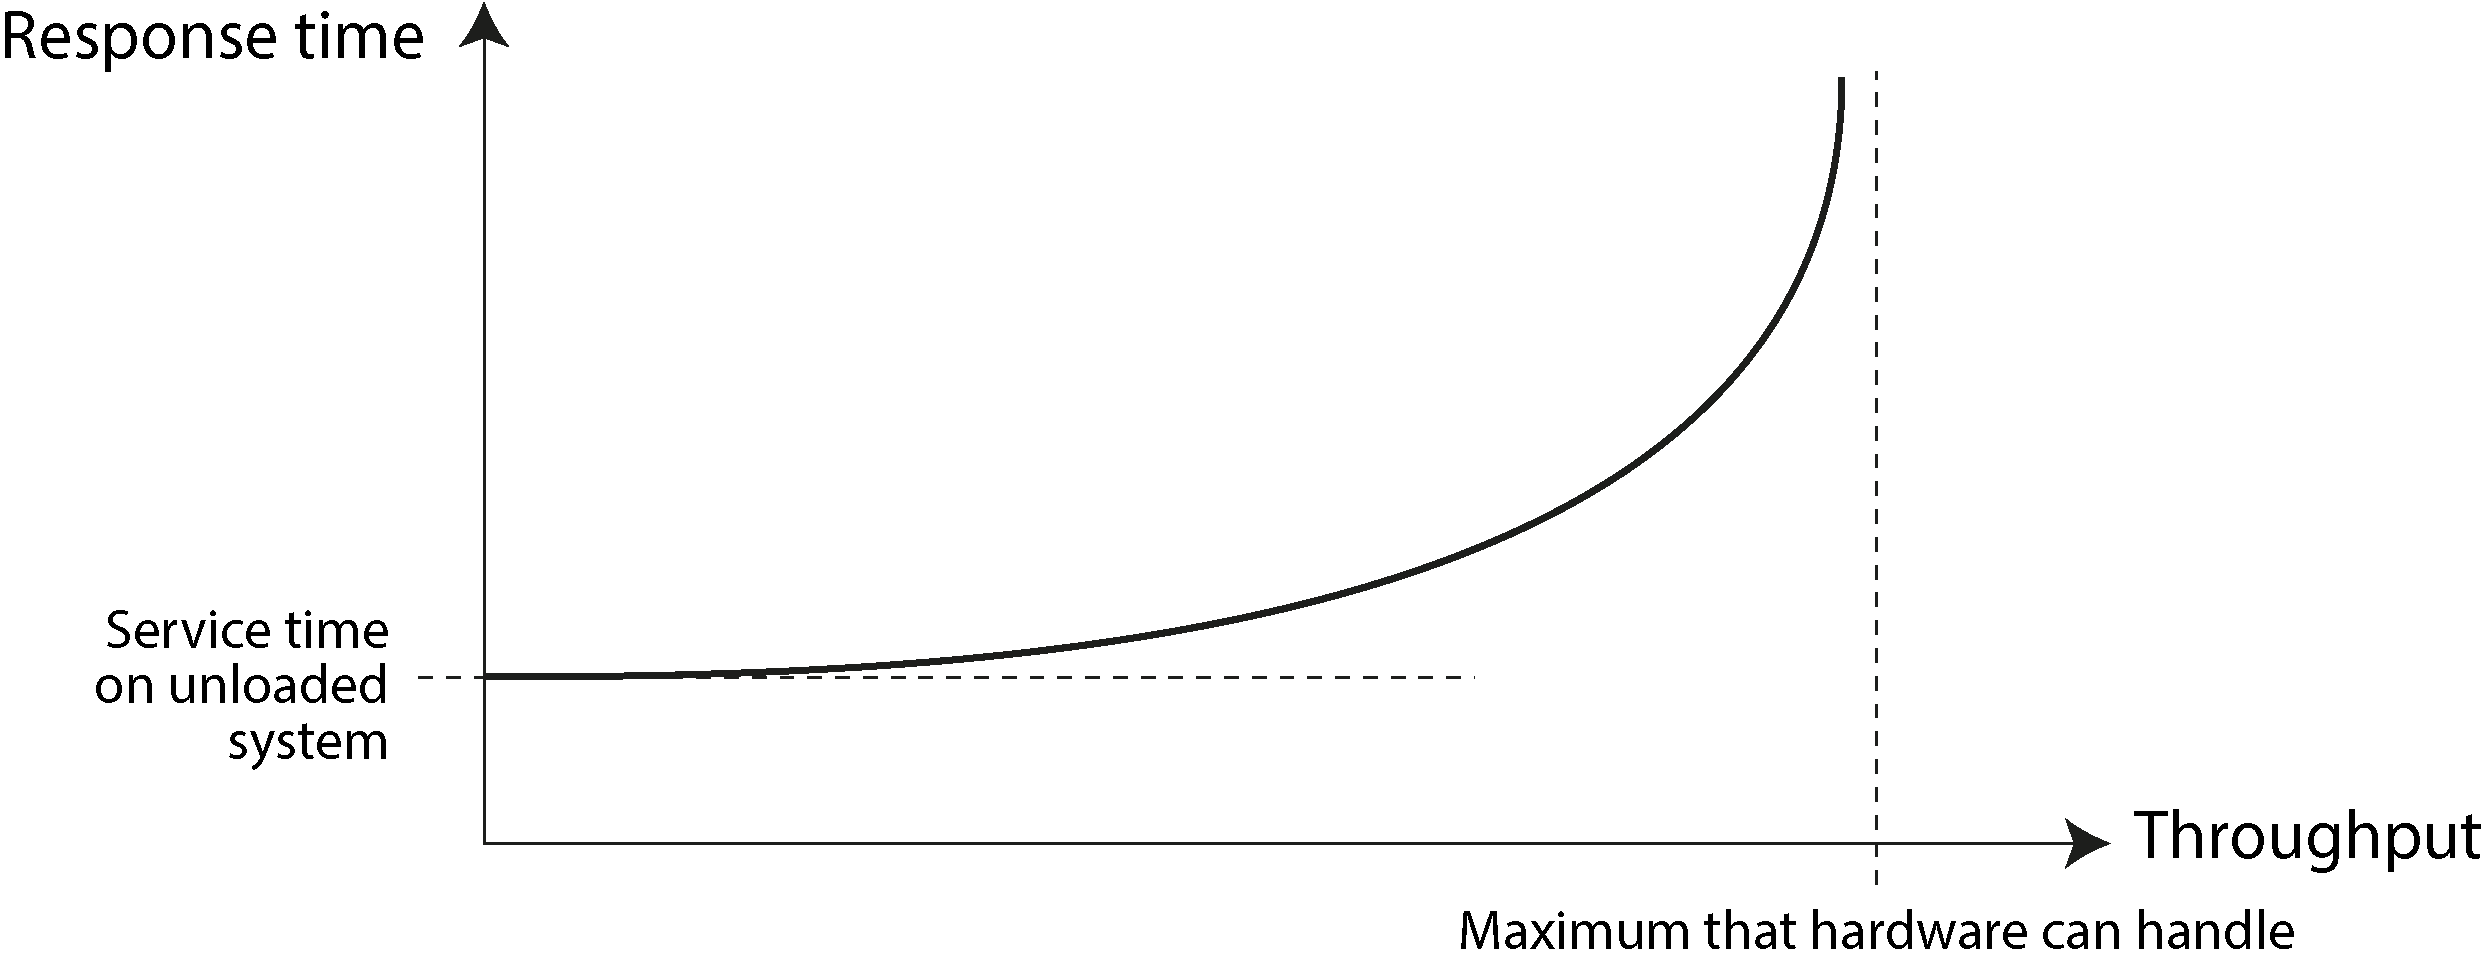

As the throughput of a service approaches its capacity, the response time increases dramatically because of queueing.

### Average, Median, and Percentiles

Because the response time varies from one request to the next, we need to think of it not as a single number, but as a distribution of values that we can measure. In Figure 2-5, each gray bar represents a request to a service, and its height shows how long that request took. Most requests are reasonably fast, but occasional outliers take much longer. Variation in network delay is also known as jitter.

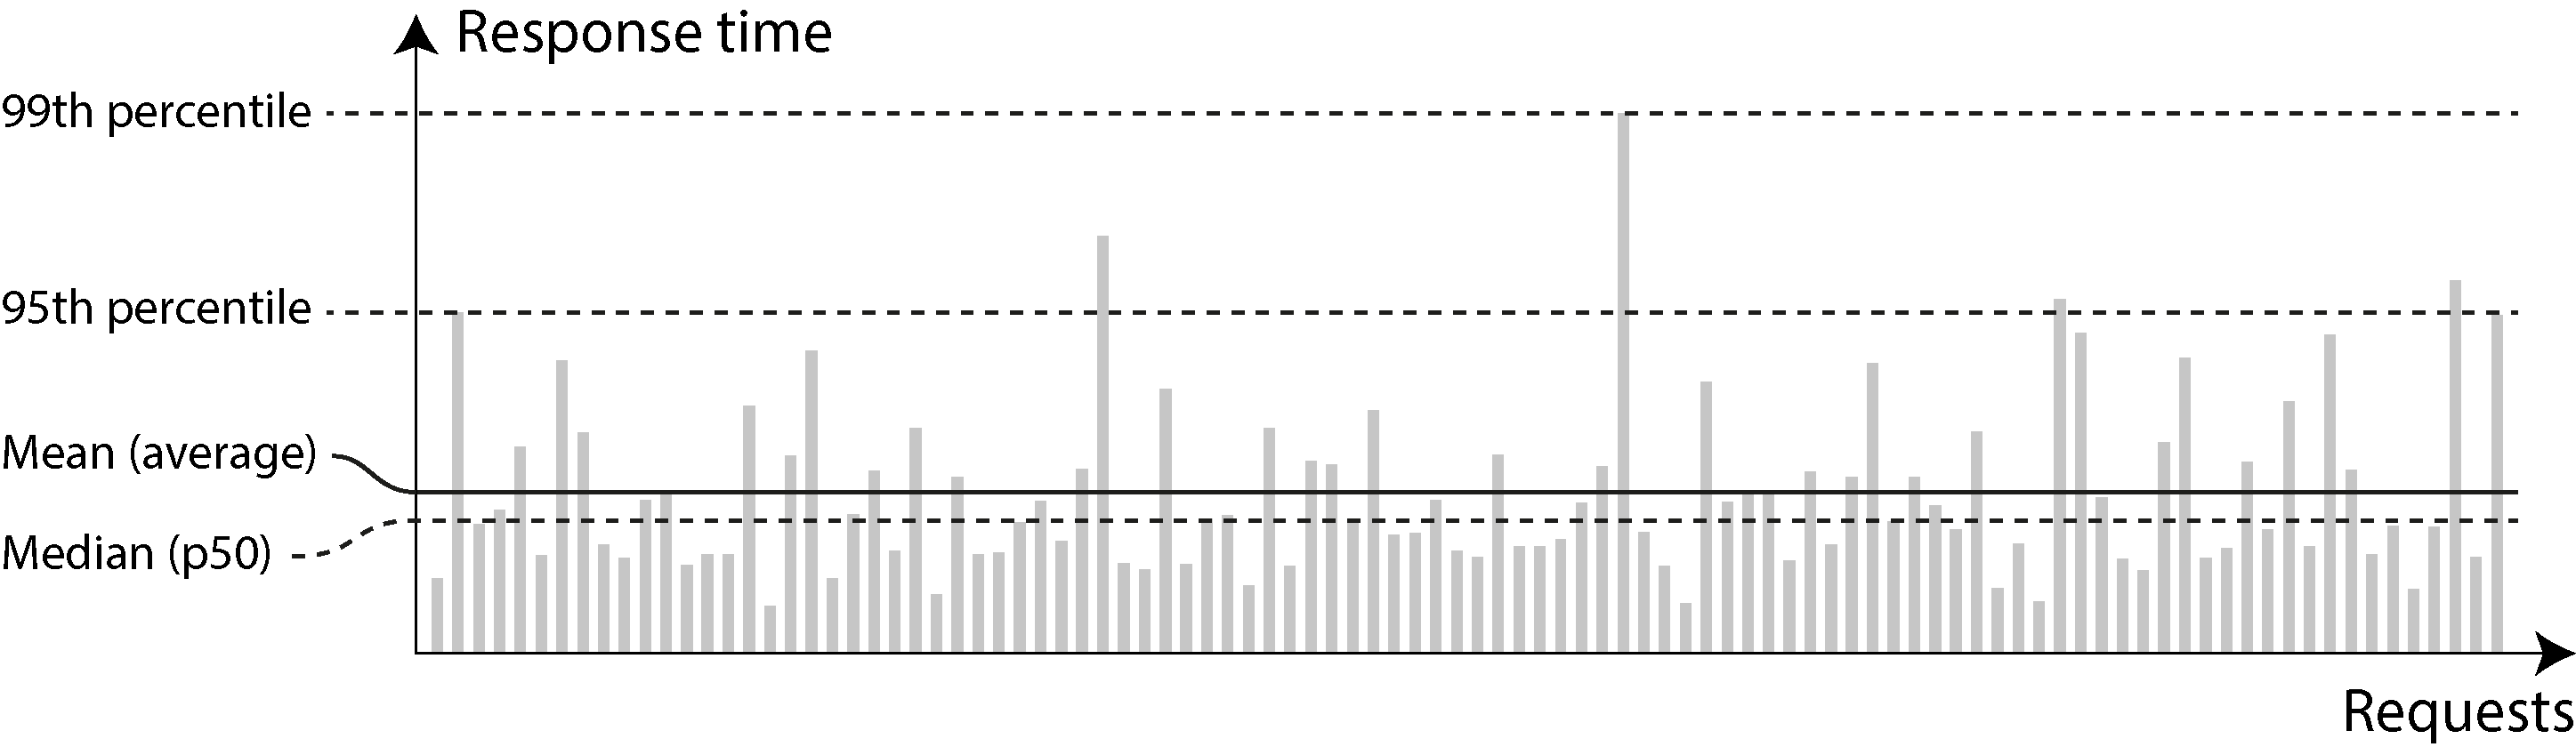

To figure out how bad your outliers are, you can look at higher percentiles: the 95th, 99th, and 99.9th percentiles are common (abbreviated p95, p99, and p999). For example, if the 95th percentile response time is 1.5 seconds, that means 95 out of 100 requests take less than 1.5 seconds, and 5 out of 100 requests take 1.5 seconds or more.

## Reliability and Fault Tolerance

We call a system fault-tolerant if it continues providing the required service to users in spite of certain faults occurring. If a system cannot tolerate a certain part becoming faulty, we call that part a single point of failure (SPOF), because a fault in that part escalates to cause the failure of the whole system.

Fault tolerance is always limited to a certain number of certain types of faults. For example, a system might be able to tolerate a maximum of two hard drives failing at the same time, or a maximum of one out of three nodes crashing.

**Tolerating hardware faults through redundancy**

Our first response to unreliable hardware is usually to add redundancy to the individual hardware components in order to reduce the failure rate of the system.

## Scalability

Scalability is the term we use to describe a system’s ability to cope with increased load.

The architecture of systems that operate at large scale is usually highly specific to the application. There is no such thing as a generic, one-size-fits-all scalable architecture.

A good general principle for scalability is to break a system into smaller components that can operate largely independently from one another. This is the underlying principle behind microservices (see “Microservices and Serverless”), sharding (Chapter 7), stream processing (Chapter 12), and shared-nothing architectures.

# 3 - Data Models and Query Languages

## Relational Versus Document Models

The best-known data model today is probably that of SQL, based on the relational model proposed by Edgar Codd in 1970 [4]. In this model, data is organized into relations (called tables in SQL), where each relation is an unordered collection of tuples (rows in SQL).

One lasting effect of the NoSQL movement is the popularity of the document model, which usually represents data as JSON. This model was originally popularized by specialized document databases such as MongoDB and Couchbase, although most relational databases have now also added JSON support.

Compared to relational tables, which are often seen as having a rigid and inflexible schema, JSON documents are thought to be more flexible.

### Normalization, Denormalization, and Joins

Whether you store an ID or a text string is a question of normalization. When you use an ID, your data is more **normalized**: the information that is meaningful to humans (such as the text Washington, DC) is stored in only one place, and everything that refers to it uses an ID (which has meaning only within the database).

When you store the text directly, you are duplicating the human-meaningful information in every record that uses it; this representation is **denormalized**.

The advantage of using an ID is that because it has no meaning to humans, it never needs to change: the ID can remain the same even if the information it identifies changes. Anything that is meaningful to humans may need to change sometime in the future—and if that information is duplicated, all the redundant copies will need to be updated. That requires more code, more write operations, and more disk space, and it risks inconsistencies (as some copies of the information are updated but others aren’t).

The downside of a normalized representation is that every time you want to display a record containing an ID, you have to do an additional lookup to resolve the ID into something human-readable. In a relational data model, this is done using a **join**.

### Stars and Snowflakes: Schemas for Analytics

Data warehouses (see “Data Warehousing”) are usually relational, and there are a few widely used conventions for the structure of tables in a data warehouse, including a star schema, a snowflake schema, dimensional modeling [14], and one big table (OBT). These structures are optimized for the needs of business analysts. ETL processes translate data from operational systems into the selected schema.

Figure 3-5 shows an example of a star schema that might be found in the data warehouse of a grocery retailer. At the center of the schema is a so-called fact table (in this example, it is called fact_sales). Each row of the fact table represents an event that occurred at a particular time (here, each row represents a customer’s purchase of a product). If we were analyzing website traffic rather than retail sales, each row might represent a page view or a click by a user.

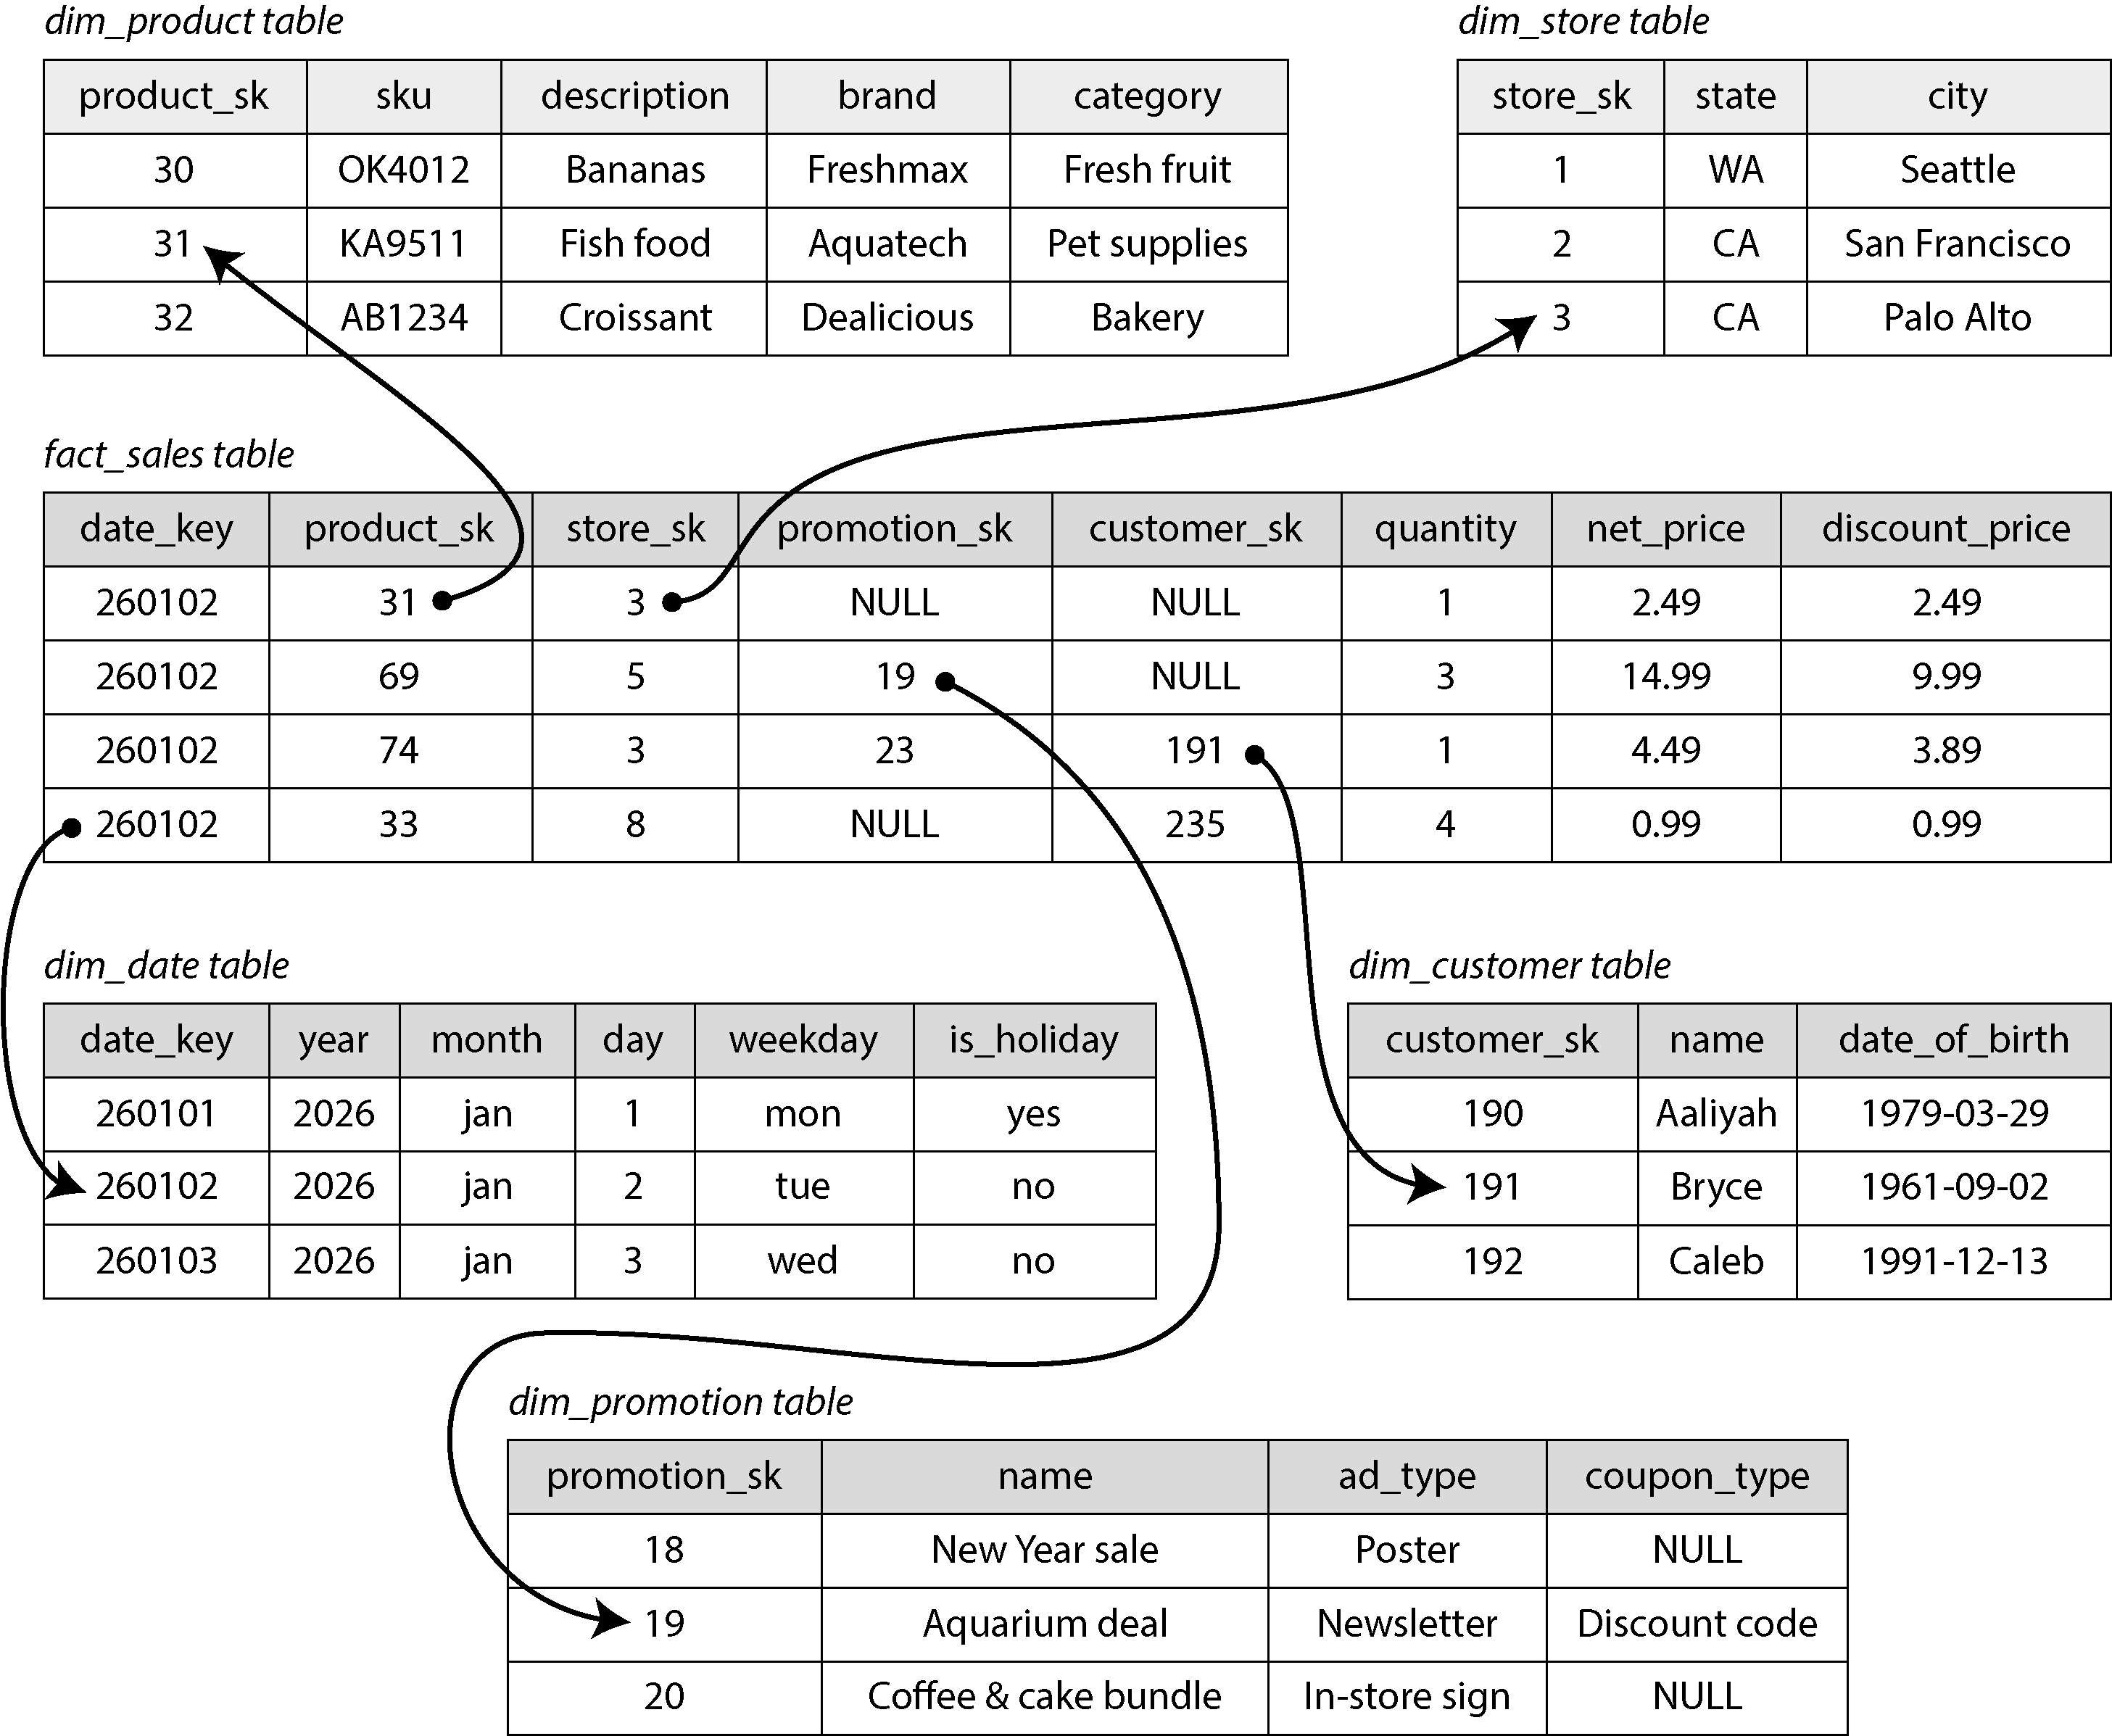

The name star schema comes from the fact that when the table relationships are visualized, the fact table is in the middle, surrounded by its dimension tables (as shown in Figure 3-5); the connections to these tables are like the rays of a star.

Some data warehouse schemas take denormalization even further and leave out the dimension tables entirely, folding the information in the dimensions into denormalized columns in the fact table instead (essentially, precomputing the join between the fact table and the dimension tables). This approach is known as **one big table (OBT)**, and while it requires more storage space, it sometimes enables faster queries

### When to Use Which Model

The main arguments in favor of the document data model are schema flexibility, better performance due to locality, and that for some applications it is closer to the object model used by the application. The relational model counters by providing better support for joins and many-to-one and many-to-many relationships. Let’s examine these arguments in more detail.

*If the data in your application has a document-like structure (i.e., a tree of one-to-many relationships, where typically the entire tree is loaded at once), then it’s probably a good idea to use a document model.* The relational technique of shredding⁠—splitting a document-like structure into multiple tables (like positions, education, and contact_info in Figure 3-1)—can lead to cumbersome schemas and unnecessarily complicated application code.

The document model has limitations. For example, you cannot refer directly to a nested item within a document; instead, you need to say something like, “the second item in the list of positions for user 251.” If you need to reference nested items, a relational approach works better, since you can refer to any item directly by its ID.

**Schema flexibility in the document model**

Most document databases, and the JSON support in relational databases, do not enforce any schema on the data in documents. XML support in relational databases usually comes with optional schema validation. No schema means that arbitrary keys and values can be added to a document, and when reading, clients have no guarantees as to what fields the documents may contain.

Document databases are sometimes called *schemaless*, but that’s misleading as the code that reads the data usually assumes some kind of structure—that is, there is an implicit schema, but it is not enforced by the database [19]. A more accurate term is **schema-on-read** (the structure of the data is implicit and interpreted only when the data is read), in contrast with **schema-on-write** (the traditional approach of relational databases, where the schema is explicit and the database ensures that all data conforms to it when the data is written)

**Data locality for reads and writes**

A document is usually stored as a single continuous string, encoded as JSON, XML, or a binary variant thereof (such as MongoDB’s BSON). If your application often needs to access the entire document (e.g., to render it on a web page), this storage locality has a performance advantage. If data is split across multiple tables, as in Figure 3-1, multiple index lookups are required to retrieve it all, which may require more disk seeks and take more time.

The locality advantage applies only if you need large parts of the document at the same time. The database typically needs to load the entire document, which can be wasteful if you need to access only a small part of a large document. Furthermore, on updates to a document, the entire document usually needs to be rewritten. For these reasons, it is generally recommended that you keep documents fairly small and avoid frequent small updates.

However, storing related data together for locality is not limited to the document model. For example, Google’s Spanner database offers the same locality properties in a relational data model, by allowing the schema to declare that a table’s rows should be interleaved (nested) within a parent table

**Query languages for documents**

Another difference between a relational and a document database is the language or API that you use to query it. Most relational databases are queried using SQL, but document databases are more varied.

**Convergence of document and relational databases**

Document databases and relational databases started out as very different approaches to data management, but they have grown more similar over time [33]. Relational databases added support for JSON types and query operators, and the ability to index properties inside documents. Some document databases (such as MongoDB, Couchbase, and RethinkDB) added support for joins, secondary indexes, and declarative query languages.

## Graph-Like Data Models

Many kinds of data can be modeled as a graph. Typical examples include the following:

Social graphs

Vertices are people, and edges indicate which people know each other.

The web graph

Vertices are web pages, and edges indicate HTML links to other pages.

Road or rail networks

Vertices are junctions, and edges represent the roads or railway lines between them.

To illustrate these languages and models, this section uses Figure 3-6 as a running example. It could be taken from a social network or a genealogical database; it shows two people, Lucy from Idaho and Alain from Saint-Lô, France. They are married and living in London. Each person and each location is represented as a vertex, and the relationships between them are represented as edges. This example will help demonstrate some queries that are easy in graph databases but difficult in other data models.

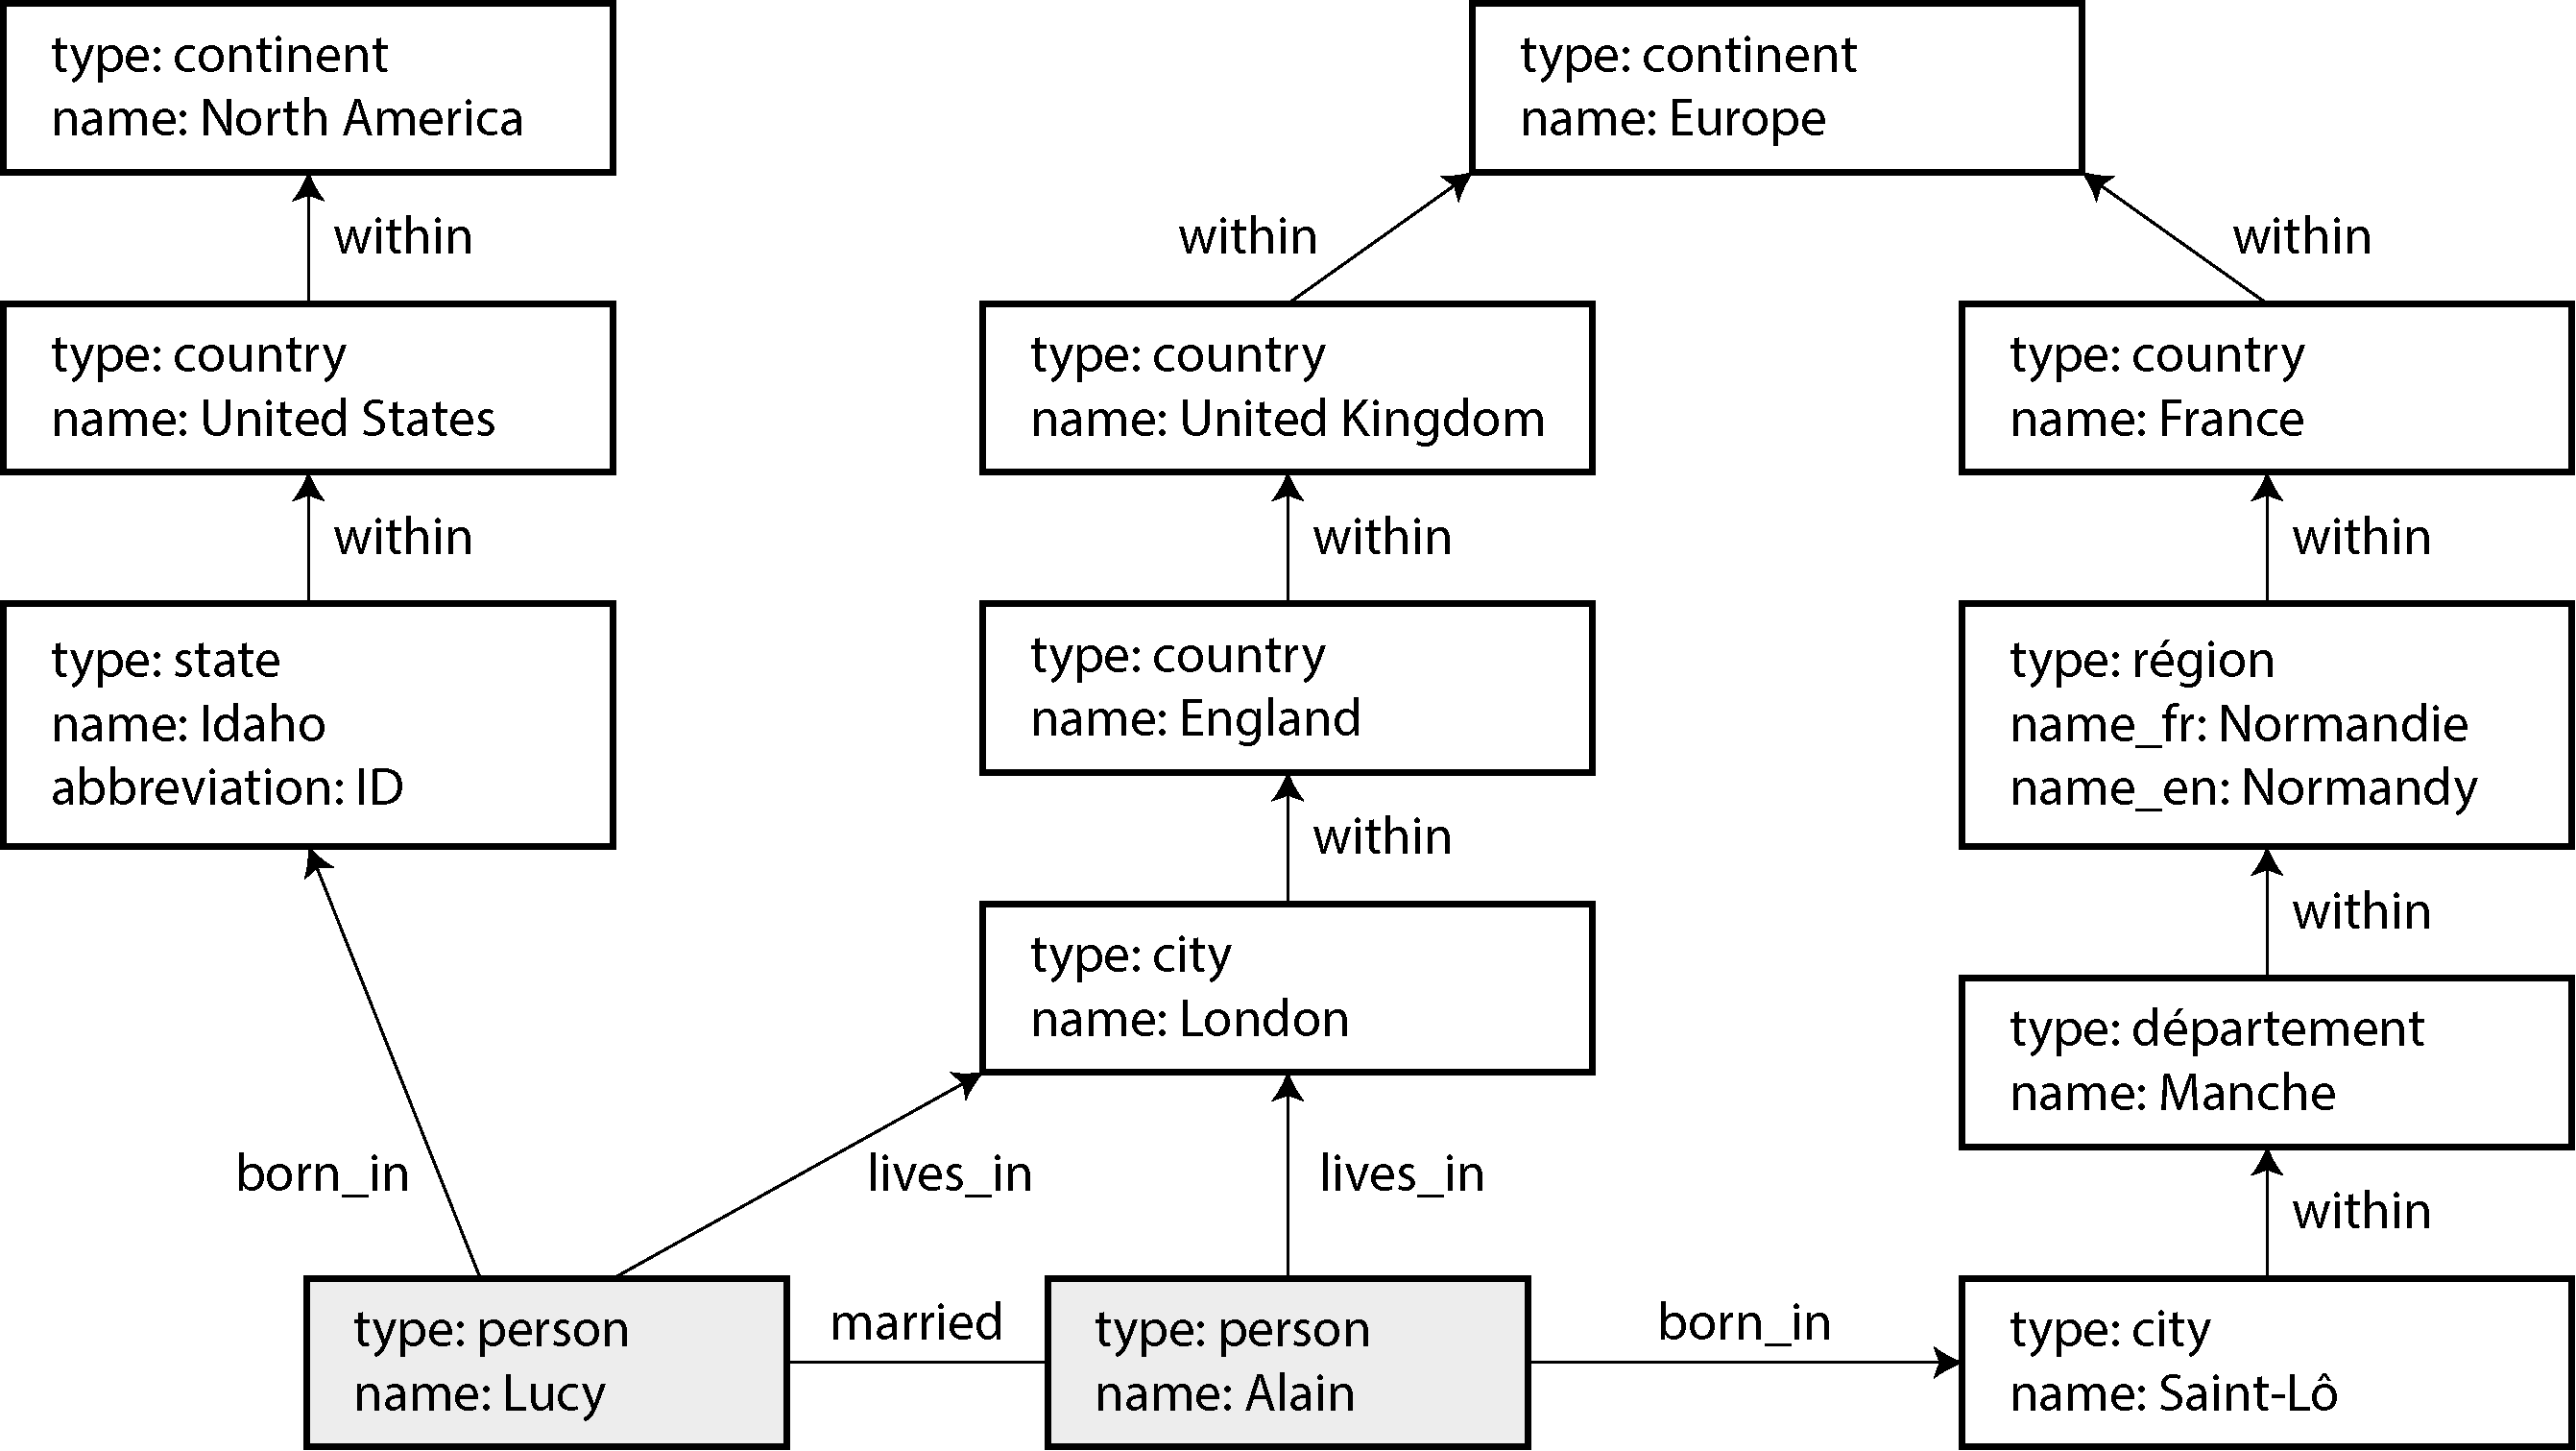

### GraphQL

GraphQL is a query language that, by design, is much more restrictive than the others we have seen in this chapter. It’s intended for OLTP queries; its purpose is to allow client software running on a user’s device (such as a mobile app or a JavaScript web app frontend) to request a JSON document with a particular structure, containing the fields necessary for rendering its UI.

Example 3-13. A GraphQL query for a group chat application
```graphql
query ChatApp {
  channels {
    name
    recentMessages(latest: 50) {
      timestamp
      content
      sender {
        fullName
        imageUrl
      }
      replyTo {
        content
        sender {
          fullName
        }
      }
    }
  }
}
```

Example 3-14. A possible response to the query in Example 3-13
```javascript
{
  "data": {
    "channels": [
      {
        "name": "#general",
        "recentMessages": [
          {
            "timestamp": 1693143014,
            "content": "Hey! How are y'all doing?",
            "sender": {"fullName": "Aaliyah", "imageUrl": "https://..."},
            "replyTo": null
          },
          {
            "timestamp": 1693143024,
            "content": "Great! And you?",
            "sender": {"fullName": "Caleb", "imageUrl": "https://..."},
            "replyTo": {
              "content": "Hey! How are y'all doing?",
              "sender": {"fullName": "Aaliyah"}
            }
          },
          ...
```

## Event Sourcing and CQRS

Perhaps the simplest, fastest, and most expressive way of writing data is an **event log**: every time you want to write some data, you encode it as a self-contained string (perhaps as JSON), including a timestamp, and then append it to a sequence of events. Events in this log are *immutable*; you never change or delete them, but only ever append more events to the log (which may supersede earlier events). An event can contain arbitrary properties.

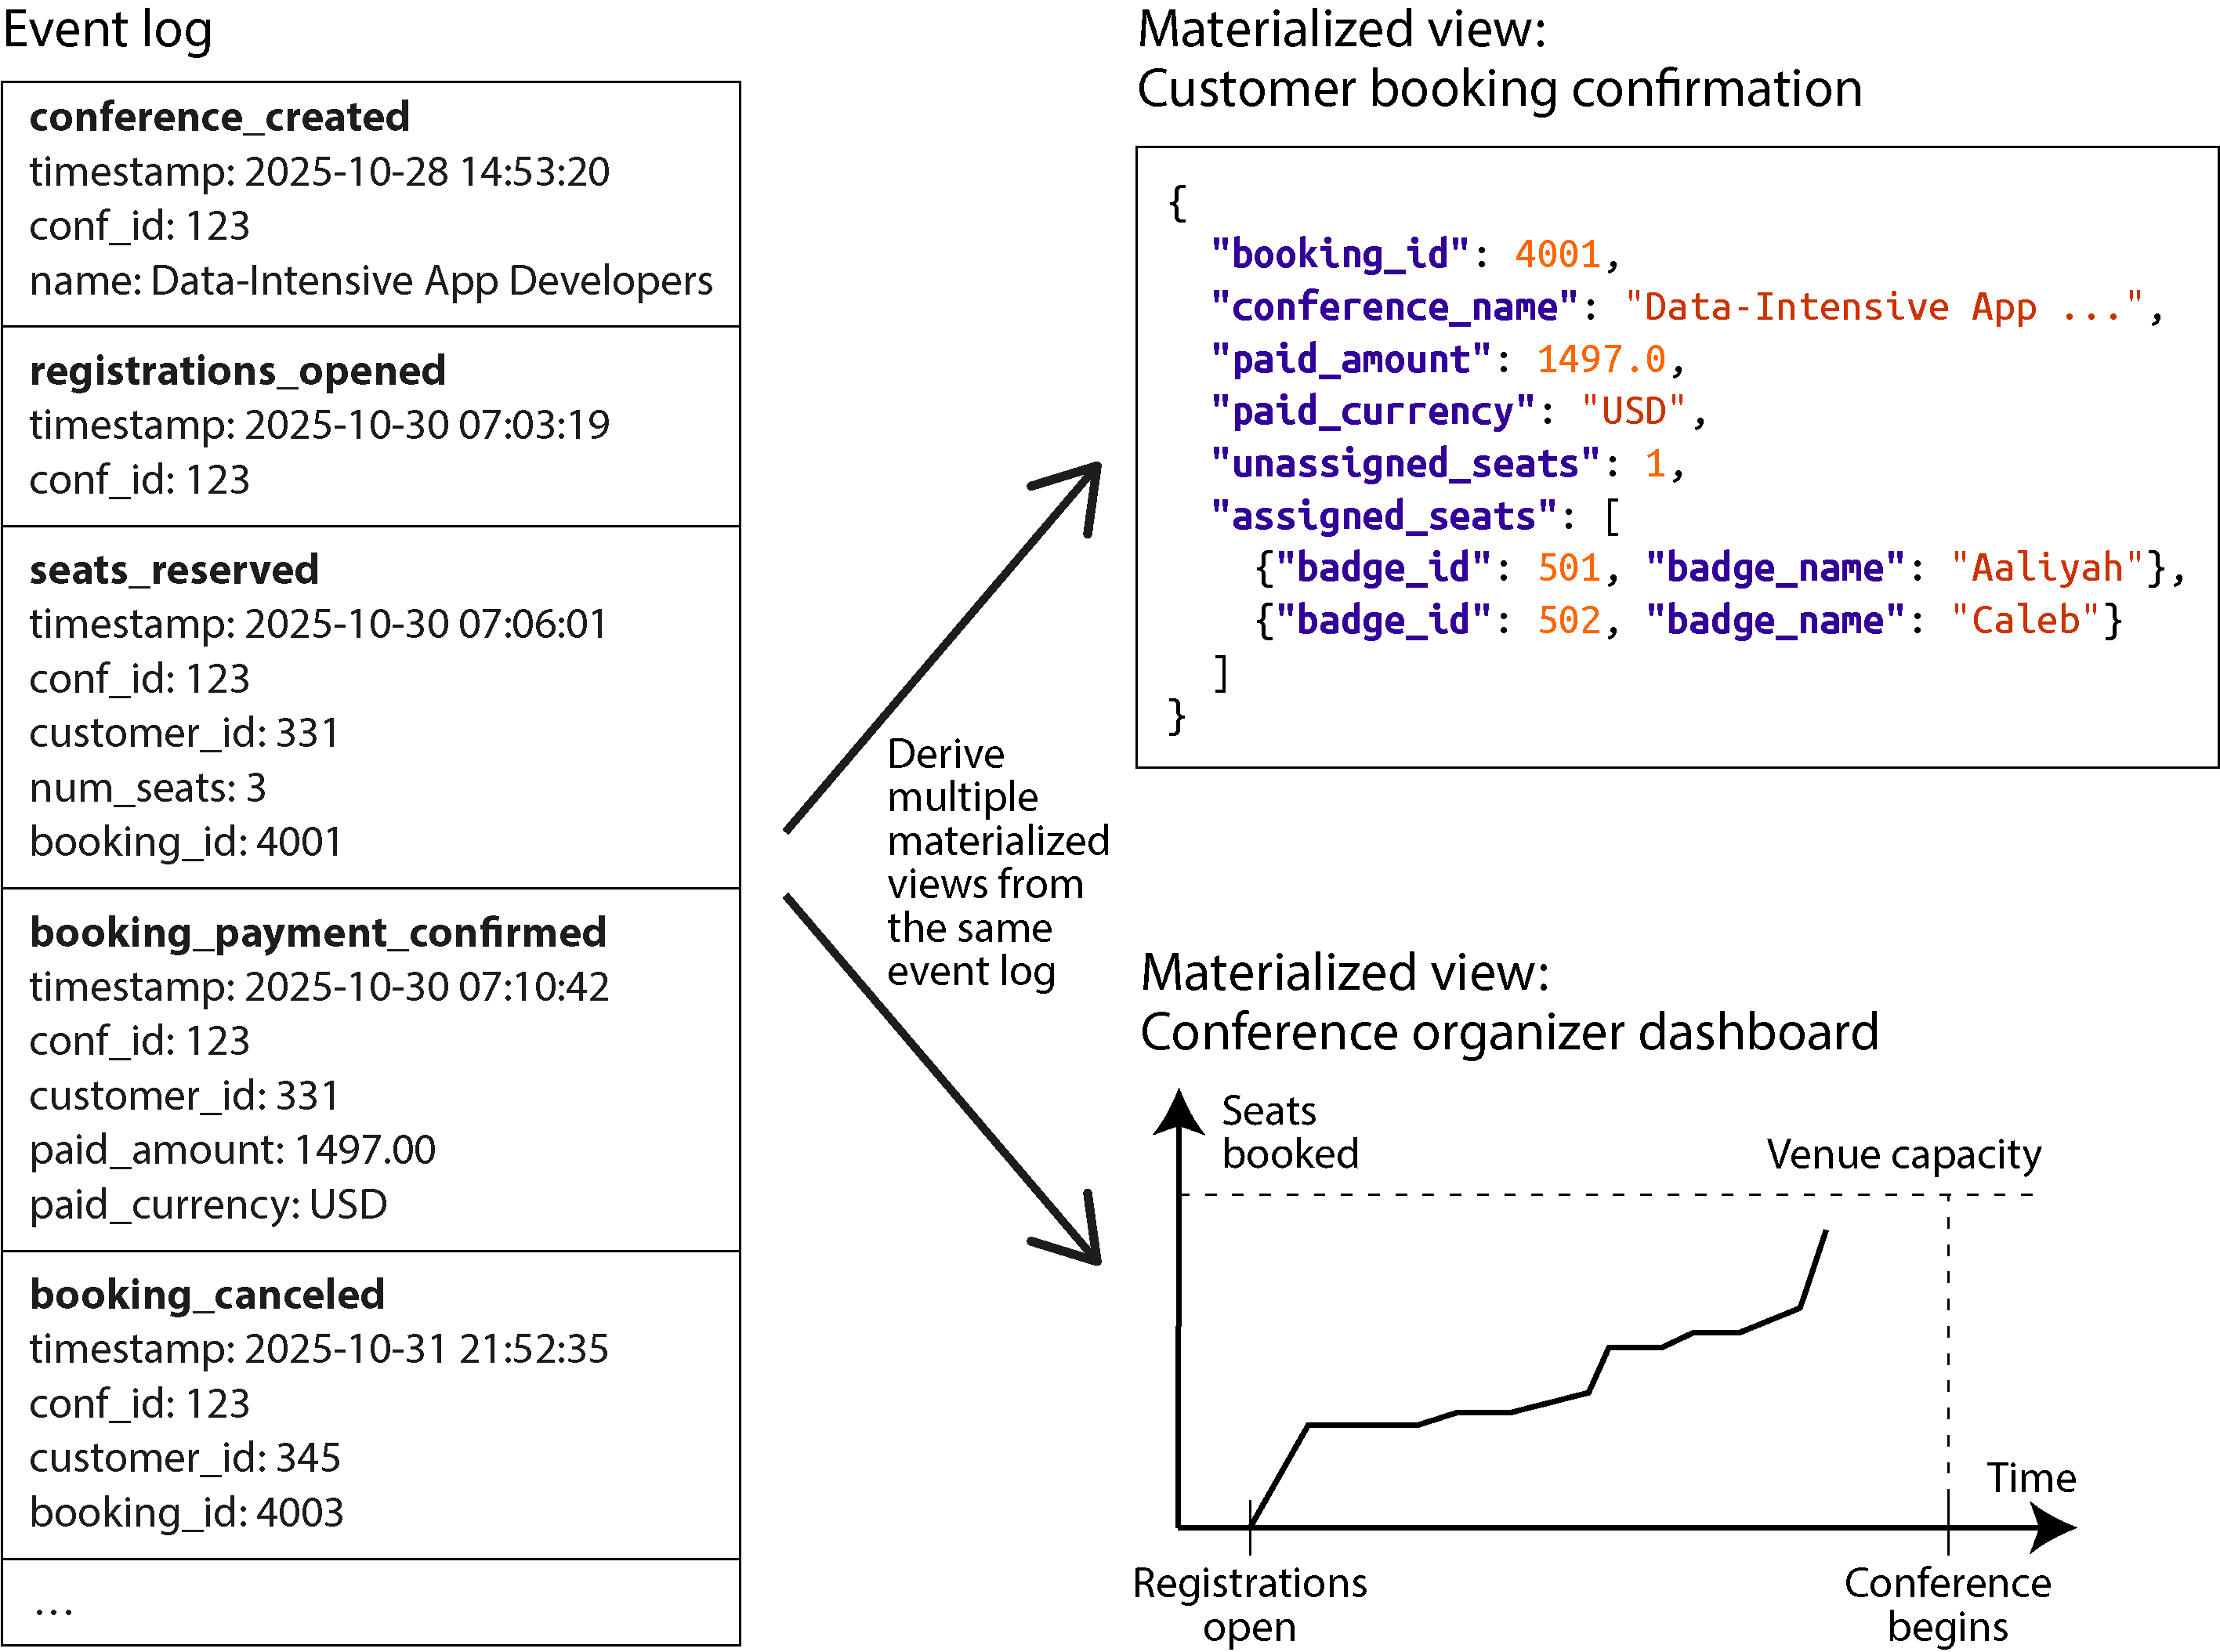

The idea of using events as the source of truth and expressing every state change as an event is known as **event sourcing** [65, 66]. The principle of maintaining separate read-optimized representations and deriving them from the write-optimized representation is **called command query responsibility segregation (CQRS)**

## DataFrames, Matrices, and Arrays

There are also a few data models that you are likely to encounter in an analytical or scientific context but that rarely feature in OLTP systems, including DataFrames and multidimensional arrays of numbers such as matrices.

The DataFrame data model is supported by the R language, the Pandas library for Python, Apache Spark, ArcticDB, Dask, and other systems. DataFrames are a popular tool for data scientists preparing data for training ML models, but they are also widely used for data exploration, statistical data analysis, data visualization, and similar purposes.

Instead of using a declarative query language such as SQL, a DataFrame is generally manipulated through a series of commands that modify its structure and content. This matches the typical workflow of data scientists, who incrementally “wrangle” the data into a form that allows them to find answers to the questions they are asking.

Once the data is in the form of a matrix of numbers, it is amenable to linear algebra operations, which form the basis of many ML algorithms.

Some databases, such as TileDB [70], specialize in storing large multidimensional arrays of numbers; they are called array databases and are most commonly used for scientific datasets such as geospatial measurements (raster data on a regularly spaced grid), medical imaging, or observations from astronomical telescopes [71].

DataFrames are also used in the financial industry for representing time-series data, such as the prices of assets and trades over time [72]. Because of their popularity with data scientists, DataFrames have been added to batch processing frameworks such as Spark and Flink as well.


# 4 - Storage and Retrieval

## Storage and Indexing for OLTP


### Log-Structured Storage

**The SSTable file format**

 It is common to keep data in a structure that is sorted by key [3]. One example of such a structure is a **Sorted Strings Table**, or **SSTable** for short, as shown in Figure 4-2. This file format also stores key-value pairs, but it ensures that they are sorted by key, and each key appears only once in the file.

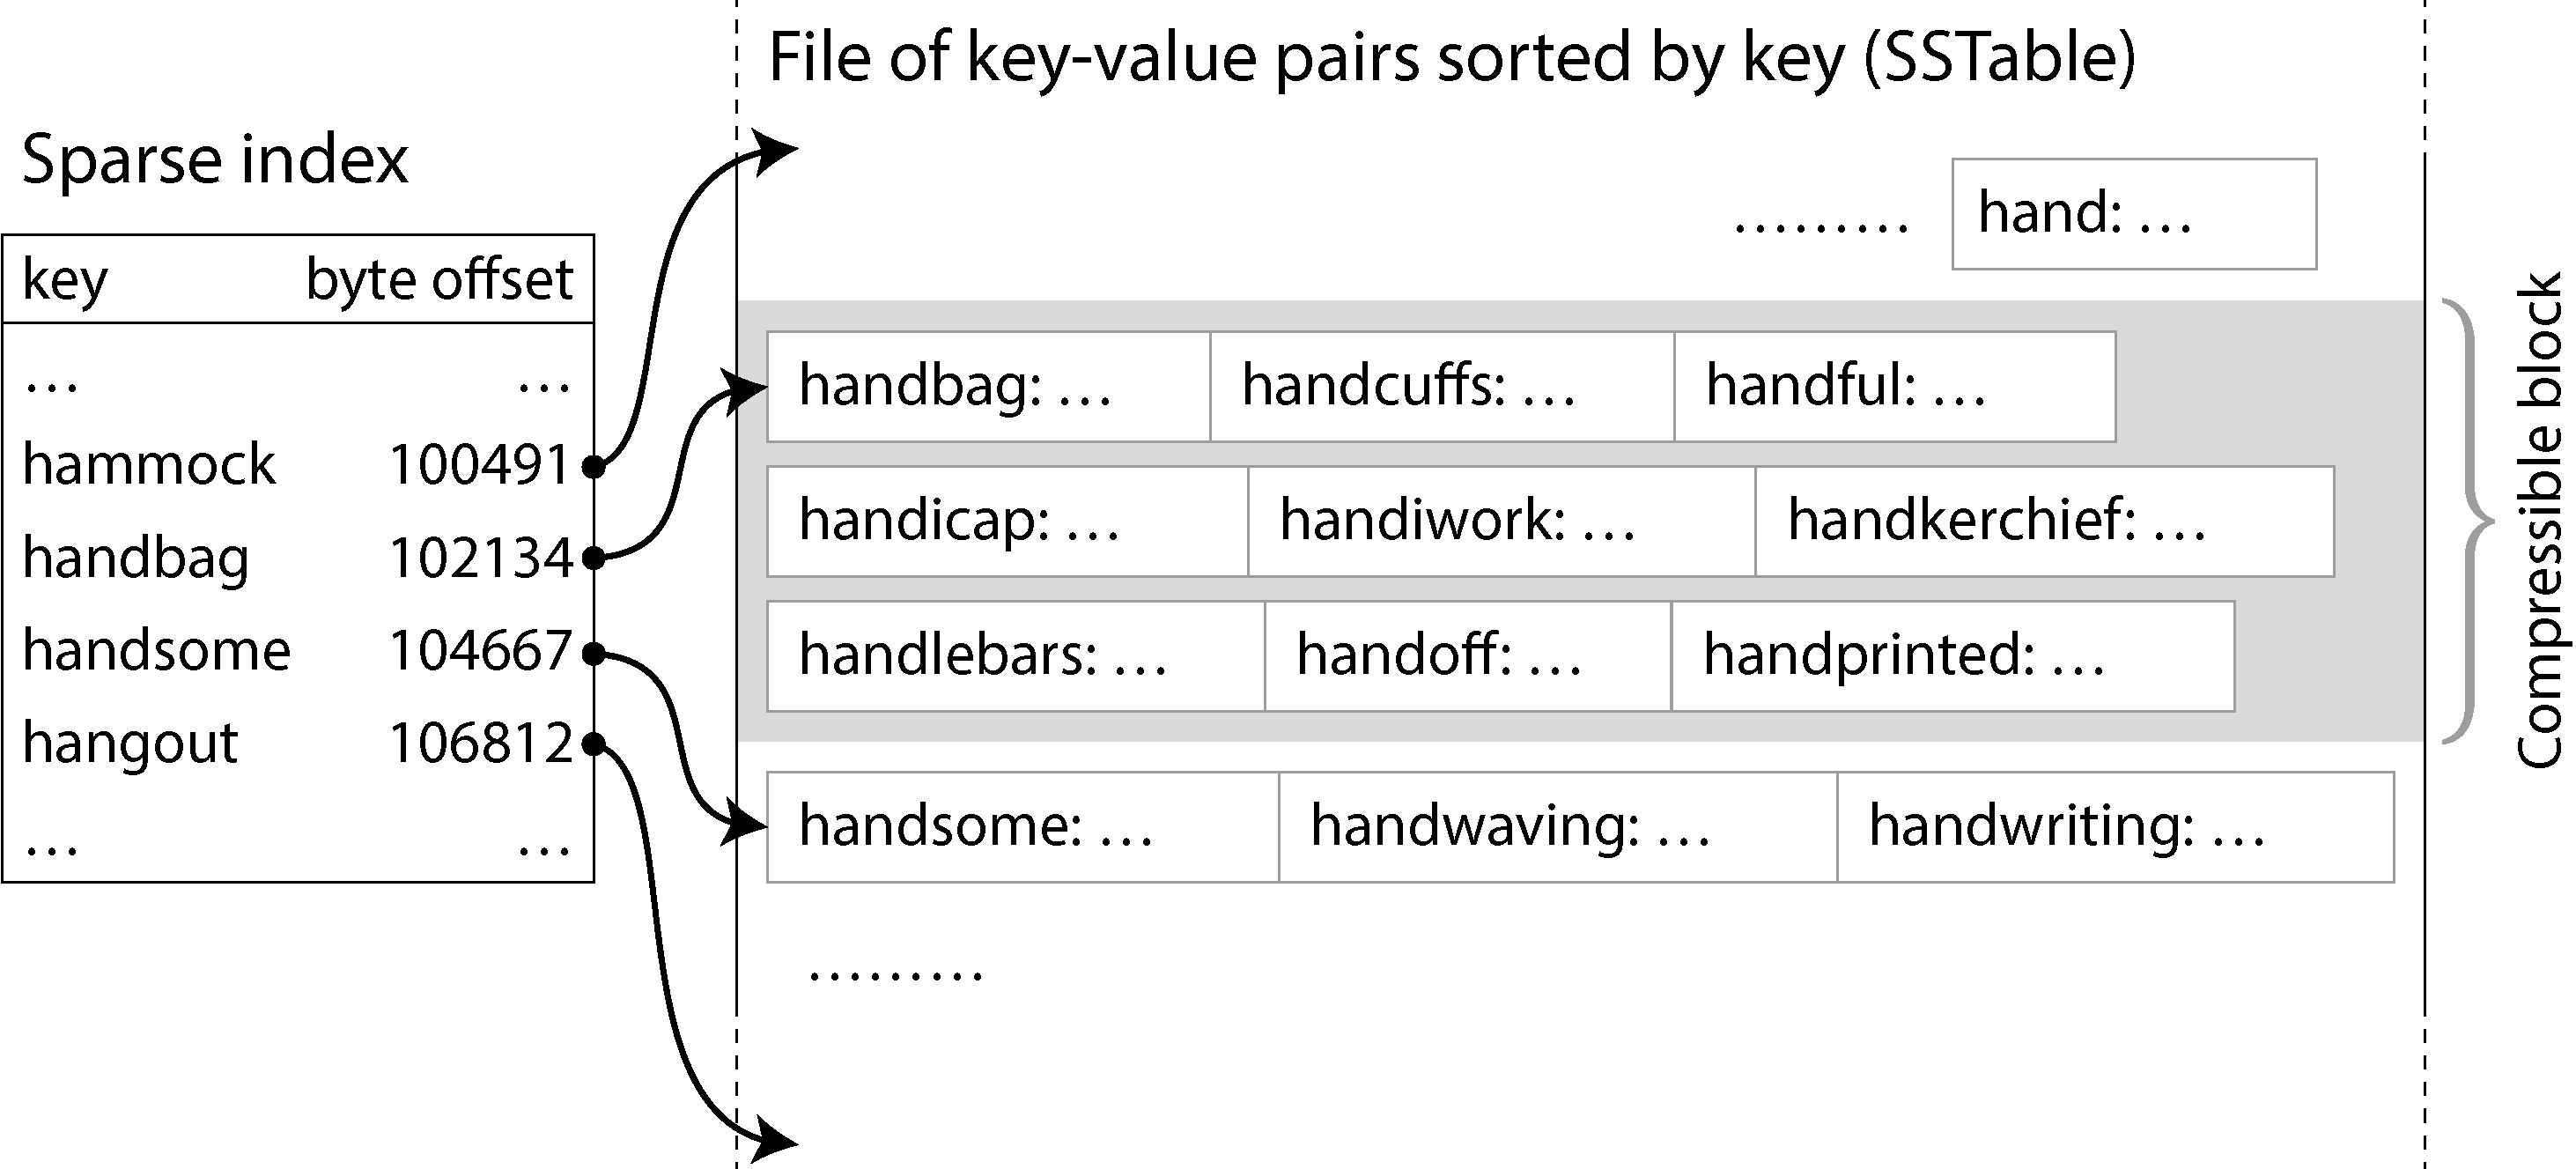

Now, you do not need to keep all the keys in memory. You can group the key-value pairs within an SSTable into blocks of a few kilobytes and then store the first key of each block in the index. This kind of index, which stores only some of the keys, is called sparse. This index is stored in a separate part of the SSTable—for example, using an immutable B-tree, a trie, or another data structure that allows queries to quickly look up a particular key.

**Constructing and merging SSTables**

The SSTable file format is better for reading than an append-only log, but it makes writes more difficult. We can’t simply append at the end, because then the file would no longer be sorted.

If we had to rewrite the whole SSTable every time a key was inserted somewhere in the middle, writes would become far too expensive.

We can solve this problem with a log-structured approach, which is a hybrid between an append-only log and a sorted file:

- When a write comes in, add it to an in-memory ordered map data structure, such as a red–black tree, skip list [5], or trie [6] (They ensure values are sorted by key). With these data structures, you can insert keys in any order, look them up efficiently, and read them back in sorted order. This in-memory data structure is called the **memtable**.

- When the memtable gets bigger than a certain threshold—typically a few megabytes—write it out to disk in sorted order as an SSTable file. We call this new SSTable file the most recent *segment* of the database, and it is stored as a separate file alongside the older segments. Each segment has a separate index of its contents. While the new segment is being written out to disk, the database can continue writing to a new memtable instance, and the old memtable’s memory is freed when the writing of the SSTable is complete.
- To read the value for a key, first try to find the key in the memtable and the most recent on-disk segment. If it’s not there, keep looking in the next-older segment until you either find the key or reach the oldest segment. If the key does not appear in any of the segments, it does not exist in the database.
- From time to time, run a merging and compaction process in the background to combine segment files and to discard overwritten or deleted values.

Merging segments works similarly to the *mergesort* algorithm.

To ensure that the data in the memtable is not lost if the database crashes, the storage engine keeps a separate log on disk to which every write is immediately appended. This log is not sorted by key, but that doesn’t matter, because its only purpose is to restore the memtable after a crash. Every time the memtable gets written out to an SSTable, the corresponding part of the log can be discarded.

Merging several SSTable segments, retaining only the most recent value for each key:

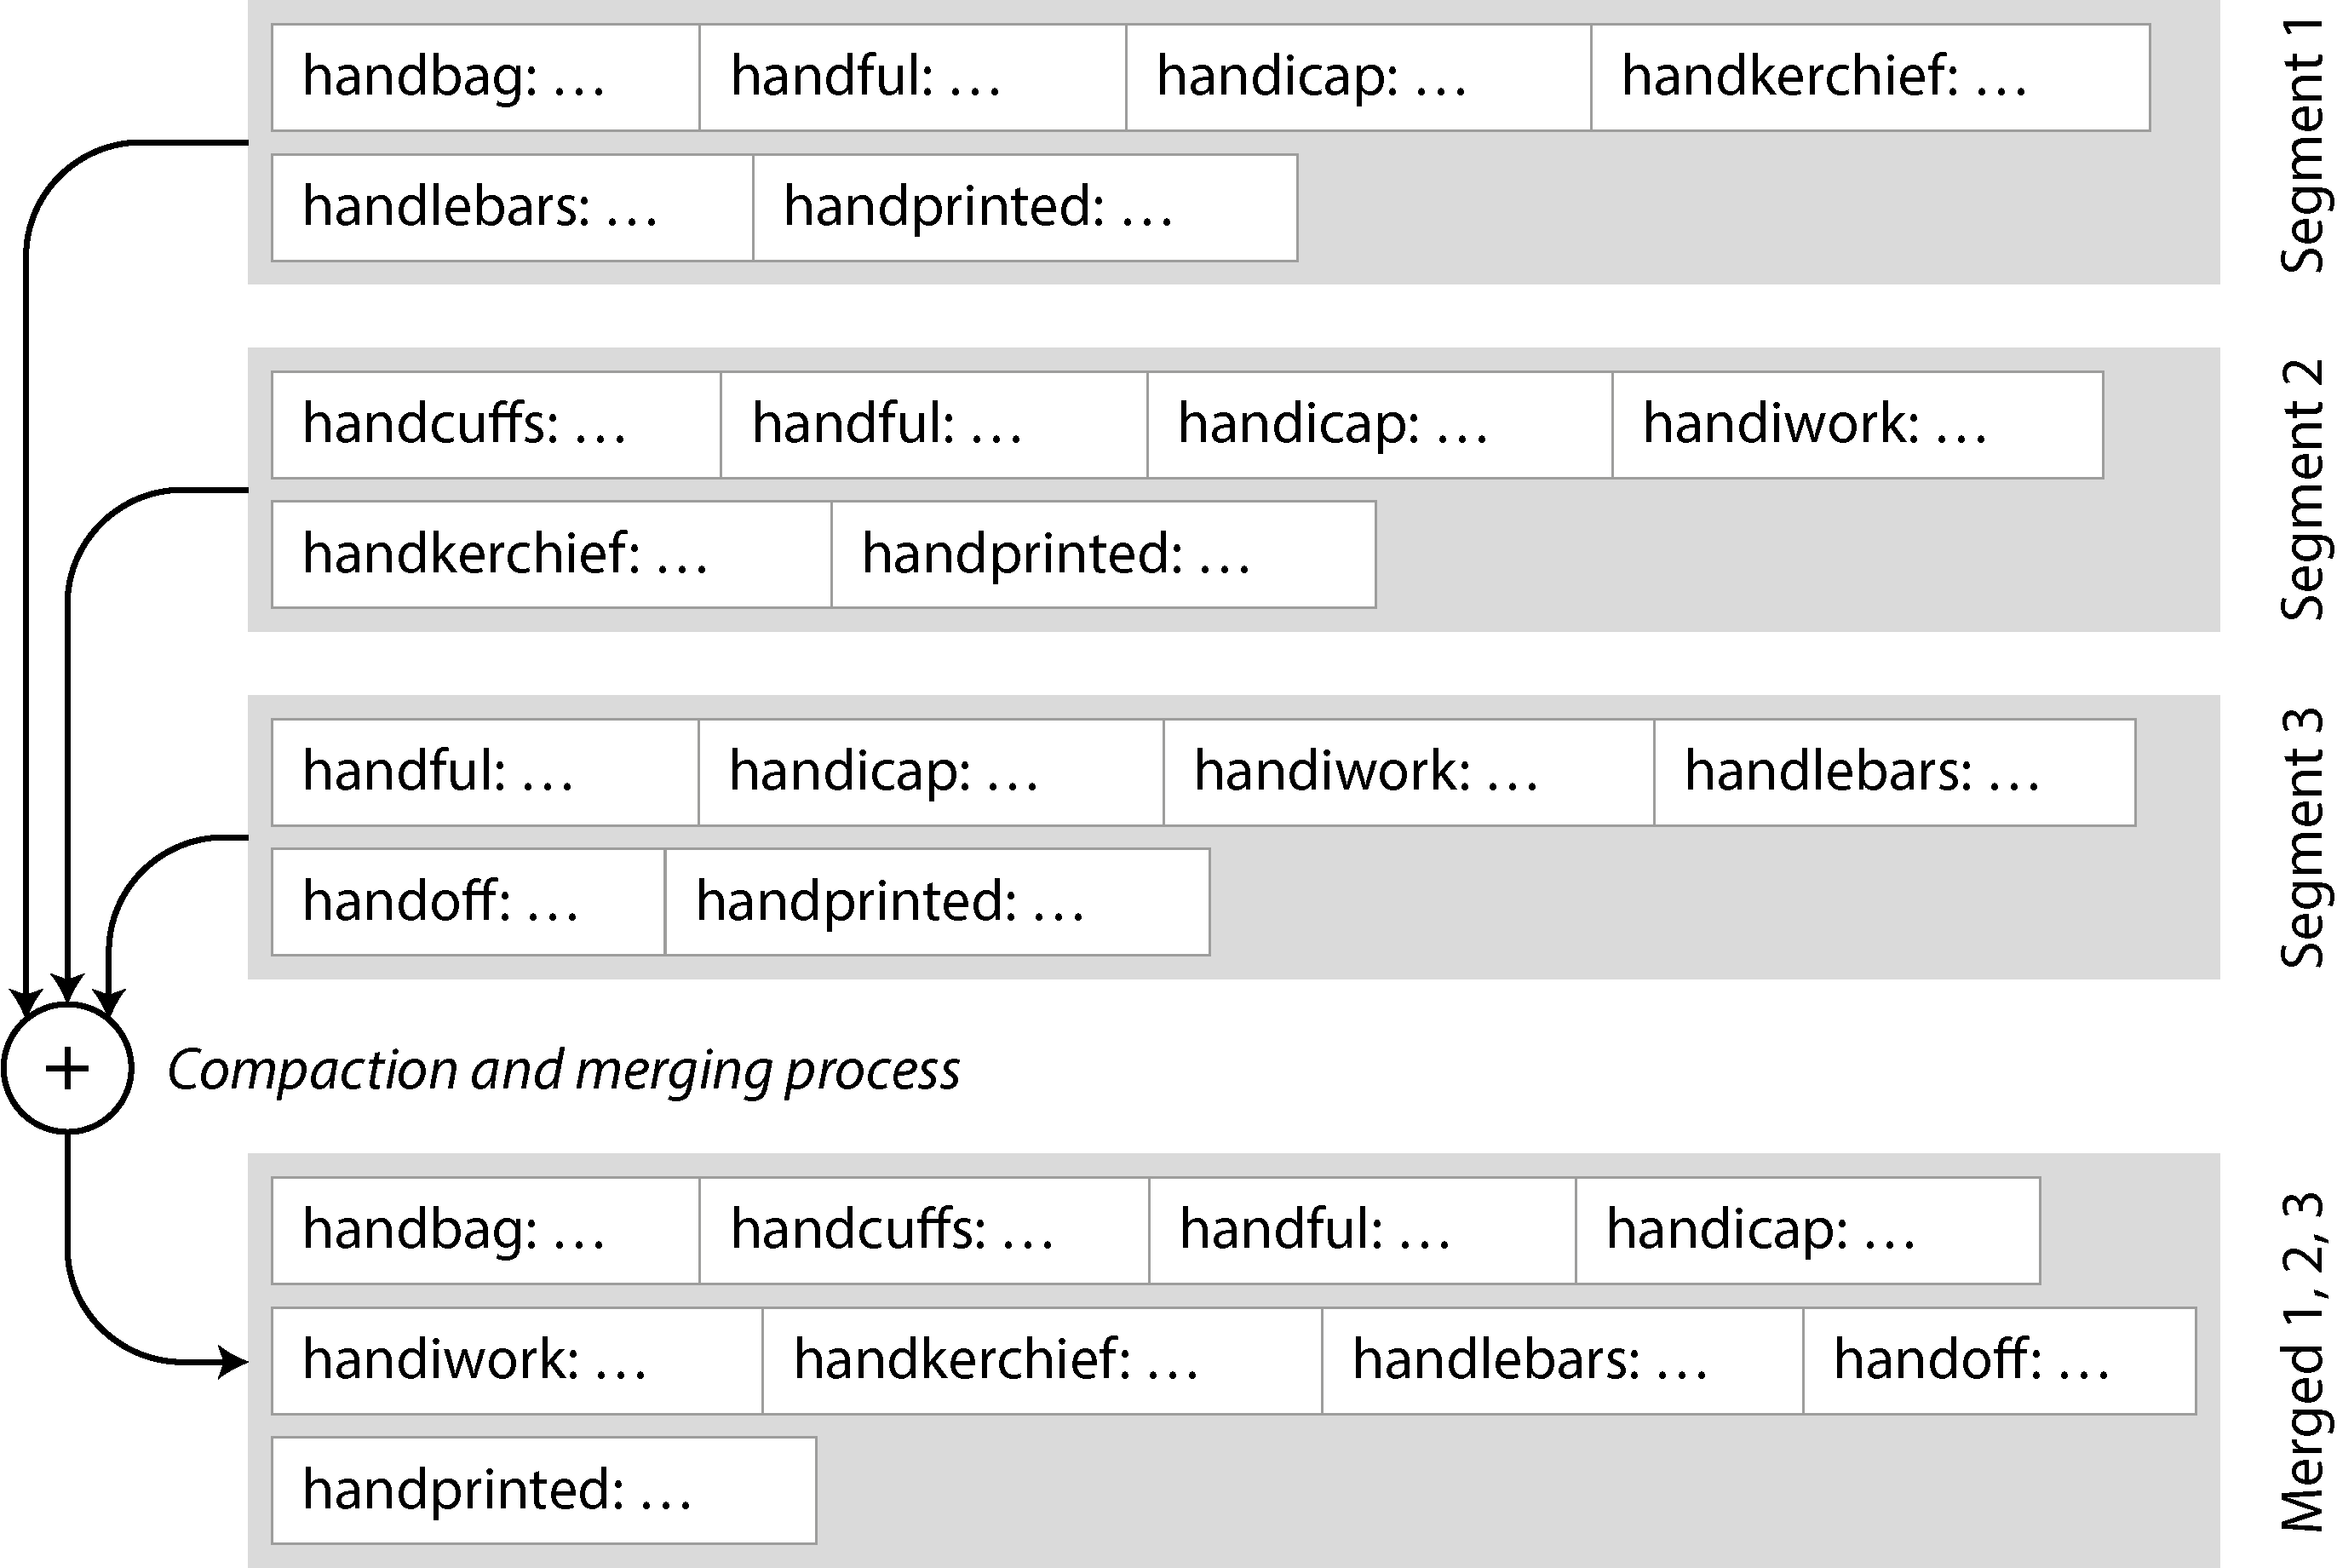

If you want to delete a key and its associated value, you have to append a special deletion record called a *tombstone* to the data file. When log segments are merged, the tombstone tells the merging process to discard any previous values for the deleted key. Once the tombstone is merged into the oldest segment, it can be dropped.

The algorithm described here is essentially what is used in RocksDB [7], Cassandra, ScyllaDB, and HBase [8], all of which were inspired by Google’s Bigtable paper [9] (which introduced the terms SSTable and memtable). The algorithm was originally published in 1996 under the name Log-Structured Merge-tree, or LSM-tree [10], building on earlier work on log-structured filesystems [11]. For this reason, storage engines that are based on the principle of merging and compacting sorted files are often called **LSM storage engines.**

The segment files don’t necessarily have to be stored on a local disk; they are also well suited for writing to object storage. SlateDB and Delta Lake [12] take this approach, for example.

**Bloom filters**

With LSM storage, it can be slow to read a key that was last updated a long time ago, or to attempt to read a key that does not exist, since the storage engine will need to check several segment files. To speed up such reads, LSM storage engines often include a Bloom filter [13] in each segment, which provides a fast but approximate way of checking whether a particular key appears in a particular SSTable.

A Bloom filter is a **space-efficient “maybe” set**: it tells you

* **definitely not in the set**, or
* **probably in the set** (with some chance of false positives).

It’s widely used in storage systems like Apache Cassandra and LevelDB to avoid unnecessary disk reads.

**Core idea**

A Bloom filter stores a **compact bitmap** plus a few **hash functions**.

**Structure**

* A large **bit array** (e.g., 1 million bits, all initially 0)
* **k hash functions** (e.g., 3–7)

**How it works**

1. Inserting a key

Take a key like `"handbag"`:

* Run it through k hash functions
* Each hash gives a position in the bit array
* Set those positions to **1**

Example (k = 3):

```
hash1("handbag") → position 10 → set bit[10] = 1
hash2("handbag") → position 42 → set bit[42] = 1
hash3("handbag") → position 77 → set bit[77] = 1
```

Do this for every key. All keys share the same bitmap.

2. Querying a key

To check `"handoff"`:

* Compute the same k hash positions
* Look at those bits

**Case A: any bit is 0**
→ key is **definitely not present** ✅

**Case B: all bits are 1**
→ key is **probably present** ⚠️
(because other keys might have set those bits)

**Why false positives happen**

Different keys can map to the same bit positions. Over time:

* Bits get reused
* Eventually, a query might find all bits = 1 even if the key was never added

That’s a **false positive**.

Important:

* **No false negatives** (it never misses a real key)
* **Only false positives**

**Why it’s useful**

Bloom filters are great when:

* You can tolerate occasional false positives
* You want fast checks (just hashing + bit lookups)

**Example use (SSTables)**

In databases:

* Before reading a file from disk, the Bloom filter checks:

* “Could this key be here?”
* If **no → skip disk read** (big performance win)
* If **maybe → check disk**

**Trade-offs**

You can tune:

* **Bitmap size (m)**
* **Number of hash functions (k)**

Bigger bitmap → fewer false positives
More hashes → better accuracy (up to a point)


If at least one of the bits is 0, we know that the key definitely does not appear in the SSTable. If the bits in the query are all 1s, the key is likely in the SSTable, but it’s also possible that by coincidence all those bits were set to 1 by other keys. This case, where it looks as if a key is present even though it isn’t, is called a false positive.

Example: a 16-bit Bloom filter with two keys of *handbag* and *handoff* in the SSTable, and a *handheld* key being queried.

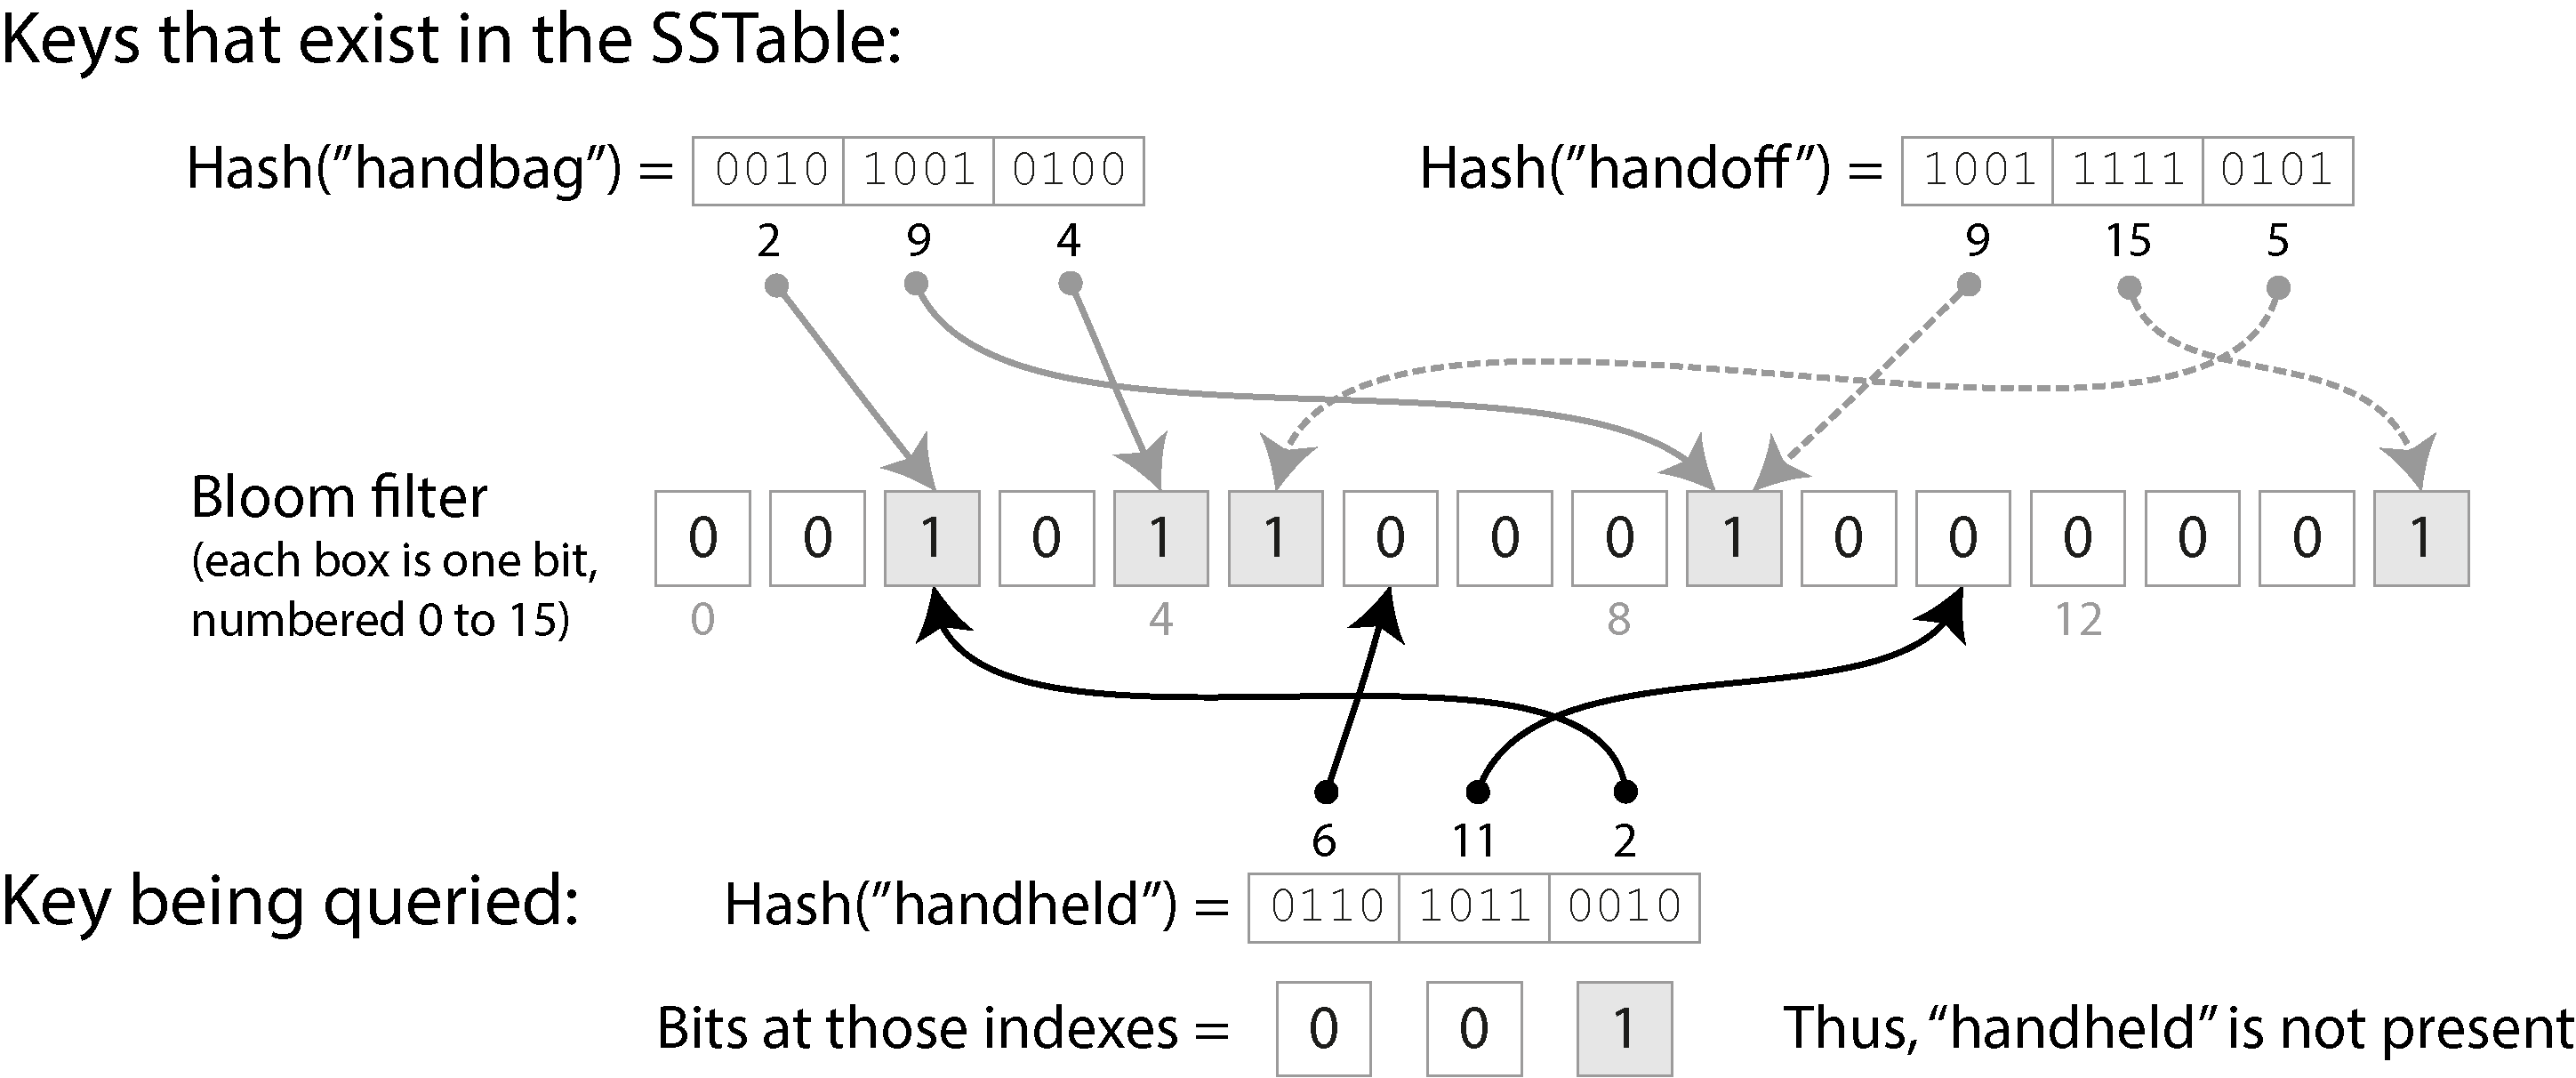

As a rule of thumb, you need to allocate 10 bits of Bloom filter space for every key in the SSTable to get a false-positive probability of 1%, and the probability is reduced tenfold for every 5 additional bits you allocate per key.

In the context of LSM storage engines, false positives are no problem:
- If the Bloom filter says that a key is not present, we can safely skip that SSTable, since we can be sure that it doesn’t contain the key.
- If the Bloom filter says the key is present, we have to consult the sparse index and decode the block of key-value pairs to check whether the key really is there. If it was a false positive, we have done a bit of unnecessary work, but otherwise no harm is done—we just continue the search with the next-oldest segment.

**Compaction strategies**

Compaction strategies

An important detail is how the LSM storage chooses when to perform compaction and which SSTables to include in a compaction. Many LSM-based storage systems allow you to configure which compaction strategy to use. Some of the common choices are as follows:

- Size-tiered compaction

Newer and smaller SSTables are successively merged into older and larger SSTables. For example, four 256 MB SSTables might be compacted into one 898 MB SSTable (the result is not 1,024 MB because of deletions, overwrites, time-to-live expirations, and so on). The SSTables containing older data can get very large, and merging them requires a lot of temporary disk space. The advantage of this strategy is that it can handle very high write throughput since most data is rewritten only a few times in larger sequential merges.

- Leveled compaction

Instead of writing large SSTables, leveled compaction keeps SSTable sizes fixed and groups them into increasing “levels” (referred to as L0, L1, and so on). L0 contains the most recently written data. All levels beyond L0 contain key range–partitioned SSTables. For example, L1 might have two SSTables: the first with keys a–m and the second with n–z. Each level has its own size limit, and each level is larger than the level that precedes it (e.g., L2 will be larger than L1). When a level’s SSTables combine to exceed a maximum size limit, one or more SSTables from level i are merged into level i + 1 and deleted from level i. This approach allows compaction to proceed more incrementally and use less disk space than the size-tiered strategy. Leveled compaction is more efficient for reads than size-tiered compaction because the storage engine needs to read fewer SSTables to check whether they contain the key.

As a rule of thumb, size-tiered compaction performs better if you have mostly writes and few reads, whereas leveled compaction performs better if your workload is dominated by reads.

### B-Trees

The log-structured approach is popular, but it is not the only form of key-value storage. The most widely used structure for reading and writing database records by key is the B-tree.

The log-structured indexes we saw earlier break the database into variable-size segments, typically several megabytes or more in size, that are written once and are then immutable. By contrast, B-trees break the database into fixed-size *blocks* or *pages* and may overwrite a page in place. A page is traditionally 4 KiB in size, but PostgreSQL now uses 8 KiB and MySQL uses 16 KiB by default.

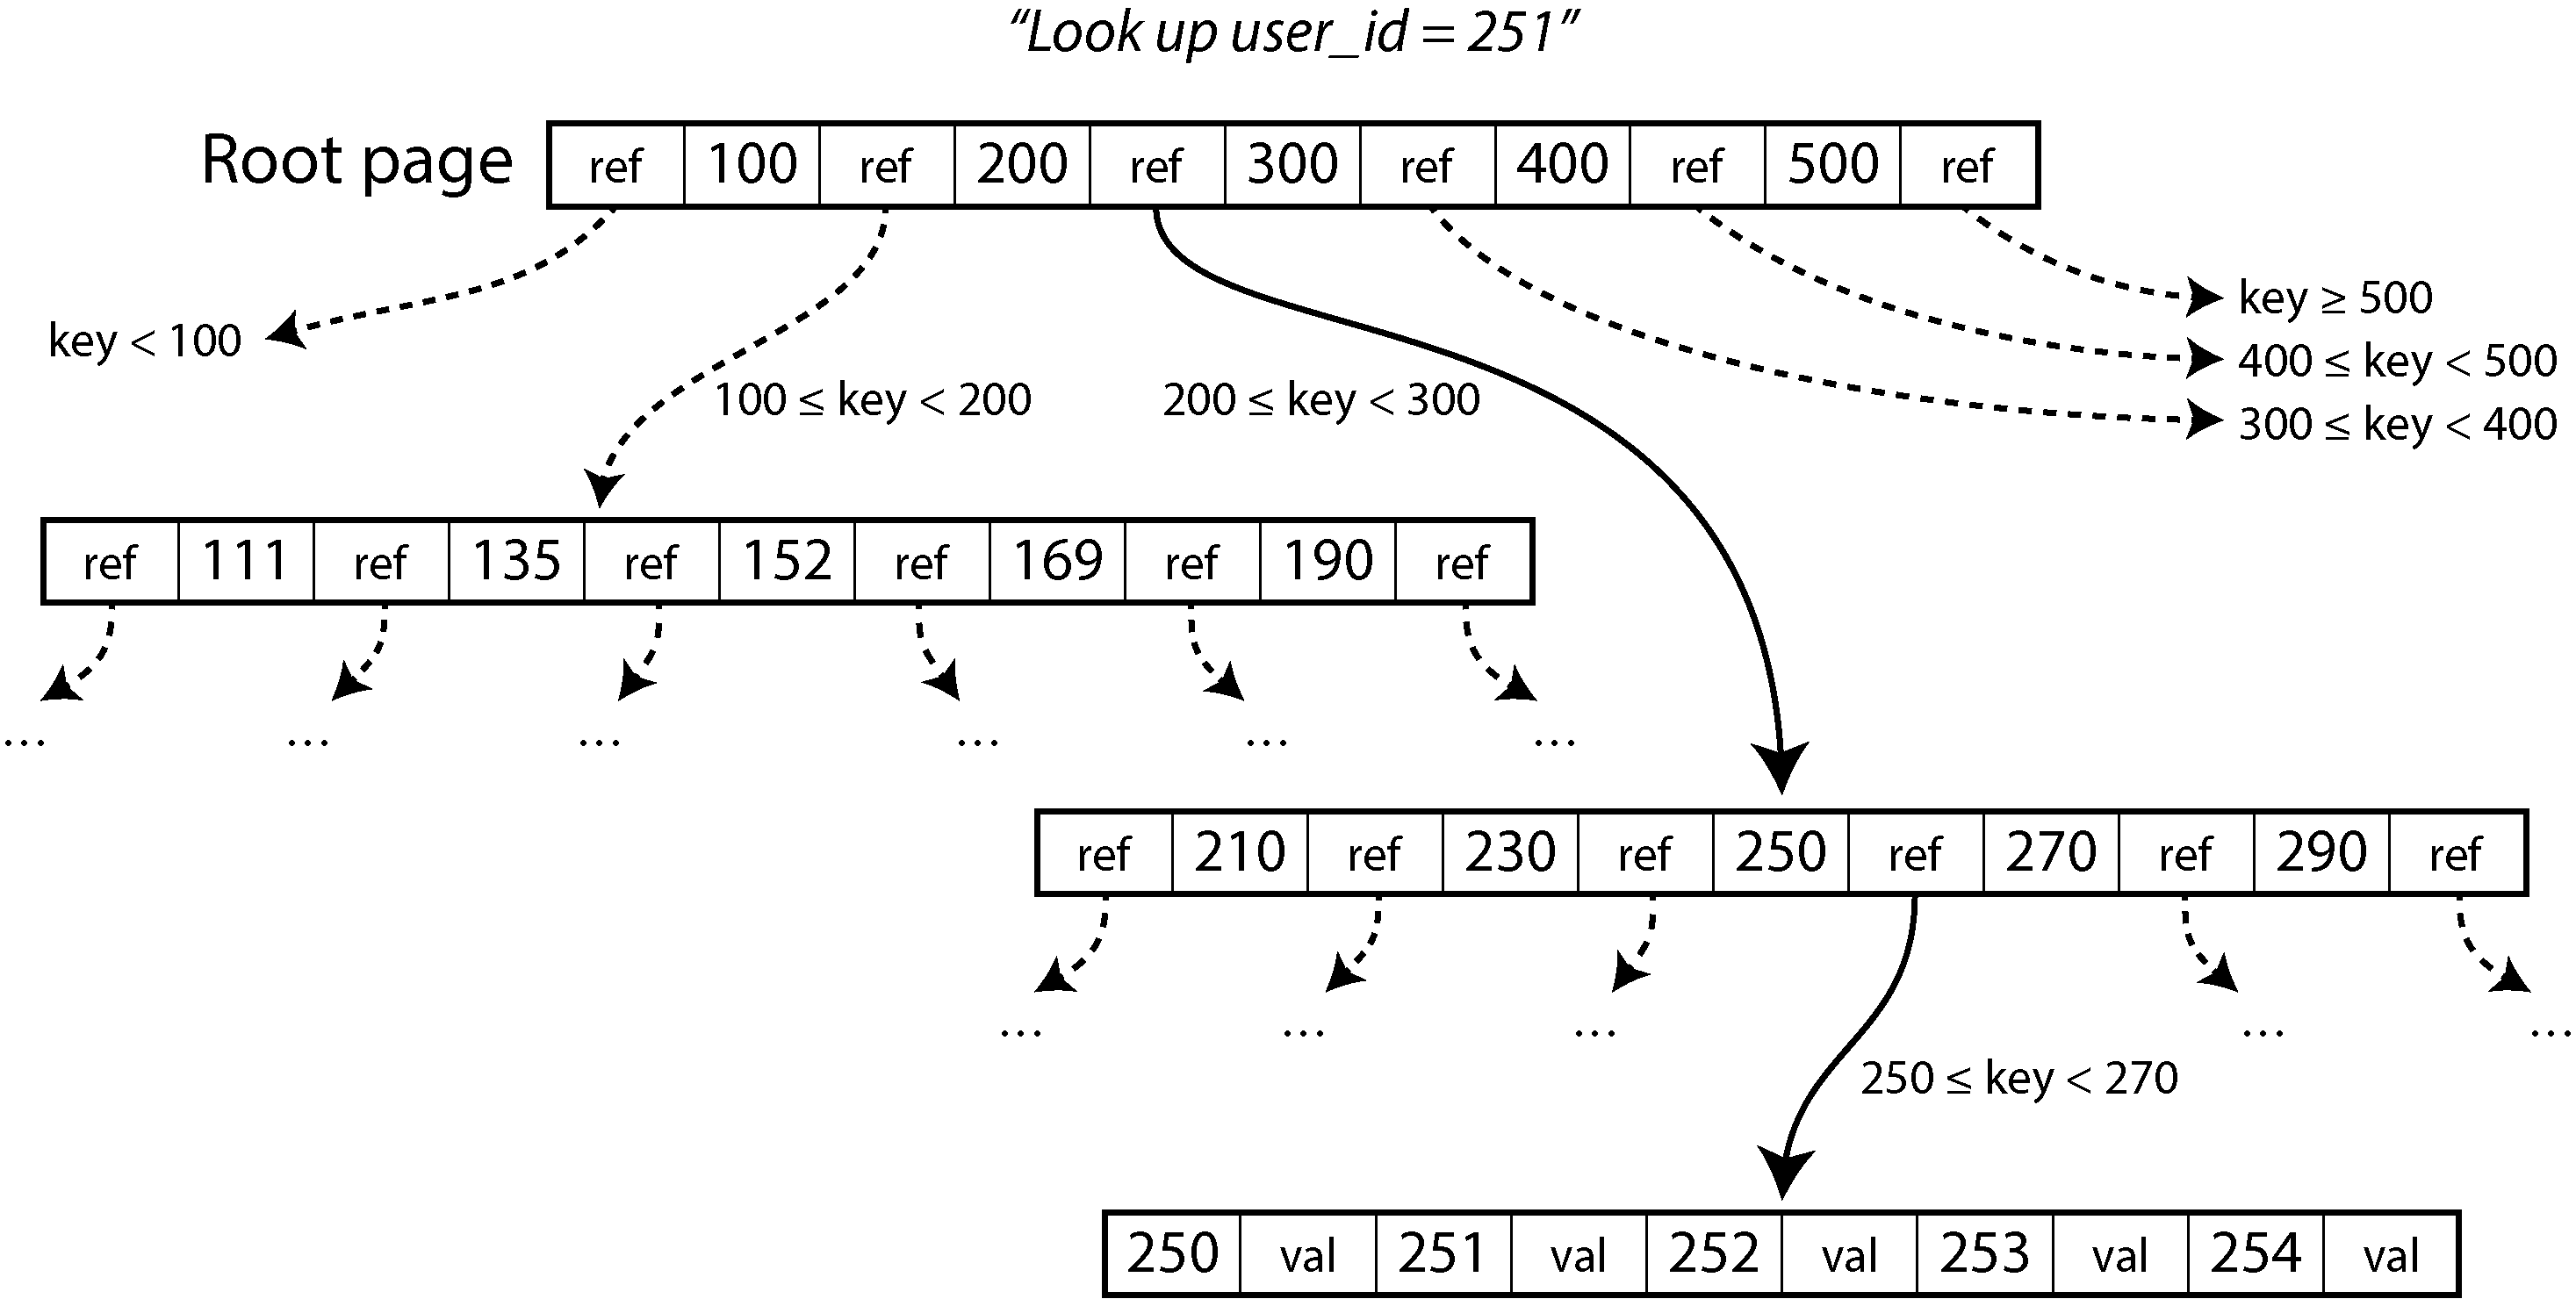

The number of references to child pages in one page of the B-tree is called the *branching factor*. For example, in Figure 4-5 the branching factor is six. In practice, the branching factor depends on the amount of space required to store the page references and the range boundaries, but typically it is several hundred.

Making B-trees reliable

To make the database resilient to crashes, it is common for B-tree implementations to include an additional data structure on disk: a *write-ahead log* (WAL). This is an append-only file to which every B-tree modification must be written before it can be applied to the pages of the tree itself. When the database comes back up after a crash, this log is used to restore the B-tree back to a consistent state [2, 24]. In filesystems, the equivalent mechanism is known as *journaling*.

### Comparing B-Trees and LSM-Trees

As a rule of thumb, LSM-trees are better suited for write-heavy applications, whereas B-trees are faster for reads.

**Read performance**

In a B-tree, looking up a key involves reading one page at each level. Since the number of levels is usually quite small, reads from a B-tree are generally fast and have predictable performance. In an LSM storage engine, reads often have to check several SSTables at different stages of compaction, but Bloom filters help reduce the number of disk I/O operations required. Both approaches can perform well, and which is faster depends on the details of the storage engine and the workload.

**Sequential versus random writes**

With a B-tree, if the application writes keys that are scattered all over the key space, the resulting disk operations are also scattered randomly, since the pages that the storage engine needs to overwrite could be located anywhere on disk. On the other hand, a log-structured storage engine writes entire segment files at a time (either writing out the memtable or while compacting existing segments), which are much bigger than a page in a B-tree.

The pattern of many small, scattered writes (as found in B-trees) is called random writes, while the pattern of fewer large writes (as found in LSM-trees) is called sequential writes. Disks generally have higher sequential write throughput than random write throughput, which means that a log-structured storage engine can generally handle higher write throughput on the same hardware than a B-tree.

### Multicolumn and Secondary Indexes

It is also very common to have secondary indexes. In relational databases, you can create several secondary indexes on the same table by using the CREATE INDEX command, allowing you to search by columns other than the primary key.

### Storing Values Within the Index

The key in an index is what queries search by. Other data may be stored in the index, in addition to the keys, depending on the type of index:
- If the actual data (row, document, vertex) is stored directly within the index structure, it is called a *clustered index*. For example, in MySQL’s InnoDB storage engine, the primary key of a table is always a clustered index, and in SQL Server, you can specify one clustered index per table [43].
- Alternatively, the value can be a reference to the actual data: either the primary key of the row in question (InnoDB does this for secondary indexes) or a direct reference to a location on disk. In the latter case, the place where rows are stored is known as a *heap file*, and it stores data in no particular order (it may be append-only, or it may keep track of deleted rows in order to overwrite them with new data later). For example, Postgres uses the heap file approach
- A middle ground between the two is a *covering index* or *index with included columns*, which stores some of a table’s columns within the index, in addition to storing the full row on the heap or in the primary-key clustered index [45]. This allows some queries to be answered by using the index alone, without having to resolve the primary key or look in the heap file (in which case, the index is said to cover the query). This can make some queries faster, but the duplication of data means the index uses more disk space and slows down writes

### Keeping Everything in Memory

We tolerate disks because disks have two significant advantages: they are durable (their contents are not lost if the power is turned off), and they have a lower cost per gigabyte than RAM.

As RAM becomes cheaper, the cost-per-gigabyte argument is eroded. Many datasets are simply not that big, so it’s quite feasible to keep them entirely in memory, potentially distributed across several machines. This has led to the development of *in-memory databases*.

Counterintuitively, the performance advantage of in-memory databases is not due to the fact that they don’t need to read from disk. Even a disk-based storage engine may never need to read from disk if you have enough memory, because the operating system caches recently used disk blocks in memory anyway. Rather, they are faster because *they avoid the overheads of encoding in-memory data structures in a form that can be written to disk*.

## Data Storage for Analytics

### Column-Oriented Storage

As discussed in “Stars and Snowflakes: Schemas for Analytics”, data warehouses by convention often use a relational schema with a big fact table that contains foreign-key references into dimension tables. If you have trillions of rows and petabytes of data in your fact tables, storing and querying them efficiently becomes challenging. Dimension tables are usually much smaller and more manageable (millions of rows), so in this section we will focus on storage of facts.

A row-oriented storage engine still needs to load all those rows (each consisting of over 100 attributes) from disk into memory, parse them, and filter out those that don’t meet the required conditions. That can take a long time.

The idea behind column-oriented (or columnar) storage is simple: instead of storing all the values from one row together, store all the values from each column together instead [56]. If each column is stored separately, a query needs to read and parse only those columns that are used in that query, which can save a lot of work.

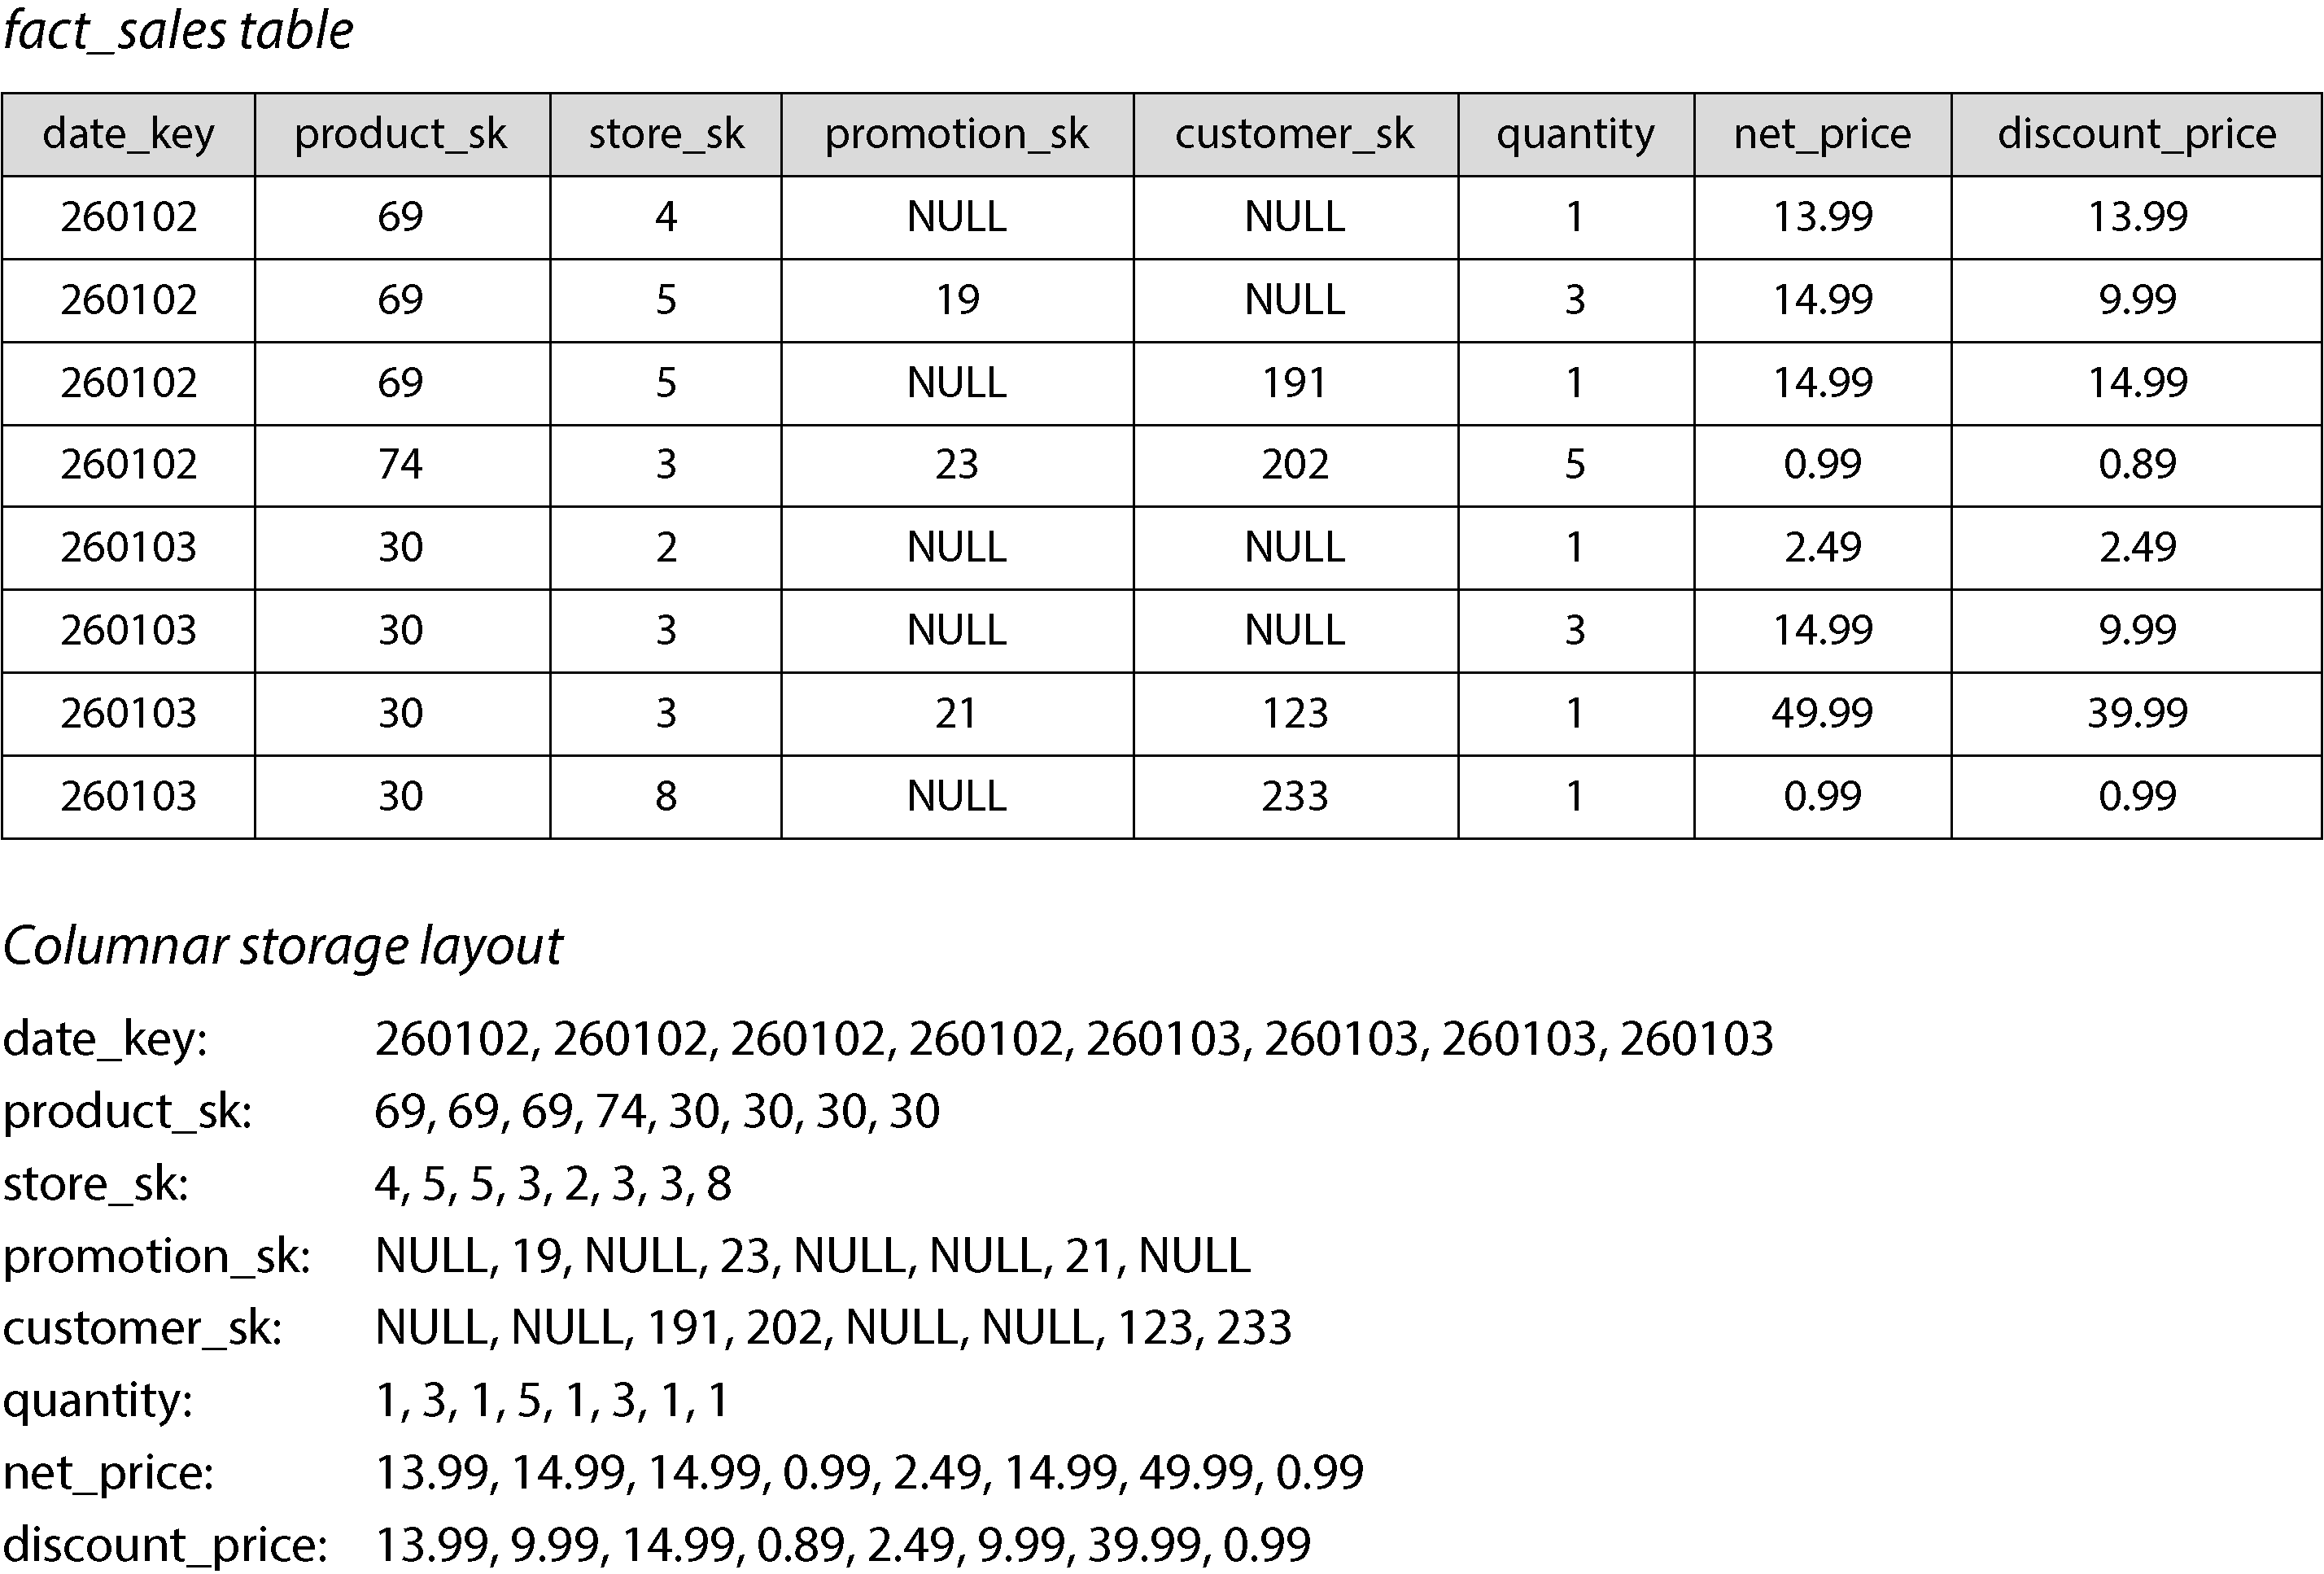

The column-oriented storage layout relies on each column storing the rows in the same order. Thus, if you need to reassemble an entire row, you can take the 23rd entry from each of the individual columns and put them together to form the 23rd row of the table.

Columnar storage is used in almost all analytical databases nowadays [60], ranging from large-scale cloud data warehouses such as Snowflake [61] to single-node embedded databases such as DuckDB [62] and product analytics systems such as Pinot [63] and Druid [64]. It is used in storage formats such as Parquet, ORC [65, 66], Lance [67], and Nimble [68] and in-memory analytics formats like Apache Arrow [65, 69] and Pandas/NumPy [70]. Some time-series databases, such as InfluxDB IOx [71] and TimescaleDB [72], are also based on column-oriented storage.

## Multidimensional and Full-Text Indexes

A multidimensional indexes allow you to query several columns at once.

When a user is looking at the restaurants on a map, the website needs to search for all the restaurants within the rectangular map area that the user is currently viewing. This requires a two-dimensional range query like the following:

```sql
SELECT * FROM restaurants WHERE latitude  > 51.4946 AND latitude  < 51.5079
                            AND longitude > -0.1162 AND longitude < -0.1004;
```                            
One option is to translate a two-dimensional location into a single number via a space-filling curve, then use a regular B-tree index [83]. More commonly, specialized spatial indexes such as R-trees or Bkd-trees [84] are used;

### Full-Text Search

Full-text search allows you to search a collection of text documents (web pages, product descriptions, etc.) by keywords that might appear anywhere in the text.

St its core, you can think of full-text search as another kind of multidimensional query. In this case, each word that might appear in a text (a term) is a dimension. A document that contains term x has a value of 1 in dimension x, and a document that doesn’t contain x has a value of 0. Searching for documents mentioning “red apples” means a query that looks for a 1 in the red dimension and, simultaneously, a 1 in the apples dimension. The number of dimensions may thus be very large.

The data structure that many search engines use to answer such queries is called an *inverted index*. This is a key-value structure where the key is a term and the value is the list of IDs of all the documents that contain the term (the postings list).

Example

    Document 1: "Hello world"
    Document 2: "Hello there"
    Inverted Index:
        "hello" -> {Doc 1, Doc 2}
        "world" -> {Doc 1}
        "there" -> {Doc 2}

For example, Lucene, the full-text indexing engine used by Elasticsearch and Solr, works like this.

Instead of breaking text into words, an alternative is to find all the substrings of length n, which are called n-grams. For example, the trigrams (n = 3) of the string hello are hel, ell, and llo. If we build an inverted index of all trigrams, we can search the documents for arbitrary substrings that are at least three characters long. Trigram indexes even allow regular expressions in search queries; the downside is that they are quite large [94].

To cope with typos in documents or queries, Lucene is able to search text for words within a certain *edit distance* (an edit distance of 1 means that one letter has been added, removed, or replaced) [95]. It does this by storing the set of terms as a finite state automaton over the characters in the keys, similar to a trie [96], and transforming it into a *Levenshtein automaton*, which supports efficient search for words within a given edit distance .

### Vector Embeddings

Semantic search goes beyond synonyms and typos to try to understand document concepts and user intentions. It is becoming an important part of AI applications, such as retrieval-augmented generation, which incorporates search results into the output of a large language model (LLM). For example, if your help pages contain a page titled “canceling your subscription,” users should still be able to find that page when searching for “how to close my account” or “terminate contract,” which are close in terms of meaning even though they use completely different words.

To understand a document’s semantics—​its meaning—​semantic search indexes use embedding models to translate a text document into a vector of floating-point values, called a vector embedding.

Search engines use distance functions such as cosine similarity or Euclidean distance to measure the distance between vectors: cosine similarity measures the cosine of the angle of two vectors to determine how close they are, while Euclidean distance measures the straight-line distance between two points in space.

Vector indexes store the vector embeddings of a collection of documents. To query the index, you pass in the vector embedding of the query, and the index returns the documents whose vectors are closest to the query vector.

For them, specialized vector indexes are used, such as these:

- Flat indexes
Vectors are stored in the index as they are. A query must read every vector and measure its distance to the query vector. Flat indexes are accurate, but measuring the distance between the query and each vector is slow.

- Inverted file (IVF) indexes
The vector space is clustered into partitions (called *centroids*) of vectors to reduce the number of vectors that must be compared. IVF indexes are faster than flat indexes but can give only approximate results; the query and a document may fall into different partitions, even though they are close to each other. A query on an IVF index first defines probes, which are simply the number of partitions to check. Queries that use more probes will be more accurate but slower, as more vectors must be compared.

- Hierarchical Navigable Small World (HNSW) indexes
HNSW indexes maintain multiple layers of the vector space, as illustrated in Figure 4-11. Each layer is represented as a graph, where nodes represent vectors and edges represent proximity to nearby vectors. A query starts by locating the nearest vector in the topmost layer, which has a small number of nodes. The query then moves to the same node in the layer below and follows the edges in that layer, which is more densely connected, looking for a vector that is closer to the query vector. The process continues until the last layer is reached. Like IVF indexes, HNSW indexes are approximate.

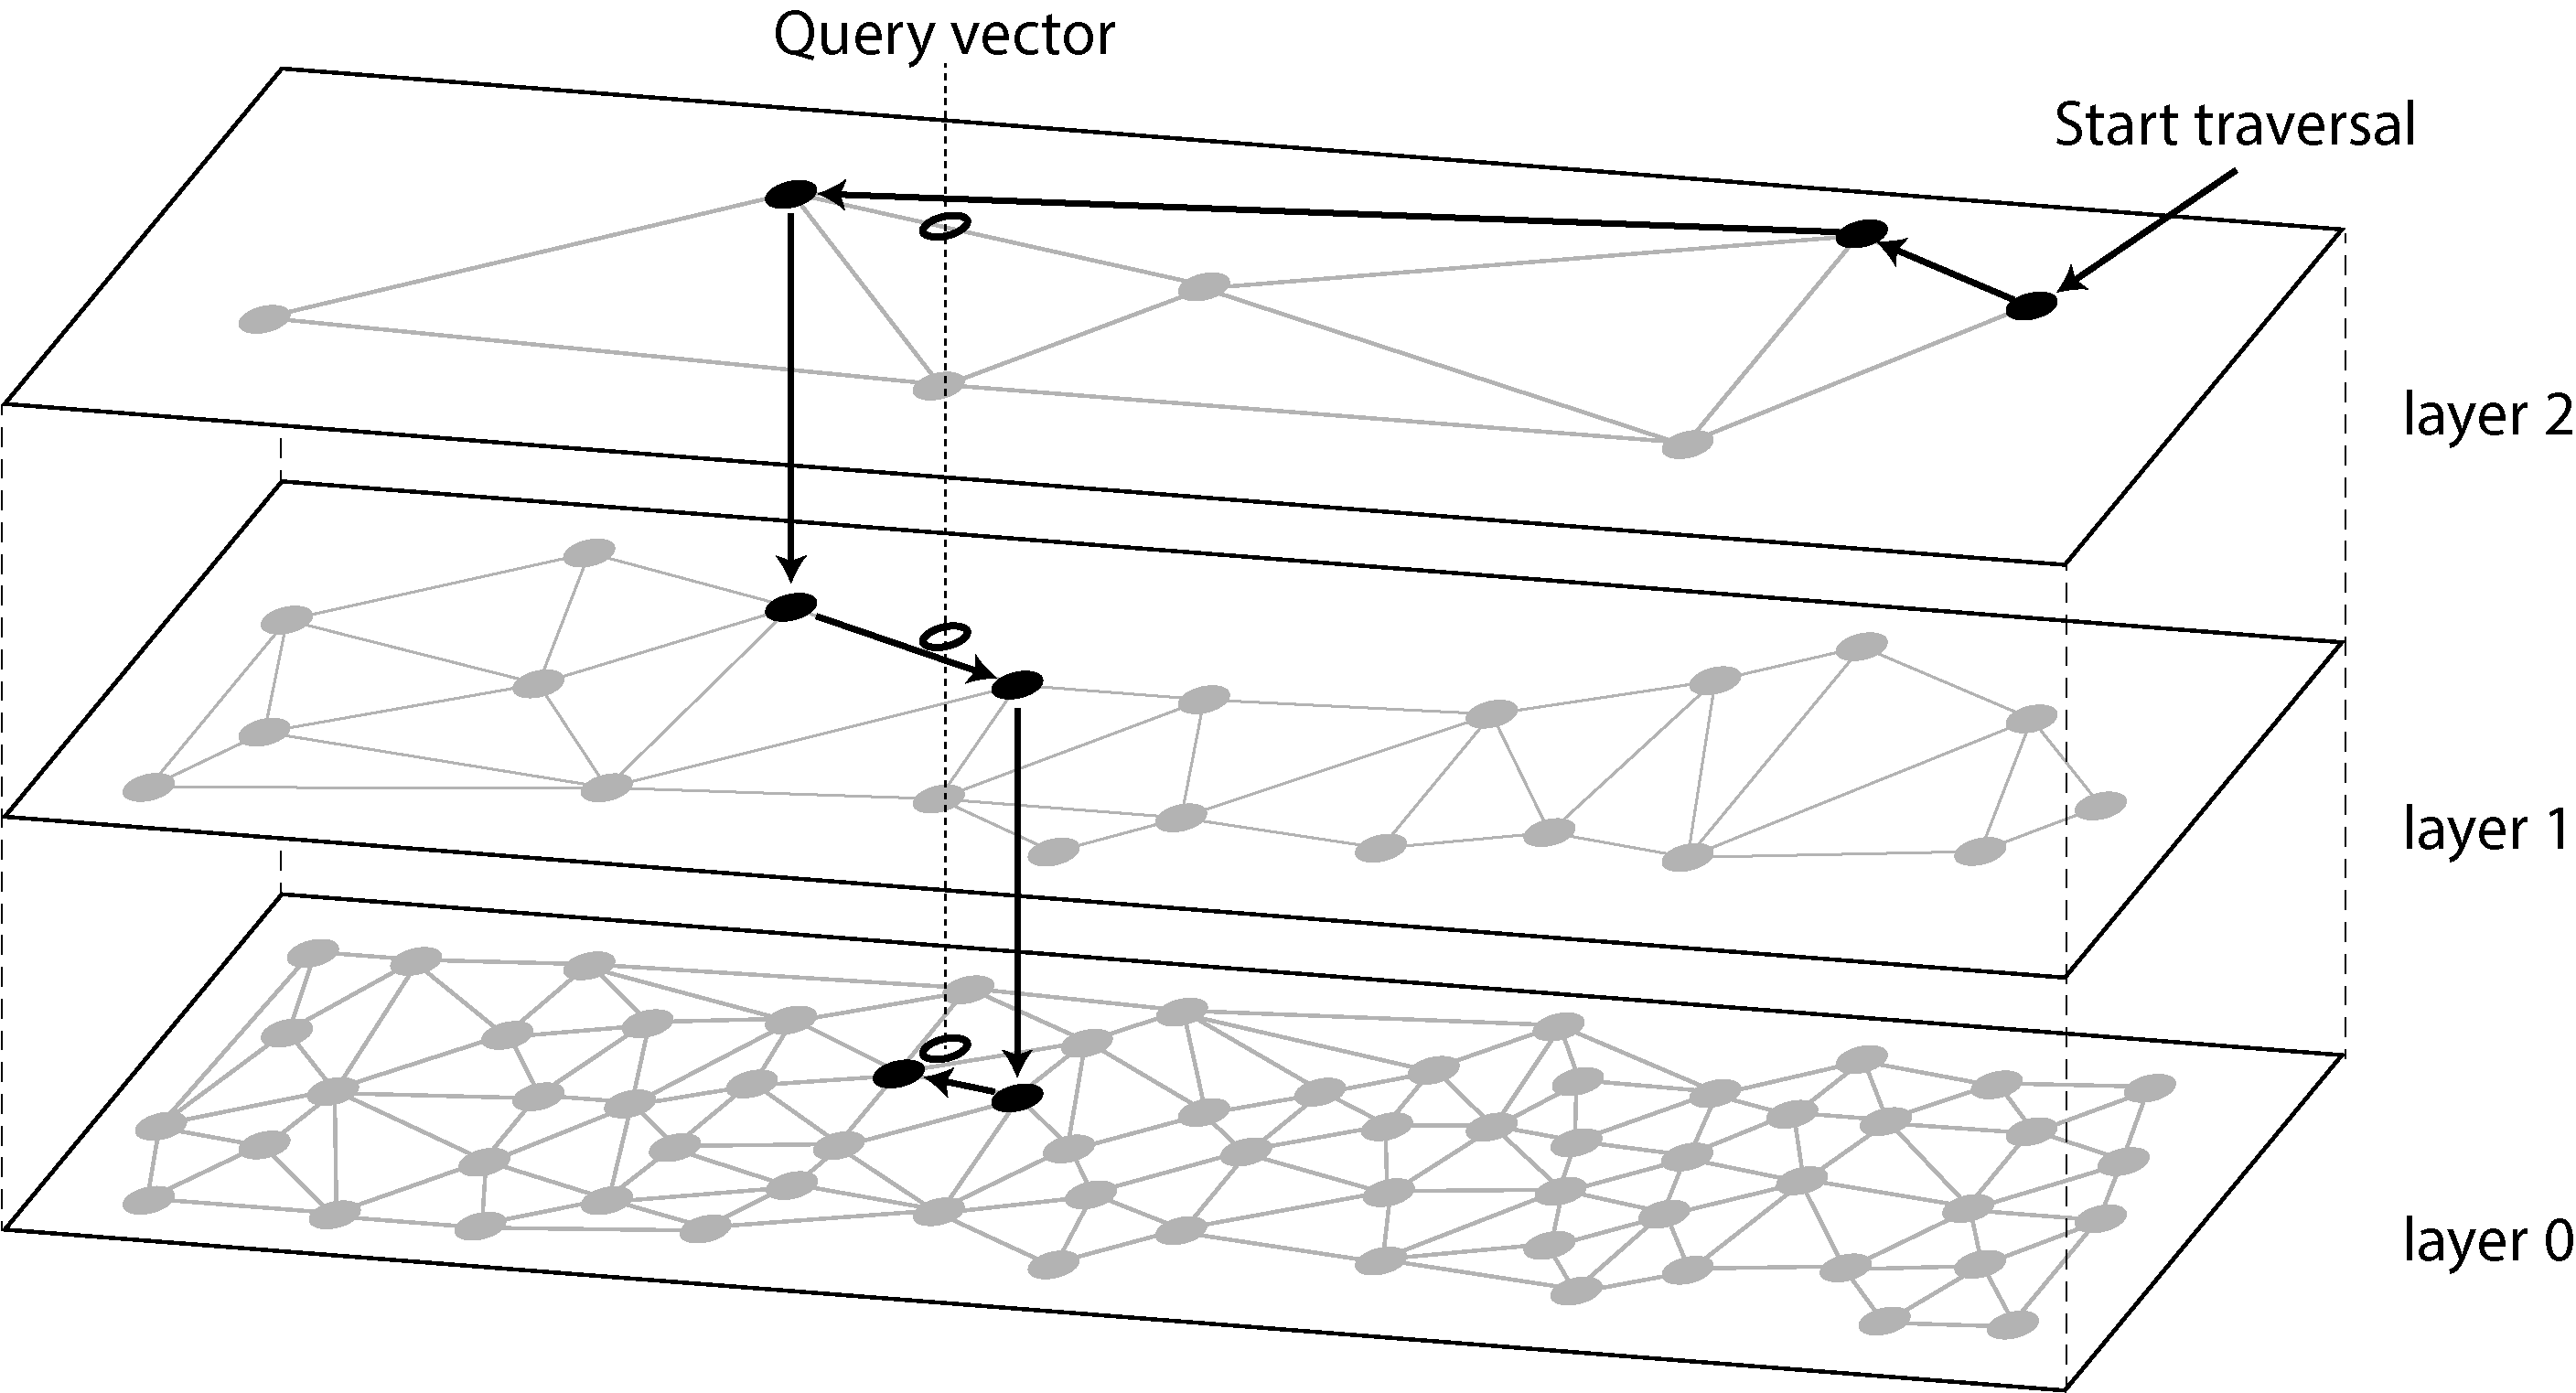

Many popular vector databases implement IVF and HNSW indexes. Facebook’s Faiss library has several variations of each [101], and PostgreSQL’s pgvector supports both as well [102].

# 5 - Encoding and Evolution

## Formats for Encoding Data
Programs usually work with data in (at least) two representations:

1. In memory, data is kept in objects, structs, lists, arrays, hash tables, trees, and so on. These data structures are optimized for efficient access and manipulation by the CPU (typically using pointers).

2. When you want to write data to a file or send it over the network, you have to encode it as some kind of self-contained sequence of bytes (e.g., a JSON document). Since a pointer wouldn’t make sense to any other process, this sequence-of-bytes representation often looks quite different from the data structures that are normally used in memory.

Thus, we need some kind of translation between the two representations. The translation from the in-memory representation to a byte sequence is called *encoding* (also known as *serialization* or *marshaling*), and the reverse is called *decoding* (aka *parsing*, *deserialization*, or *unmarshaling*).

### JSON, XML, and Binary Variants

When moving to standardized encodings that can be written and read by many programming languages, JSON and XML are the obvious contenders: they are widely known and widely supported.

**Binary encodings**

JSON is less verbose than XML, but both still use a lot of space compared to binary formats.


### Protocol Buffers
Protocol Buffers (protobuf) is a binary encoding library developed at Google. It is similar to Apache Thrift, which was originally developed by Facebook [14]; most of what this section says about Protocol Buffers also applies to Thrift.
Protocol Buffers requires a schema for any data that is encoded. To encode the data in Example 5-2, you would describe the schema in the Protocol Buffers interface definition language (IDL) like this:
syntax = "proto3";
```proto
message Person {
    string user_name = 1;
    int64 favorite_number = 2;
    repeated string interests = 3;
}
```

## Modes of Dataflow

### Dataflow Through Services: REST and RPC

When you have processes that need to communicate over a network, you can arrange that communication in a few ways. The most common arrangement is to have two roles: clients and servers. The servers expose an API over the network, and the clients can connect to the servers to make requests to that API. The API exposed by the server is known as a *service*.

The web works this way: clients (web browsers) make requests to web servers, making GET requests to download HTML, CSS, JavaScript, images, etc. and making POST requests to submit data to the server. The API consists of a standardized set of protocols and data formats (HTTP, URLs, SSL/TLS, HTML, etc.). Because web browsers, web servers, and website authors mostly agree on these standards, you can use any web browser to access any website (at least in theory!).

The most popular service design philosophy is REST, which builds upon the principles of HTTP [31, 32]. REST emphasizes simple data formats, using URLs for identifying resources and using HTTP features for cache control, authentication, and content type negotiation. An API designed according to the principles of REST is called RESTful.

Developers typically write OpenAPI service definitions in JSON or YAML (see Example 5-3). The service definition allows developers to define service endpoints, documentation, versions, data models, and much more. Protocol Buffers service definitions use the IDL we saw in “Protocol Buffers”.


Example 5-3. An OpenAPI service definition in YAML
```yaml
openapi: 3.0.0
info:
  title: Ping, Pong
  version: 1.0.0
servers:
  - url: http://localhost:8080
paths:
  /ping:
    get:
      summary: Given a ping, returns a pong message
      responses:
        '200':
          description: A pong
          content:
            application/json:
              schema:
                type: object
                properties:
                  message:
                    type: string
                    example: Pong!
```                    

A service framework, such as Spring Boot, FastAPI, or gRPC, is often adopted to simplify this effort. Service frameworks allow developers to focus on writing the business logic for each API endpoint, while the framework code handles routing, metrics, caching, authentication, and so on. Example 5-4 shows a Python implementation of the service defined in Example 5-3.

Example 5-4. A FastAPI service implementing the definition from Example 5-3
```python
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Ping, Pong", version="1.0.0")

class PongResponse(BaseModel):
    message: str = "Pong!"

@app.get("/ping", response_model=PongResponse,
         summary="Given a ping, returns a pong message")
async def ping():
    return PongResponse()
```    

**The problems with remote procedure calls**

Remote procedure calls (RPC), introduced back in the 1970s [38]. The RPC model tries to make a request to a remote network service look the same as calling a function or method, within the same process (this abstraction is called location transparency). Although this seems convenient at first, the approach is fundamentally flawed [39, 40].

**Load balancers, service discovery, and service meshes**

Load balancers

Spreading requests across these instances is called load balancing.

Service discovery systems

These use a centralized registry such as etcd or Apache ZooKeeper rather than DNS to track which service endpoints are available. When a new service instance starts up, it registers itself with the service discovery system by declaring the host and port it’s listening on, along with relevant metadata such as shard ownership information (see Chapter 7), datacenter location, and more.

Service meshes

This sophisticated form of load balancing combines software load balancers and service discovery. Unlike traditional software load balancers, which run on a separate machine, a service mesh load balancer is typically deployed as an in-process client library or as a process or “sidecar” container on both the client and server. Client applications connect to their own local service load balancer, which connects to the server’s load balancer. From there, the connection is routed to the local server process.

Though complicated, this topology offers advantages. Because the clients and servers are routed entirely through local connections, connection encryption can be handled entirely at the load balancer level. This shields clients and servers from having to deal with the complexities of SSL certificates and TLS. Mesh systems also provide sophisticated observability. They can track which services are calling each other in real time, detect failures, track traffic load, and more.

### Event-Driven Architectures

In this final section, we will briefly look at event-driven architectures, which are another way encoded data can flow from one process to another. In this context, a request is called an *event* or *message*. Unlike with RPC, the sender usually does not wait for the recipient to process the event. Additionally, events are typically not sent to the recipient via a direct network connection, but go via an intermediary called a *message broker* (also called an *event broker*, *message queue*, or *message-oriented middleware*), which stores the message temporarily [51].

Using a message broker has several advantages compared to direct RPC:

- It can act as a buffer if the recipient is unavailable or overloaded, improving system reliability.
- It can automatically redeliver messages to a process that has crashed, preventing messages from being lost.
- It avoids the need for service discovery, since senders do not need to directly connect to the IP address of the recipient.
- It allows the same message to be sent to several recipients.
- It logically decouples the sender from the recipient (the sender just publishes messages and doesn’t care who consumes them).

The communication via a message broker is asynchronous: the sender doesn’t wait for the message to be delivered, but simply sends it and then forgets about it. It is possible, however, to implement a synchronous RPC-like model by having the sender wait for a response on a separate channel.

**Message brokers**

In the past, the landscape of message brokers was dominated by commercial enterprise software from companies such as TIBCO, IBM WebSphere, and webMethods, before open source implementations such as RabbitMQ, ActiveMQ, HornetQ, NATS, Redpanda, and Apache Kafka become popular. More recently, cloud services such as Amazon Kinesis, Azure Service Bus, and Google Cloud Pub/Sub have gained adoption. We will compare them in more detail in Chapter 12.

The detailed delivery semantics vary by implementation and configuration, but in general, two message distribution patterns are most often used:

- One process adds a message to a named *queue*, and a *consumer* of the queue then receives the message. If there are multiple consumers, one of them receives the message.

- One process publishes a message to a named *topic*, and the broker delivers that message to all *subscribers* of that topic. If there are multiple subscribers, they all receive the message.

Message brokers typically don’t enforce any particular data model. A message is just a sequence of bytes with some metadata, so you can use any encoding format. A common approach is to use Protocol Buffers, Avro, or JSON, and to deploy a schema registry alongside the message broker to store all the valid schema versions and check their compatibility [20, 22]. AsyncAPI, a messaging-based equivalent of OpenAPI, can also be used to specify the schema of messages.

6 - Replication

Replication means keeping a copy of the same data on multiple machines that are connected via a network. There are several reasons you might want to replicate data, including:

- To keep the data geographically close to your users (and thus reduce access latency)
- To allow the system to continue working even if some of its parts have failed (and thus increase availability and durability)

- To scale out the number of machines that can serve read queries (and thus increase read throughput)

## Single-Leader Replication

Each node that stores a copy of the database is called a *replica*.

Every write to the database needs to be processed by every replica; otherwise, the replicas would no longer contain the same data. The most common solution is called leader-based, primary-backup, or active/passive replication. It works as follows (see Figure 6-1):

- One of the replicas is designated the leader (also known as the primary or source [2]). When clients want to write to the database, they must send their requests to the leader, which first writes the new data to its local storage.
-  The other replicas are known as followers (or read replicas, secondaries, or hot standbys). Whenever the leader writes new data to its local storage, it also sends the data change to all its followers as part of a *replication log* or *change stream*. Each follower takes the log from the leader and updates its local copy of the database accordingly, by applying all writes in the same order as they were processed on the leader.

- When a client wants to read from the database, it can query either the leader or any of the followers. However, writes are accepted only by the leader (the followers are read-only from the client’s point of view).

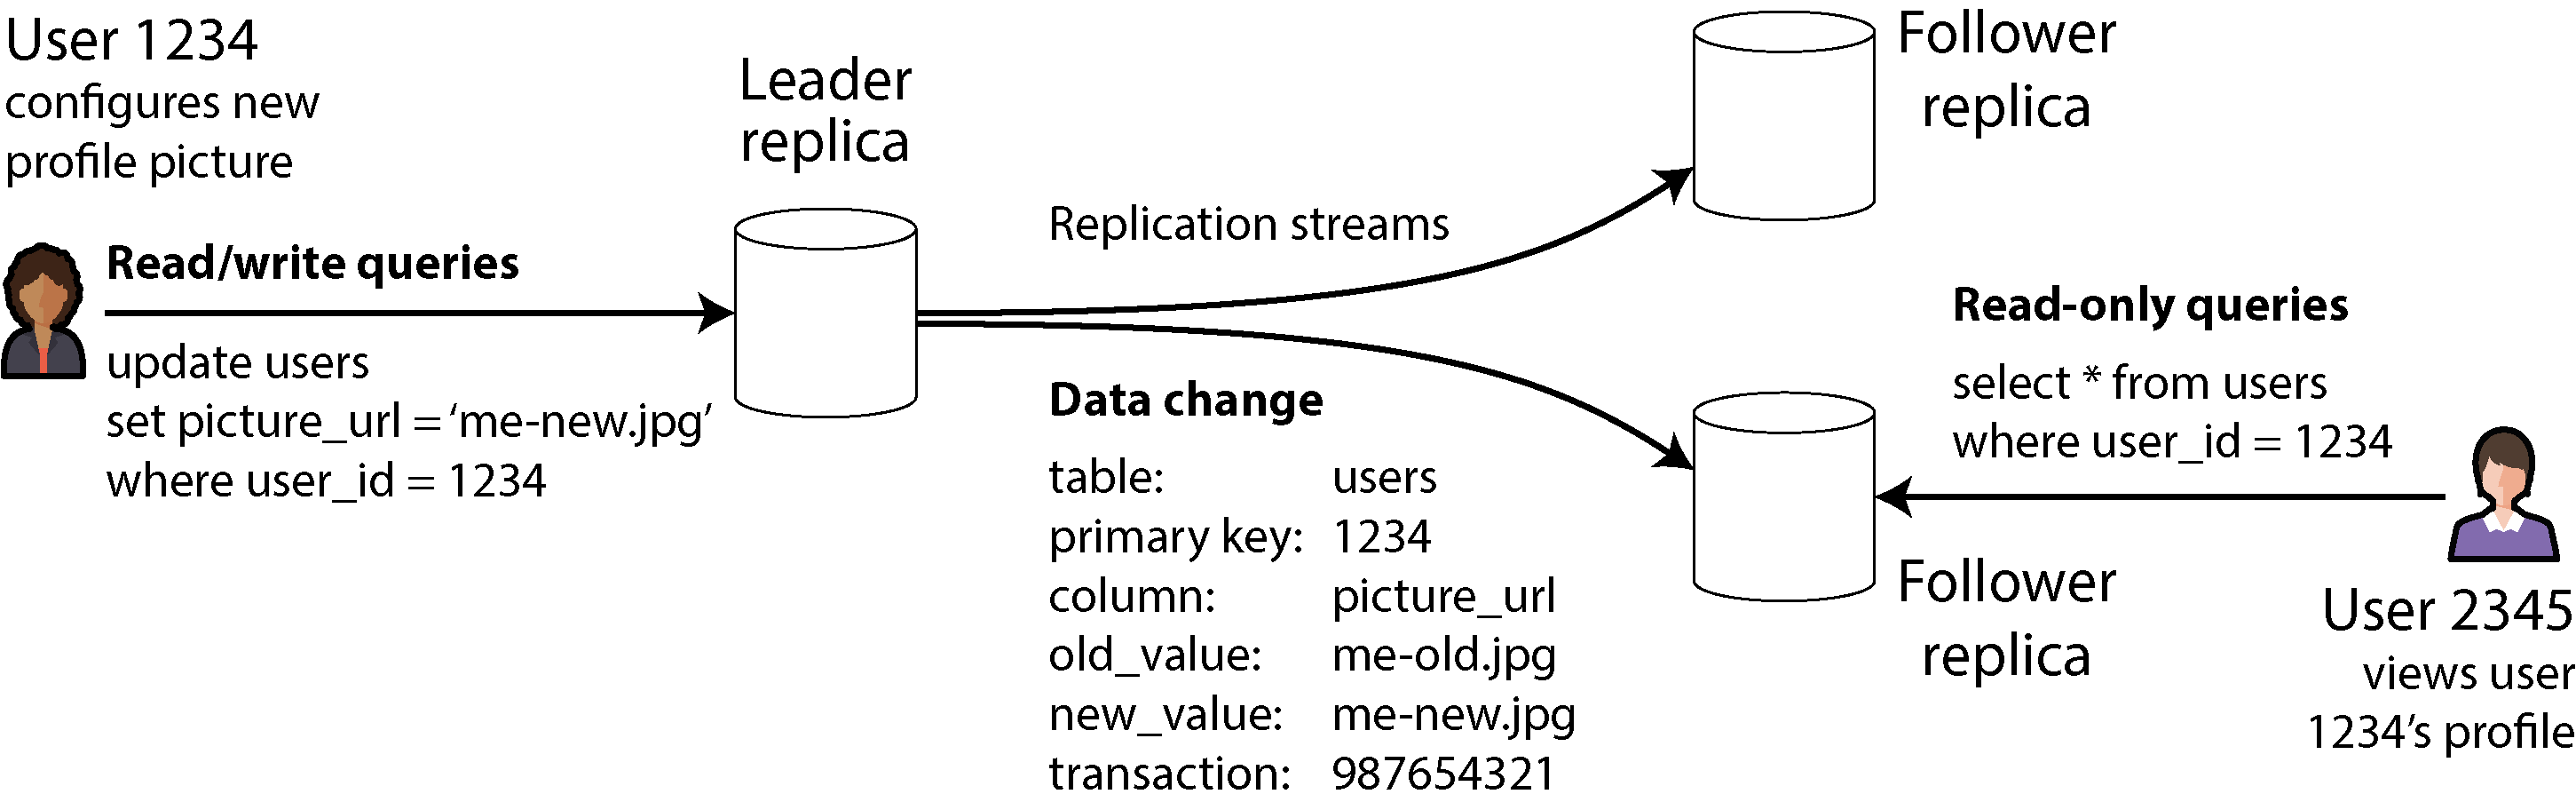

Single-leader replication is very widely used. It’s a built-in feature of many relational databases, such as PostgreSQL, MySQL, Oracle Data Guard [3], and SQL Server’s Always On availability groups [4]. It is also used in some document databases (such as MongoDB and DynamoDB [5]), message brokers such as Kafka, replicated block devices such as DRBD, and some network filesystems.

Many consensus algorithms—such as Raft, which is used for replication in CockroachDB [6], TiDB [7], etcd, and RabbitMQ quorum queues (among others)—are also based on a single leader and automatically elect a new leader if the old one fails

### Synchronous Versus Asynchronous Replication

An important detail of a replicated system is whether the replication happens synchronously or asynchronously.

n practice, if a database offers synchronous replication, it often means that one of the followers is synchronous and the others are asynchronous. If the synchronous follower becomes unavailable or slow, one of the asynchronous followers is made synchronous. This guarantees that you have an up-to-date copy of the data on at least two nodes: the leader and one synchronous follower. This configuration is sometimes also called *semisynchronous*.

In some systems, a majority of replicas (e.g., three out of five, including the leader) are updated synchronously, and the remaining minority are asynchronous. This is an example of a quorum, which we will discuss further in “Using quorums for reading and writing”. Majority quorums are often used in eventually consistent systems or systems that use a consensus protocol for automatic leader election.

### Setting Up New Followers

You could make the files on disk consistent by locking the database (making it unavailable for writes), but that would go against our goal of high availability. Fortunately, setting up a follower can usually be done without downtime. Conceptually, the process looks like this:

- Take a consistent snapshot of the leader’s database at some point in time—if possible, without locking the entire database. Most databases have this feature, as it is also required for backups. In some cases, third-party tools are needed, such as Percona XtraBackup for MySQL.
- Copy the snapshot to the new follower node.
- The follower connects to the leader and requests all the data changes that have happened since the snapshot was taken. This requires that the snapshot is associated with an exact position in the leader’s replication log. That position has various names—for example, PostgreSQL calls it the log sequence number; MySQL has two mechanisms, binlog coordinates and global transaction identifiers (GTIDs).
- When the follower has processed the backlog of data changes since the snapshot, we say it has caught up. It can now continue to process data changes from the leader as they happen.

### Handling Node Outages

How do you achieve high availability with leader-based replication?

**Follower failure: Catch-up recovery**

On its local disk, each follower keeps a log of the data changes it has received from the leader. If a follower crashes and is restarted, the follower can recover quite easily: from its log, it knows the last transaction that was processed before the fault occurred.

Thus, the follower can connect to the leader and request all the data changes that occurred during the time when the follower was disconnected. When it has applied these changes, it has caught up to the leader and can continue receiving a stream of data changes as before.

**Leader failure: Failover**

Handling a failure of the leader is trickier. One of the followers needs to be promoted to be the new leader, clients need to be reconfigured to send their writes to the new leader, and the other followers need to start consuming data changes from the new leader. This process is called *failover*.

1. Determining that the leader has failed. Many things could potentially go wrong: crashes, power outages, network issues, and more. There is no foolproof way of detecting what has occurred, so most systems simply use a timeout; nodes frequently bounce messages back and forth between each other, and if a node doesn’t respond for some period of time—say, 30 seconds—it is assumed to be dead.

2. Choosing a new leader. This could be done through an election process (where the leader is chosen by a majority of the remaining replicas), or a new leader could be appointed by a previously established controller node [13]. The best candidate for leadership is usually the replica with the most up-to-date data changes from the old leader (to minimize any data loss). Getting all the nodes to agree on a new leader is a consensus problem, discussed in detail in Chapter 10.

3. Reconfiguring the system to use the new leader. Clients now need to send their write requests to the new leader (we discuss this in “Request Routing”). If the old leader comes back, it might still believe that it is the leader, not realizing that the other replicas have forced it to step down. The system needs to ensure that the old leader becomes a follower and recognizes the new leader.

**How do you prevent split brain?**

In certain fault scenarios, two nodes could both believe that they are the leader. This situation, called split brain.

Guarding against split brain by limiting or shutting down old leaders is known as *fencing*; we discuss it in more detail in “Distributed Locks and Leases”.

**Is there a way ensure that the data from an old leader to a new leader won't be lost? what if the data is commited in the old leader but never transferred to a follower?**

Short answer: **you can’t guarantee zero data loss if a write was only ever on the old leader**. If it never reached any follower, and that leader dies permanently, that data is gone. There’s no system that can recover data that existed on exactly one failed machine.

What you *can* do is design things so that situation never counts as “committed” in the first place.

---

*The key distinction: what does “committed” mean?*

In a system with **asynchronous replication**, a write is often considered committed as soon as the leader writes it locally. That means:

* Client gets “success”
* But the data may still only exist on one node

So yes—if the leader crashes before replication, **that write is lost**.

---

*How to avoid that: stronger commit guarantees*

To ensure no committed data is lost, you need to change the rules so a write is only acknowledged after it exists on multiple nodes.

1. Synchronous replication

The leader waits until at least one (or more) followers confirm they’ve written the data before replying to the client.

* If the leader dies → at least one follower has the data
* That follower can safely become the new leader
* Result: **no data loss for acknowledged writes**

Tradeoff: higher latency, possible stalls if replicas are slow

2. Quorum-based systems (consensus)

Systems based on consensus algorithms like Raft consensus algorithm or Paxos algorithm go further:

* A write is committed only when a **majority (quorum)** of nodes have it
* Leader election ensures the new leader must have the latest committed data

That guarantees:

* Any committed write exists on at least one node in every future quorum
* So it **cannot be lost during failover**

This is what systems like etcd or Apache Kafka (with proper settings) rely on.

---

So what about your exact scenario?

> “What if data is committed on the old leader but never transferred?”

There are two cases:

* **Async replication:**
  Yes, it’s lost. The system allowed a “commit” that wasn’t durable across nodes.

* **Sync / quorum replication:**
  That situation is *not allowed to happen*.
  The leader would never have acknowledged the write in the first place.

---

The real tradeoff

You’re choosing between:

* **Low latency, higher risk of data loss** (async)
* **Higher latency, strong durability guarantees** (sync/quorum)

There’s no free option that gives both perfectly—this is a direct consequence of distributed systems tradeoffs (often discussed in terms of the CAP theorem).

---

Bottom line

The only way to ensure no data loss is:

> **Never call a write “committed” until it exists on multiple nodes that can survive a leader failure.**

Anything weaker than that is implicitly accepting some level of data loss during failover.


### Implementation of Replication Logs

How does leader-based replication work under the hood? Several replication methods are used in practice. Let’s look at each one briefly.

**Statement-based replication**

- Statement-based replication
In the simplest case, the leader logs every write request (statement) that it executes and sends that statement log to its followers. For a relational database, this means that every INSERT, UPDATE, or DELETE statement is forwarded to followers, and each follower parses and executes that SQL statement as if it had been received from a client.

Limitations
- Any statement that calls a nondeterministic function, such as NOW to get the current date and time or RAND to get a random number, is likely to generate a different value on each replica.

- If statements use an autoincrementing column, or if they depend on the existing data in the database (e.g., `UPDATE … WHERE <some condition>`), they must be executed in exactly the same order on each replica.

Statement-based replication was used in MySQL before version 5.1. It is still sometimes used today, as it is quite compact, but by default MySQL now switches to row-based replication.

**Write-ahead log shipping**

Since the WAL contains all the information necessary to restore the indexes and heap to a consistent state, we can use the exact same log to build a replica on another node.

This method of replication is used in PostgreSQL and Oracle, among others [17, 18]. The main disadvantage is that the log describes the data at a very low level—a WAL contains details of which bytes were changed in which disk blocks. This makes replication tightly coupled to the storage engine.

**Logical (row-based) log replication**

An alternative is to use different log formats for replication and for the storage engine, which allows the replication log to be decoupled from the storage engine internals. This kind of replication log is called a *logical log*, to distinguish it from the storage engine’s (physical) data representation.

When configured to use row-based replication, MySQL keeps a separate logical replication log, called the binlog, in addition to the WAL. PostgreSQL implements logical replication by decoding the physical WAL into row insertion/update/delete events.

A logical log format is also easier for external applications to parse. This aspect is useful if you want to send the contents of a database to an external system, such as a data warehouse for offline analysis, or a specialized system for building custom indexes and caches [21]. This technique is called *change data capture*.

Example in Postgres:

Table
```
users
------
id | name   | balance
1  | Alice  | 100
2  | Bob    | 50
```

Transaction
```
BEGIN;
UPDATE users SET balance = balance - 20 WHERE id = 1;  -- Alice pays
UPDATE users SET balance = balance + 20 WHERE id = 2;  -- Bob receives
COMMIT;
```

Logical replication stream
```
BEGIN txn_123

UPDATE users
  WHERE id = 1
  SET balance = 80

UPDATE users
  WHERE id = 2
  SET balance = 70

COMMIT txn_123
```

### Problems with Replication Lag

Unfortunately, an application reading from an asynchronous follower may see outdated information if the follower has fallen behind. This leads to apparent inconsistencies in the database; if you run the same query on the leader and a follower at the same time, you may get different results, because not all writes have been reflected in the follower. This inconsistency is a temporary state—if you stop writing to the database and wait a while, the followers will eventually catch up and become consistent with the leader. For that reason, this effect is known as *eventual consistency*.


In this section we will highlight three examples of problems that are likely to occur with replication lag. We’ll also outline some approaches to solving them.

**Reading your own writes**

With asynchronous replication, a problem arises, as illustrated in Figure 6-3: if the user views the data shortly after making a write, the new data may not yet have reached the replica. To the user, it looks as though the data they submitted was lost, so they will be understandably unhappy.


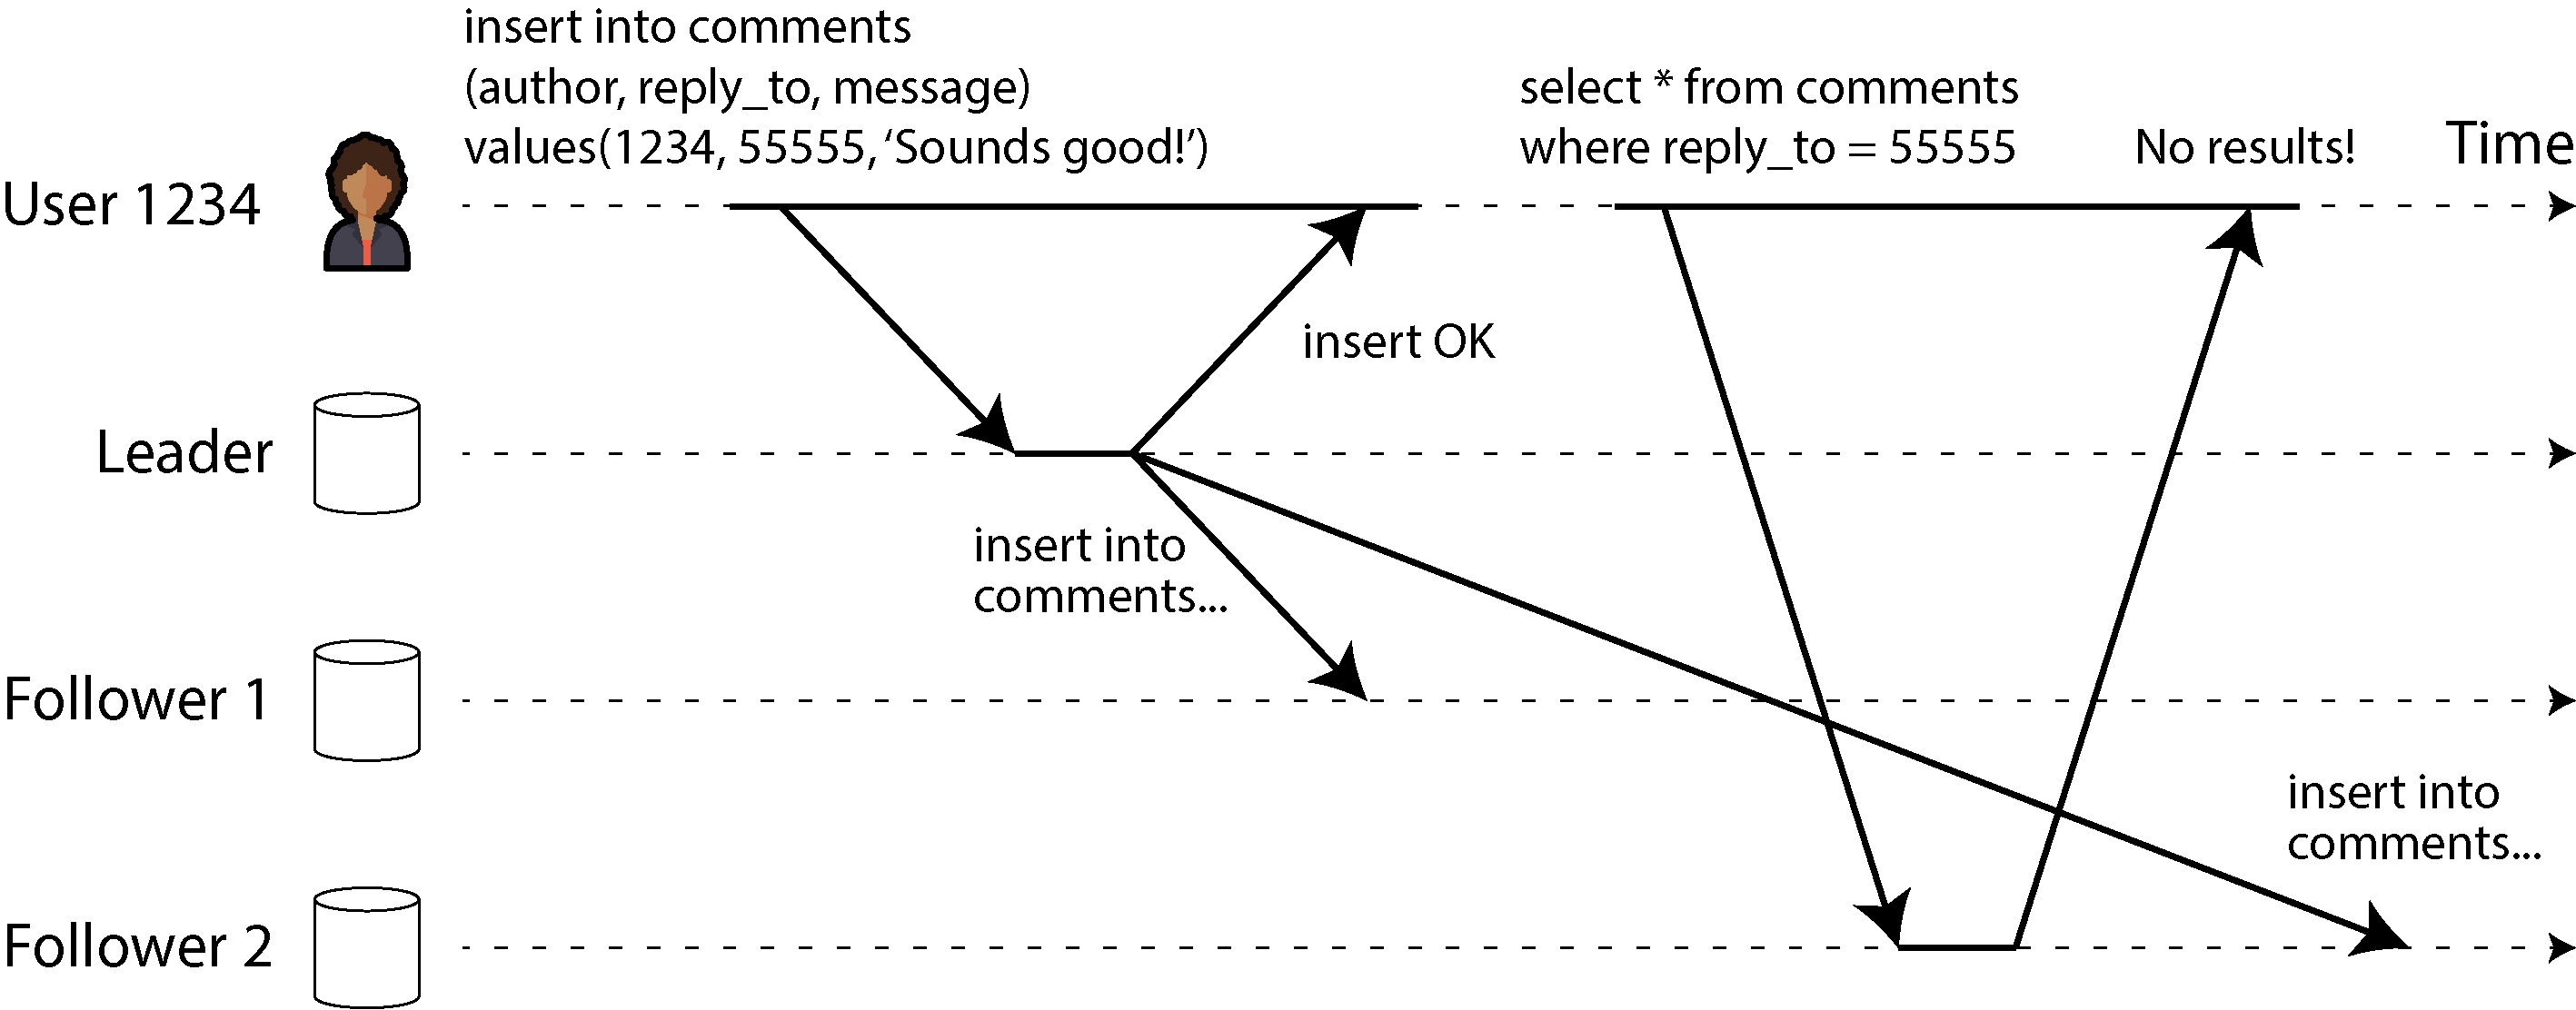

In this situation, we need read-after-write consistency, also known as read-your-writes consistency [23].

How can we implement read-after-write consistency?

- When reading something that the user may have modified, read it from the leader or a synchronously updated follower; otherwise, read it from an asynchronously updated follower.

- To avoid overwhelming the leader, For example, you could track the time of the last update and, for one minute after the last update, make all reads from the leader [25]. You could also monitor the replication lag on followers and prevent queries on any follower that is more than one minute behind the leader.

**Monotonic reads**

Our second example of an anomaly that can occur when reading from asynchronous followers is that it’s possible for a user to see things moving backward in time.

Monotonic reads [22] provide a guarantee that is a lesser guarantee than strong consistency, but a stronger guarantee than eventual consistency. When you read data, you may see an old value; monotonic reads mean only that if one user makes several reads in sequence, they will not see time go backward (i.e., they will not read older data after having previously read newer data).

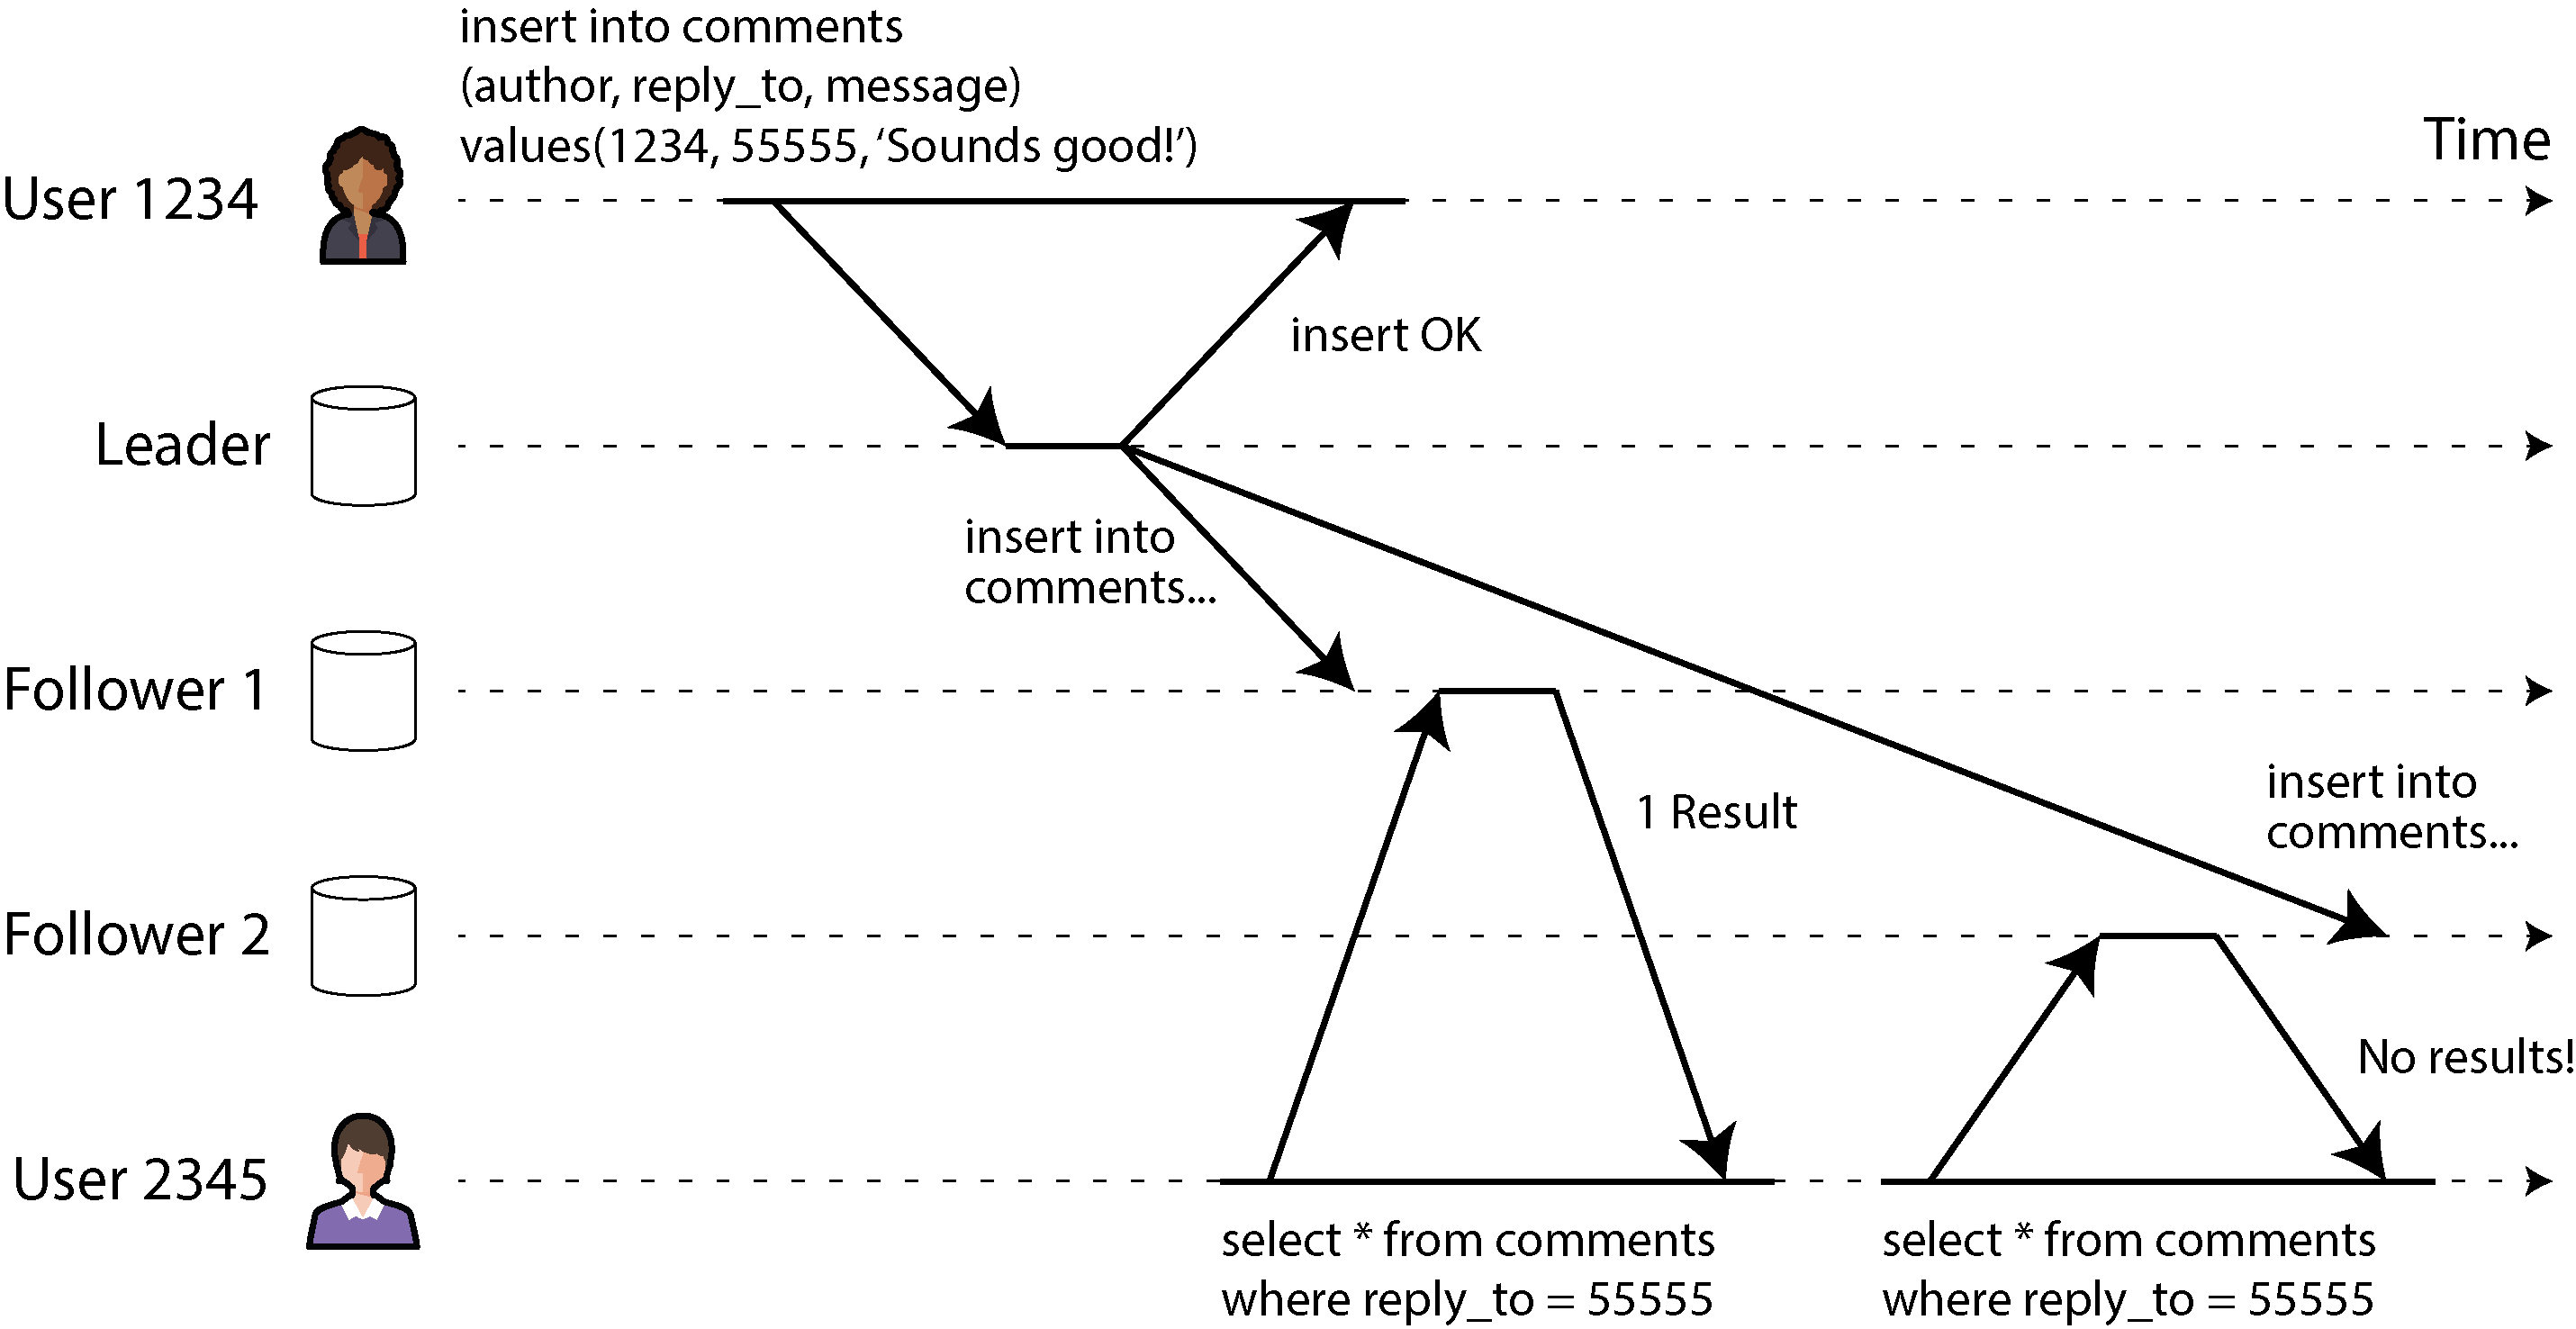

One way of achieving monotonic reads is to make sure that each user always makes their reads from the same replica (different users can read from different replicas). For example, the replica can be chosen based on a hash of the user ID rather than randomly. However, if that replica fails, the user’s queries will need to be rerouted to another replica.

**Consistent prefix reads**

This guarantee says that if a sequence of writes happens in a certain order, anyone reading those writes will see them appear in the same order.

One solution is to make sure that any writes that are causally related to each other are written to the same shard—but in some applications that cannot be done efficiently. Some algorithms explicitly keep track of causal dependencies, a topic that we will return to in “The happens-before relation and concurrency”.

## Multi-Leader Replication

So far in this chapter we have considered only replication architectures using a single leader. Although that is a common approach, there are interesting alternatives.

A natural extension of the single-leader replication model is to allow more than one node to accept writes. Replication still happens in the same way: each node that processes a write must forward that data change to all the other nodes. We call this a multi-leader configuration (also known as active/active or bidirectional replication). In this setup, each leader simultaneously acts as a follower to the other leaders.

### Geographically Distributed Operation

Imagine you have a database with replicas in several regions (perhaps so that you can tolerate the failure of an entire region, or perhaps for proximity with your users). This is known as a geographically distributed, geo-distributed, or geo-replicated setup. With single-leader replication, the leader has to be in one of the regions, and all writes must go through that region.

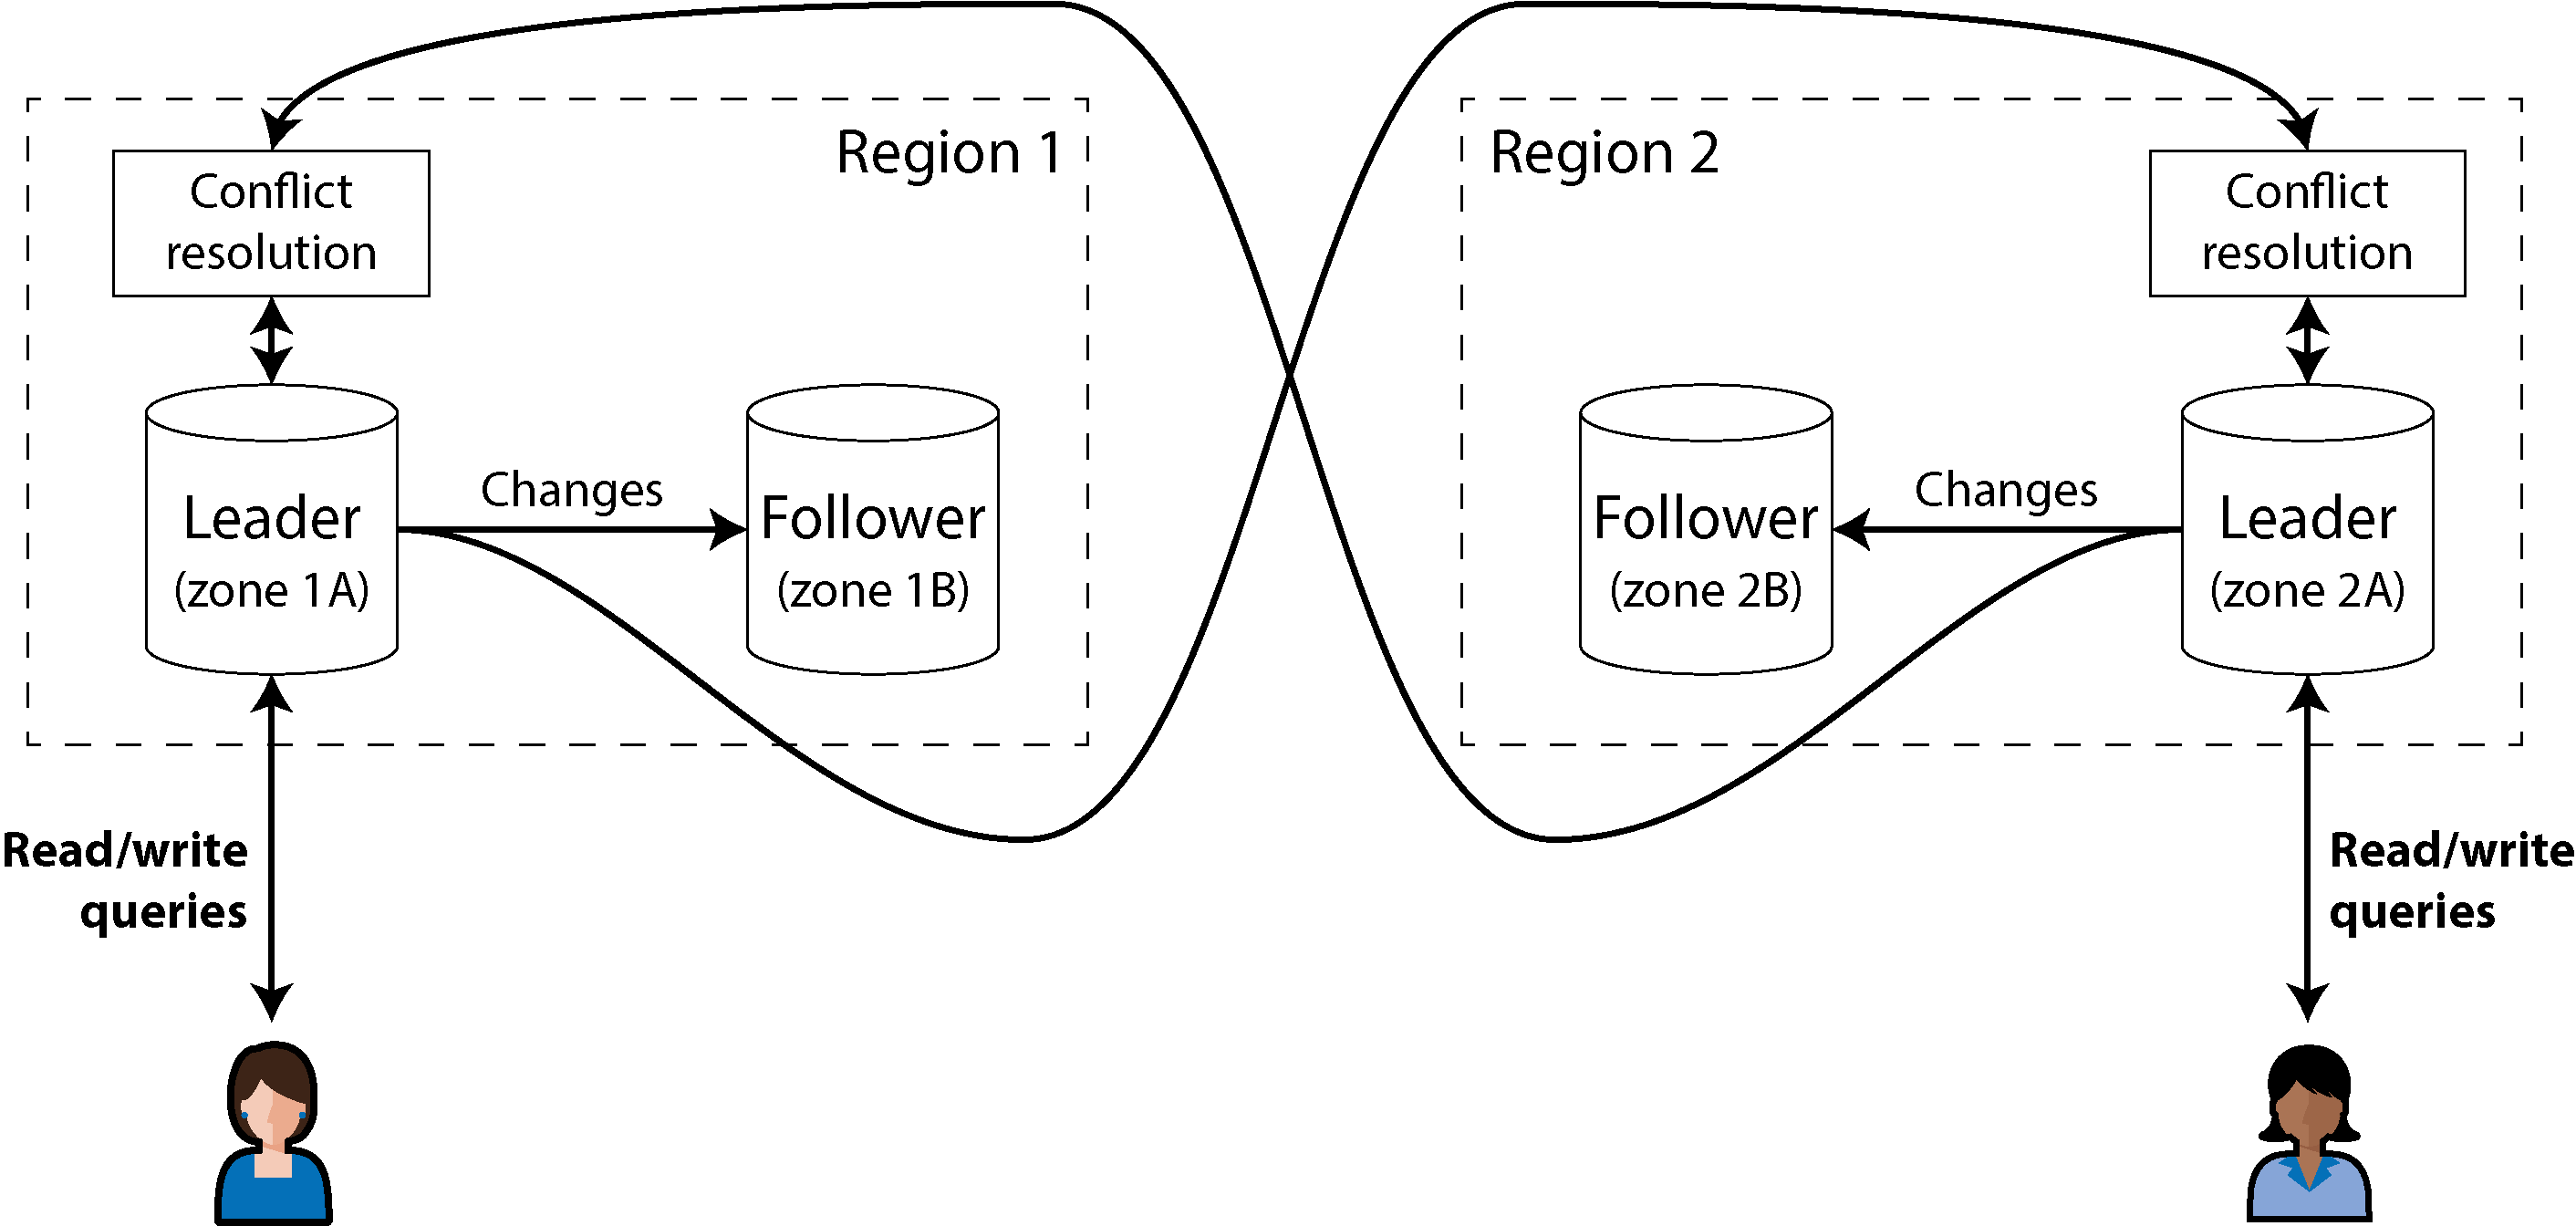

Consistency

A single-leader system can provide strong consistency guarantees, such as serializable transactions, which we will discuss in Chapter 8.

The biggest downside of multi-leader systems is that the consistency they can achieve is much weaker. For example, you can’t guarantee that a bank account won’t go negative or that a username is unique; it’s always possible for different leaders to process writes that are individually fine (paying out some of the money in an account, registering a particular username) but that violate the constraint when taken together with another write on another leader.

This is simply a fundamental limitation of distributed systems [28]. If you need to enforce such constraints, you’re therefore better off with a single-leader system. However, as we will see in “Dealing with Conflicting Writes”, multi-leader systems can still achieve consistency properties that are useful in a wide range of apps that don’t need such constraints.

Multi-leader replication is less common than single-leader replication, but it’s still supported by many databases, including MySQL, Oracle, SQL Server, and YugabyteDB. In some cases it is an external add-on feature—for example, in Redis Enterprise, EDB Postgres Distributed, and pglogical
\

### Sync Engines and Local-First Software

Multi-leader replication is also appropriate if you have an application that needs to continue to work while it is disconnected from the internet. For example, consider the calendar apps on your mobile phone, your laptop, and other devices. You need to be able to see your meetings (make read requests) and enter new meetings (make write requests) at any time, regardless of whether your device currently has an internet connection.

If you make any changes while you are offline, they need to be synced with a server and your other devices when the device is next online.

In this case, every device has a local database replica that acts as a leader (it accepts write requests), and there is an asynchronous multi-leader replication process (sync) between the replicas of your calendar on all your devices. The replication lag may be hours or even days, depending on when you have internet access available.

**Real-time collaboration, offline-first, and local-first apps**

Many modern web apps offer real-time collaboration features, such as Google Docs and Sheets for text documents and spreadsheets, igma for graphics, and Linear for project management.

This again results in a multi-leader architecture: each web browser tab that has opened the shared file is a replica, and any updates that you make to the file are asynchronously replicated to the devices of the other users who have opened the same file. Even if the app does not allow you to continue editing a file while offline, the fact that multiple

### Dealing with Conflicting Writes

The biggest problem with multi-leader replication—both in a geo-distributed server-side database and a local-first sync engine on end-user devices—is that concurrent writes on different leaders can lead to conflicts that need to be resolved.

**Conflict avoidance**

One strategy for dealing with conflicts is to prevent them from occurring in the first place. For example, if the application can ensure that all writes for a particular record go through the same leader, then conflicts cannot occur, even if the database as a whole is multi-leader.

**Last write wins (discarding concurrent writes)**


If conflicts can’t be avoided, the simplest way of resolving them is to attach a timestamp to each write and to always use the value with the most recent (greatest) timestamp.

If the writes coincidentally have the same timestamp, the winner can be chosen by comparing the values (e.g., for strings, taking the one that’s earlier in the alphabet).

This approach is called last write wins (LWW) because the write with the greatest timestamp can be considered the “last” one.

**Manual conflict resolution**

If it's possible, you can ask the user to merge the conflicting writes.

In a database, it would be impractical for a conflict to stop the entire replication process until a human has resolved it.

**Automatic conflict resolution**

For many applications, the best way of handling conflicts is to use an algorithm that automatically merges concurrent writes into a consistent state. Automatic conflict resolution ensures that all replicas *converge* to the same state—that is, all replicas that have processed the same set of writes have the same state, regardless of the order in which the writes arrived. Combining eventual consistency with a convergence guarantee is known as *strong eventual consistency *

**Conflict-free replicated datatypes and operational transformation**

Two families of algorithms are commonly used to implement automatic conflict resolution: conflict-free replicated datatypes (CRDTs) [46] and operational transformation (OT) [47].

Example

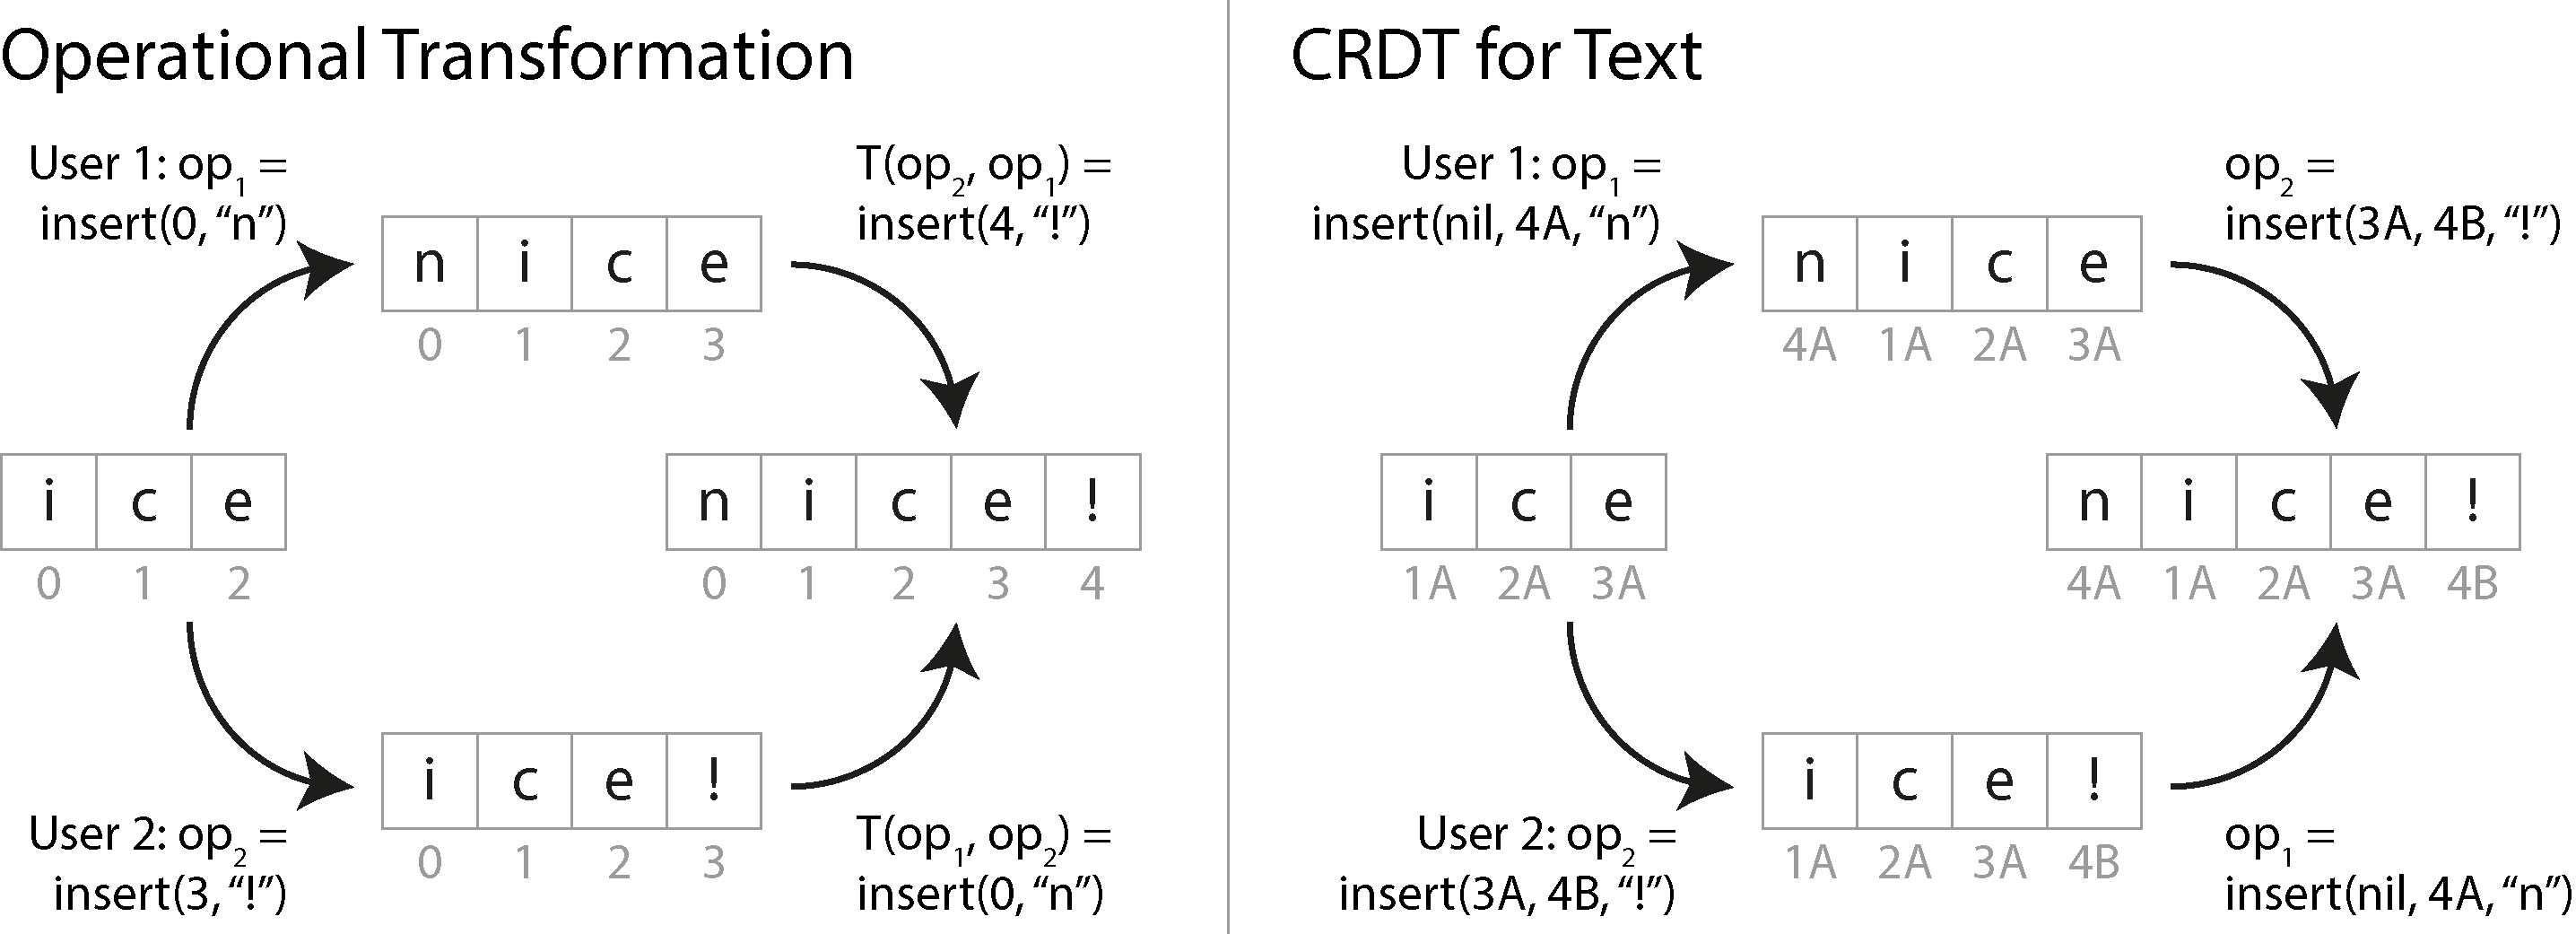

The merged result nice! is achieved differently by the two types of algorithms:

OT

We record the index at which characters are inserted or deleted: n is inserted at index 0 and ! at index 3. Next, the replicas exchange their operations. The insertion of n at index 0 can be applied as is, but if the insertion of ! at index 3 were applied to the state nice, we would get nic!e, which is incorrect. We therefore need to transform the index of each operation to account for concurrent operations that have already been applied. In this case, the insertion of ! is transformed to index 4 to account for the insertion of n at an earlier index.

CRDT

Most CRDTs give each character a unique, immutable ID and use those to determine the positions of insertions/deletions, instead of indexes. For example, in Figure 6-11 we assign the ID 1A to i, the ID 2A to c, etc. When inserting the exclamation mark, we generate an operation containing the ID of the new character (4B) and the ID of the existing character after which we want to insert it (3A). To insert at the beginning of the string, we give nil as the preceding character ID. Concurrent insertions at the same position are ordered by the IDs of the characters. This ensures that replicas converge without performing any transformation.

OT is most often used for real-time collaborative editing of text, such as in Google Docs [32], whereas CRDTs can be found in distributed databases such as Redis Enterprise, Riak, and Azure Cosmos DB [49]. Sync engines for JSON data can be implemented both with CRDTs (e.g., Automerge or Yjs) and with OT (e.g., ShareDB).

## Leaderless Replication

It once again became a fashionable architecture for databases after Amazon used it for its in-house Dynamo system in 2007 [45]. Riak, Cassandra, and ScyllaDB are open source datastores with leaderless replication models inspired by Dynamo, so this kind of database is also known as Dynamo-style.

### Writing to the Database When a Node Is Down

**Catching up on missed writes**

The replication system should ensure that eventually all the data is copied to every replica. After an unavailable node comes back online, how does it catch up on the writes that it missed?

- Read repair

When a client makes a read from several nodes in parallel, it can detect any stale responses. The client sees that replica 3 has a stale value and writes the newer value back to that replica. This approach works well for values that are read often.

- Hinted handoff

If one replica is unavailable, another replica may store writes on its behalf in the form of hints. When the replica that was supposed to receive those writes comes back, the replica storing the hints sends them to the recovered replica and then deletes the hints. This handoff process helps bring replicas up-to-date, even for values that are never read and therefore not handled by read repair.

- Anti-entropy

In addition, a background process periodically looks for differences in the data between replicas and then copies any missing data from one replica to another. Unlike the replication log in leader-based replication, this anti-entropy process does not copy writes in any particular order, and there may be a significant delay before data is copied.

**Using quorums for reading and writing**

If there are n replicas, every write must be confirmed by w nodes to be considered successful, and we must query at least r nodes for each read. (In our example, n = 3, w = 2, r = 2.) As long as w + r > n, we expect to get an up-to-date value when reading, because at least one of the r nodes we’re reading from must be up-to-date. Reads and writes that obey these r and w values are called quorum reads and writes [50]. You can think of r and w as the minimum number of votes required for the read or write to be valid.

In other words r + w must be greater than n so the we know that the two sets of nodes have an intersection.

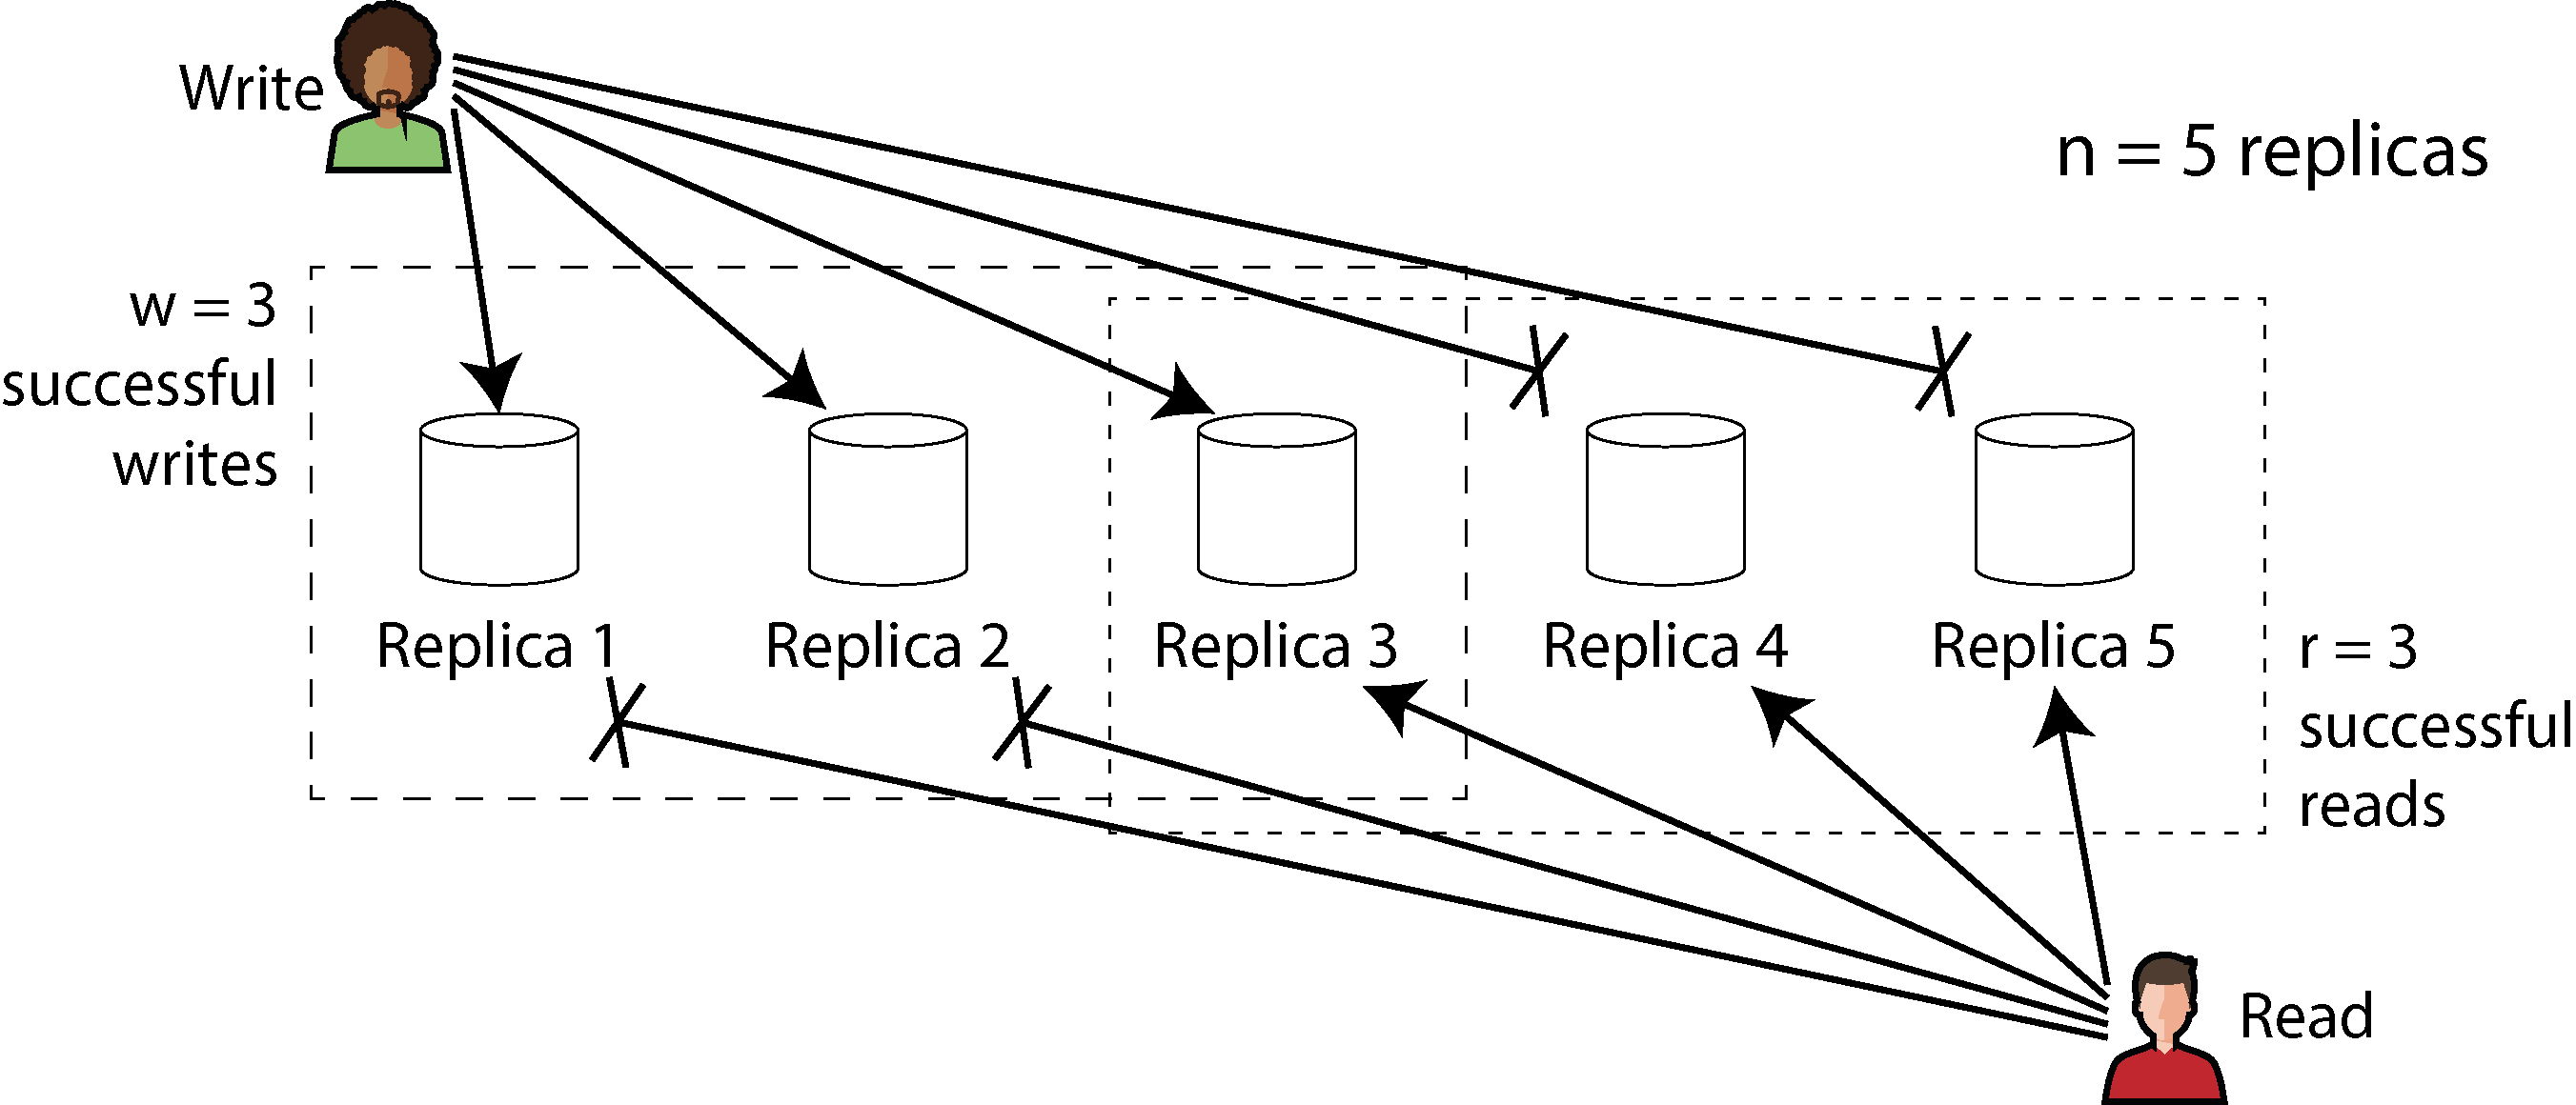

Normally, reads and writes are always sent to all n replicas in parallel. The parameters w and r determine how many nodes we wait for—that is, how many of the n nodes need to report success before we consider the read or write to be successful.

Thus, although quorums appear to guarantee that a read returns the latest written value, in practice it is not so simple. Dynamo-style databases are generally optimized for use cases that can tolerate eventual consistency. The parameters w and r allow you to adjust the probability of stale values being read [54], but it’s wise to not take them as absolute guarantees.

### Single-Leader Versus Leaderless Replication Performance

he system is very sensitive to performance problems on the leader. If the leader is slow to respond (e.g., because of overload or resource contention), the increased response times immediately affect users as well.

A big advantage of a leaderless architecture is that it is more resilient against such issues. Because there is no failover, and requests go to multiple replicas in parallel anyway, one replica becoming slow or unavailable has very little impact on response times; the client simply uses the responses from the other replicas that are faster to respond. Using the fastest responses is called request hedging, and it can significantly reduce tail latency [56].

That said, leaderless systems can have performance problems as well:

- Even though the system doesn’t need to perform failover, one replica does need to detect when another replica is unavailable so that it can store hints about writes that the unavailable replica missed. When the unavailable replica comes back, the handoff process needs to send it those hints. This puts additional load on the replicas at a time when the system is already under strain [55].

- The more replicas you have, the bigger the size of your quorums and the more responses you have to wait for before a request can complete. Even if you wait only for the fastest r or w replicas to respond, and even if you make the requests in parallel, a bigger r or w raises the chances of you hitting a slow replica, increasing the overall response time (see “Use of Response Time Metrics”). In practice, quorums are seldom more than four out of seven nodes or five out of nine nodes.

- A large-scale network interruption that disconnects a client from a large number of replicas can make it impossible to form a quorum. Some leaderless databases offer a configuration option that allows any reachable replica to accept writes, even if it’s not one of the usual replicas for that key (Riak and Dynamo call this a sloppy quorum [45]; Cassandra and ScyllaDB call it consistency level ANY). There is no guarantee that subsequent reads will see the written value, but depending on the application, it may still be better than having the write fail.

### Multi-Region Operation

We previously discussed cross-region replication as a use case for multi-leader replication (see “Multi-Leader Replication”). Leaderless replication is also suitable for multi-region operation, since it is designed to tolerate conflicting concurrent writes, network interruptions, and latency spikes.

In Cassandra and ScyllaDB, a client that wants to perform a multi-region write first chooses a node in its local region, called the *coordinator node*, and sends its write to that node. The coordinator node forwards the write to all replicas in its own region and to one replica in every other region, which then forwards it to the other replicas in that region. This optimization avoids making the cross-region request multiple times.

Riak keeps all communication between clients and database nodes local to one region, so n describes the number of replicas within one region. Cross-region replication between database clusters happens asynchronously in the background, in a style that is similar to multi-leader replication.


### Detecting Concurrent Writes

To become eventually consistent, the replicas should converge toward the same value. For this, we can use any of the conflict resolution mechanisms we previously discussed in “Dealing with Conflicting Writes”, such as LWW (used by Cassandra and ScyllaDB), manual resolution, or CRDTs (used by Riak).

# 7 - Sharding

# 8 - Transactions

A transaction is a way for an application to group several reads and writes together into a logical unit. Conceptually, all the reads and writes in a transaction are executed as one operation; either the entire transaction succeeds, resulting in a commit, or it fails, resulting in an abort or rollback, and the application just needs to try again.

Using transactions allows the application to ignore certain potential error scenarios and concurrency issues, because the database takes care of them instead (we call these safety guarantees).

Sometimes there are advantages to weakening transactional guarantees or abandoning them entirely (e.g., to achieve better performance or higher availability).

We’ll take a close look at that topic in this chapter, discussing various kinds of race conditions that can occur and how databases implement isolation levels such as **read-committed, snapshot isolation, and serializability** We will also examine the **two-phase commit protocol** and the challenge of achieving **atomicity in a distributed transaction**.

| Isolation Level        | Dirty Reads  | Read Skew    | Phantom Reads | Lost Updates | Write Skew   |
|-----------------------|-------------|--------------|---------------|--------------|--------------|
| Read uncommitted      | ✗ Possible  | ✗ Possible   | ✗ Possible    | ✗ Possible   | ✗ Possible   |
| Read committed        | ✓ Prevented | ✗ Possible   | ✗ Possible    | ✗ Possible   | ✗ Possible   |
| Snapshot isolation    | ✓ Prevented | ✓ Prevented  | ✓ Prevented   | ? Depends    | ✗ Possible   |
| Serializable          | ✓ Prevented | ✓ Prevented  | ✓ Prevented   | ✓ Prevented  | ✓ Prevented  |

## What exactly is a transaction?

The general idea has remained virtually the same for 50 years: the transaction support in MySQL, PostgreSQL, Oracle, SQL Server, etc. is uncannily similar to that of System R.

The hype around NoSQL distributed databases led to a popular belief that transactions were fundamentally unscalable and that any large-scale system would have to abandon them in order to maintain good performance and high availability.

Recently, So-called “NewSQL” databases such as CockroachDB [5], TiDB [6], Spanner [7], FoundationDB [8], and YugabyteDB have shown that transactional systems can scale to large data volumes and high throughput.

### ACID

The safety guarantees provided by transactions are often described by the well-known acronym ACID, which stands for atomicity, consistency, isolation, and durability.

Systems that do not meet the ACID criteria are sometimes called BASE, which stands for basically available, soft state, and eventual consistency [11]. This is even more vague than the definition of ACID. It seems that the only sensible definition of BASE is “not ACID” (i.e., it can mean almost anything you want)

Atomicity

ACID atomicity describes what happens if a client wants to make several writes, but a fault occurs after some of the writes have been processed—for example, a process crashes, a network connection is interrupted, a disk becomes full, or an integrity constraint is violated. If the writes are grouped together into an atomic transaction, and the transaction cannot be completed (committed) because of a fault, then the transaction is aborted and the database must discard or undo any writes it has made so far in that transaction.

Atomicity simplifies this problem: if a transaction was aborted, the application can be sure that it didn’t change anything, so it can safely be retried.

Consistency

The idea of ACID consistency is that you have certain statements about your data (**invariants**) that must always be true—for example, in an accounting system, credits and debits across all accounts must always be balanced. If a transaction starts with a database that is valid according to these invariants, and any writes during the transaction preserve the validity, then you can be sure that the invariants are always satisfied. (An invariant may be temporarily violated during transaction execution, but it should be satisfied again at transaction commit.)

If you want the database to enforce your invariants, you need to declare them as constraints as part of the schema. For example, foreign-key constraints, uniqueness constraints.

Isolation

Most databases are accessed by several clients at the same time. That’s no problem if they are reading and writing different parts of the database, but if they are accessing the same database records, you can run into concurrency problems (race conditions).

Isolation in the sense of ACID means that concurrently executing transactions are isolated from each other. For example, if one transaction makes several writes, then another transaction should see either all or none of those writes, but not a subset.

In practice, many databases use forms of isolation that are weaker than serializability—that is, they allow concurrent transactions to interfere with each other in limited ways.

Durability

The purpose of a database system is to provide a safe place where data can be stored without fear of losing it. Durability is the promise that after a transaction has committed successfully, any data it has written will not be forgotten, even if there is a hardware fault or the database crashes.


In a single-node database, durability typically means that the data has been written to nonvolatile storage such as a hard drive or SSD

However, perfect durability does not exist; if all your hard disks and all your backups are destroyed at the same time, there’s obviously nothing your database can do to save you.

### Signle-Object and Multi-Object Operations

Single-Objects

Atomicity can be implemented using a log for crash recovery (see “Making B-trees reliable”), and isolation can be implemented using a lock on each object (allowing only one thread to access an object at any one time).

Multi-Objects

Example: In a relational data model, a row in one table often has a foreign-key reference to a row in another table. Similarly, in a graph-like data model, a vertex has edges to other vertices. Multi-object transactions allow you to ensure that these references remain valid;

On any particular connection, everything between a `BEGIN TRANSACTION` and a `COMMIT` statement is considered to be part of the same transaction.

## Weak Isolation Levels

If two transactions don’t access the same data, or if both are read-only, they can safely be run in parallel, because neither depends on the other. Concurrency issues (race conditions) come into play only when one transaction reads data that is concurrently modified by another transaction, or when the two transactions try to modify the same data.

In this section we will look at several weak (nonserializable) isolation levels that are used in practice and discuss in detail the kinds of race conditions that can and cannot occur with each one, so you can decide what level is appropriate to your application.

### Read Committed

The most basic level of transaction isolation is read committed, and it makes two guarantees:
 - When reading from the database, you will see only data that has been committed (no dirty reads).
- When writing to the database, you will overwrite only data that has been committed (no dirty writes).

No dirty reads

This means that any writes by a transaction become visible to others only when that transaction commits, and till that others still see the old value.

Preventing dirty reads is useful for a few reasons:

- Seeing the database in a partially updated state is confusing to users and may cause other transactions to make incorrect decisions.

- Any transaction that read uncommitted data would also need to be aborted, leading to a problem called cascading aborts.

No dirty writes

What happens if two transactions concurrently try to update the same row in a database? we normally assume that the later write overwrites the earlier one.

what happens if the earlier write is part of a transaction that has not yet committed, so the later write overwrites an uncommitted value? This is called a dirty write.

Transactions running at the read-committed isolation level must prevent dirty writes, usually by delaying the second write until the first write’s transaction has committed or aborted.

Read-committed isolation does not prevent the race condition between two counter increments. In this case, the second write happens after the first transaction has committed, so it’s not a dirty write. It’s still incorrect, but for a different reason; it's called "Lost Updates”.

Implementation

Read-committed is a very popular isolation level. It is the default setting in Oracle Database, PostgreSQL, SQL Server, and many other databases.

**Multiversion concurrency control**

Instead of using locks in implementation, a more commonly used approach to preventing dirty reads is that for every row that is written, the database remembers both the old committed value and the new value set by the transaction that currently holds the write lock. While the transaction is ongoing, any other transactions that read the row are simply given the old value. Only when the new value is committed do transactions switch over to reading the new value.

### Snapshot Isolation and Repeatable Read

This isolation level tries to fix reading different values based on the timing. This anomaly is called read skew, and it is an example of a nonrepeatable read.

Examples

Backups
- Taking a backup requires making a copy of the entire database, which may take hours for a large database. During the time that the backup process is running, writes will continue to be made to the database. Thus, you could end up with some parts of the backup containing an older version of the data and other parts containing a newer version.

Analytical queries and integrity checks
- These long-running queries are likely to return nonsensical results if they observe parts of the database at different points in time

Snapshot isolation [38] is the most common solution to this problem. The idea is that each transaction reads from a consistent snapshot of the database—that is, it sees all the data that was committed in the database at the start of that. Even if the data is subsequently changed by another transaction, each transaction sees only the old data from that particular point in time.

a key principle of snapshot isolation is readers never block writers, and writers never block readers.

Naming confusion

MVCC is a commonly used implementation technique for databases, and often it is used to implement snapshot isolation. However, different databases sometimes use different terms to refer to the same thing—for example, snapshot isolation is called “repeatable read” in PostgreSQL and “serializable” in Oracle.

This isolation level has been formally defined in the research literature [39, 40], but most implementations don’t satisfy that formal definition. As a result, nobody really knows what repeatable read isolation means.

By never updating values in place but instead inserting a new version every time a value is changed, the database can provide a consistent snapshot while incurring only a small overhead.

### Preventing Lost Updates

The lost update problem can occur if an application reads a value from the database, modifies it, and writes back the modified value (the read-modify-write cycle mentioned earlier). If two transactions do this concurrently, one of the modifications can be lost, because the second write does not include the first modification.

Example: two concurrent counter increments.


Solution 1: Atomic Operations

Atomic operations are usually implemented by exclusively locking the object on the object when it is read so that no other transaction can read it until the update has been applied.

Solution 2: Explicing Locking

Another option for preventing lost updates, if the database’s built-in atomic operations don’t provide the necessary functionality, is for the application to explicitly lock objects that are going to be updated. Then the application can perform a read-modify-write cycle, and if any other transaction tries to concurrently update or lock the same object, it is forced to wait until the first read-modify-write cycle has completed.

Solution 3: Automatically detecting lost updates

An alternative is to allow them to execute in parallel and, if the transaction manager detects a lost update, abort the transaction in question and force it to retry its read-modify-write cycle.

Solution 4: Conditional writes (compare-and-set)

In databases that don’t provide transactions, you sometimes find a conditional write operation that can prevent lost updates by allowing an update to happen only if the value has not changed since you last read it (previously mentioned in “Single-object writes”). If the current value does not match what you previously read, the update has no effect, and the read-modify-write cycle must be retried.

```sql
-- This may or may not be safe, depending on the database implementation
UPDATE wiki_pages SET content = 'new content'
  WHERE id = 1234 AND content = 'old content';
```

Conflict resolution and replication

A common approach in such replicated databases is to allow concurrent writes to create several conflicting versions of a value (also known as siblings) and to use application code or special data structures to resolve and merge these versions after the fact.

Merging conflicting values can prevent lost updates if the updates are commutative (i.e., you can apply them in a different order on different replicas and still get the same result). For example, incrementing a counter and adding an element to a set are commutative operations. That is the idea behind CRDTs.

### Write Skew and Phantoms

You can think of write skew as a generalization of the lost-update problem. Write skew can occur if two transactions read the same objects and then update some of those objects (different transactions may update different objects). In the special case of different transactions updating the same object, you get a dirty write or lost update anomaly (depending on the timing).

The automatic detection of lost updates that you find in some implementations of snapshot isolation unfortunately doesn’t help. Automatically preventing write skew requires true serializable isolation.

If you can’t use a serializable isolation level, the second-best option in this case is probably to explicitly lock the rows that the transaction depends on. In the doctors example, you could write something like the following:
BEGIN TRANSACTION;
```sql
SELECT * FROM doctors
  WHERE on_call = true
  AND shift_id = 1234 FOR UPDATE;

UPDATE doctors
  SET on_call = false
  WHERE name = 'Aaliyah'
  AND shift_id = 1234;

COMMIT;
```
As before, FOR UPDATE tells the database to lock all rows returned by this query.

 More examples of write skew

Meeting room booking system
Say you want to enforce that there cannot be two bookings for the same meeting room at the same time [57]. When someone wants to make a booking, you first check for any conflicting bookings (i.e., bookings for the same room with an overlapping time range), and if none are found, you create the meeting (see Example 8-2).

Example 8-2. A meeting room booking system that attempts to avoid double-booking (not safe under snapshot isolation)

```sql
BEGIN TRANSACTION;

-- Check for any existing bookings that overlap with the period of noon-1pm
SELECT COUNT(*) FROM bookings
  WHERE room_id = 123 AND
    end_time > '2025-01-01 12:00' AND start_time < '2025-01-01 13:00';

-- If the previous query returned zero:
INSERT INTO bookings
  (room_id, start_time, end_time, user_id)
  VALUES (123, '2025-01-01 12:00', '2025-01-01 13:00', 666);

COMMIT;
```
Unfortunately, snapshot isolation does not prevent another user from concurrently inserting a conflicting meeting. To guarantee that you won’t get scheduling conflicts, you once again need serializable isolation.

Phantoms

This example check for the absence of rows matching a search condition, and the write adds a row matching the same condition. If the query in step 1 doesn’t return any rows, SELECT FOR UPDATE can’t attach locks to anything [58].
This effect, where a write in one transaction changes the result of a search query in another transaction, is called a phantom [4]. Snapshot isolation avoids phantoms in read-only queries, but in read/write transactions like the examples we discussed, phantoms can lead to particularly tricky cases of write skew. The SQL generated by ORMs is also prone to write skew.

## Serializability

Some race conditions are prevented by the read-committed and snapshot isolation levels, but others are not. We encountered some particularly tricky examples with write skew and phantoms. It’s a sad situation:
- Isolation levels are hard to understand and inconsistently implemented in different databases
- It can be difficult to tell by looking at the application code whether it is safe to run at a particular isolation level—especially in a large application
- here are no good tools to help us detect race conditions. In principle, static analysis may help [35], but research techniques have not yet found their way into practical use. Testing for concurrency issues is hard, because they are usually nondeterministic—problems occur only if you get unlucky with the timing.

All along, the answer from researchers has been simple: use serializable isolation!


Most databases that provide serializability today use one of three techniques, which we will explore in the rest of this chapter:
- Literally executing transactions in a serial order
- Two-phase locking which for several decades was the only viable option
- Optimistic concurrency control techniques such as serializable snapshot isolation

### Actual Serial Execution

Execute only one transaction at a time, in serial order, on a single thread.

it was only in the 2000s that database designers decided that a single-threaded loop for executing transactions was feasible:

- RAM became cheap enough that for many use cases it is now feasible to keep the entire active dataset in memory
- Database designers realized that OLTP transactions are usually short and make only a small number of reads and writes (because it takes only one slow transaction to stall all transaction processing.)

A system designed for single-threaded execution can sometimes perform better than a system that supports concurrency, because it can avoid the coordination overhead of locking. However, its throughput is limited to that of a single CPU core.

Stored procedure: submit the entire transaction code to the database ahead of time, as a stored procedure.

With stored procedures and in-memory data, executing all transactions on a single thread becomes feasible. When stored procedures don’t need to wait for I/O and avoid the overhead of other concurrency control mechanisms, they can achieve quite good throughput on a single thread.

### Two-Phase Locking

For around 30 years, only one algorithm was widely used for serializability in databases: two-phase locking (2PL), sometimes called strong strict two-phase locking (SS2PL) to distinguish it from other variants of 2PL.

The blocking of readers and writers is implemented by having a lock on each object in the database. The lock can either be in *shared mode* or in *exclusive mode* (also known as a *multi-reader single-writer lock*). It is used as follows:
If a transaction wants to read an object, it must first acquire the lock in shared mode. Several transactions are allowed to hold the lock in shared mode simultaneously, but if another transaction already has an exclusive lock on the object, these transactions must wait.

- If a transaction wants to write to an object, it must first acquire the lock in exclusive mode. No other transaction may hold the lock at the same time (either in shared or in exclusive mode), so if there is any existing lock on the object, the transaction must wait.
- If a transaction first reads and then writes an object, it may upgrade its shared lock to an exclusive lock. The upgrade works the same way as getting an exclusive lock directly.
- After a transaction has acquired the lock, it must continue to hold the lock until the end of the transaction (commit or abort). This is where the name “two-phase” comes from: the first phase (the growing phase, while the transaction is executing) is when the locks are acquired, and the second phase (the shrinking phase, at the end of the transaction) is when all the locks are released. The two phases must not overlap; once a lock is released, no new locks may be acquired in a transaction.

Since so many locks are in use, it can happen quite easily that transaction A is stuck waiting for transaction B to release its lock, and vice versa. This situation is called deadlock. The database automatically detects deadlocks between transactions and aborts one of them so that the others can make progress. The aborted transaction needs to be retried by the application.

Performance of 2PL

The big downside of 2PL, and the reason it hasn’t been the default for most systems since the 1970s, is performance. Transaction throughput and response times of queries are significantly worse under 2PL than under weak isolation.

This is partly due to the overhead of acquiring and releasing all those locks, but more importantly due to reduced concurrency.

### Serializable Snapshot Isolation

Are serializable isolation and good performance fundamentally at odds with each other?

It seems not: an algorithm called serializable snapshot isolation (SSI) provides full serializability with only a small performance penalty compared to snapshot isolation. SSI is comparatively new; it was first described in 2008

Today, SSI and similar algorithms are used in single-node databases (the serializable isolation level in PostgreSQL [56], SQL Server’s In-Memory OLTP/Hekaton [68], and HyPer [69]), distributed databases (CockroachDB [5] and FoundationDB [8]), and embedded storage engines such as BadgerDB.

Pessimistic versus optimistic concurrency control

2PL is a pessimistic concurrency control mechanism: it is based on the principle that if anything might possibly go wrong (as indicated by a lock held by another transaction), it’s better to wait until the situation is safe again before doing anything.

By contrast, serializable snapshot isolation is an optimistic concurrency control technique. Optimistic in this context means that instead of blocking if something potentially dangerous happens, transactions continue anyway, in the hope that everything will turn out all right. When a transaction wants to commit, the database checks whether anything bad happened (i.e., whether isolation was violated); if so, the transaction is aborted and has to be retried. Only transactions that executed serializably are allowed to commit.

On top of snapshot isolation, SSI adds an algorithm for detecting serialization conflicts among reads and writes and determining which transactions to abort.

Performance of serializable snapshot isolation

Compared to 2PL, the big advantage of serializable snapshot isolation is that one transaction doesn’t need to block waiting for locks held by another transaction. As with snapshot isolation, writers don’t block readers, and vice versa. This design principle makes query latency much more predictable and less variable. In particular, read-only queries can run on a consistent snapshot without requiring any locks, which is very appealing for read-heavy workloads.

Compared to nonserializable snapshot isolation, the need to check for serializability violations introduces some performance overheads. How significant these overheads are is a matter of debate: some believe that serializability checking is not worth it [72], while others believe that the performance of serializability is now so good that there is no need to use the weaker snapshot isolation anymore

## Distributed Transactions

The algorithms for concurrency control in distributed transactions are broadly similar to those for single-node concurrency control. We discussed serial execution on sharded databases previously; 2PL works in a distributed setting, and for SSI there are distributed serializability checkers.

In a distributed transaction, determining whether a transaction has committed is not so straightforward.

When a transaction wants to commit, it is not sufficient to simply send a commit request to all the nodes and independently commit the transaction on each one. It could easily happen that the commit succeeds on some nodes and fails on others.

### Two-Phase Commit

Two-phase commit is an algorithm for achieving atomic transaction commit across multiple nodes. It is a classic algorithm in distributed databases [13, 73, 74]. 2PC is used internally in some databases

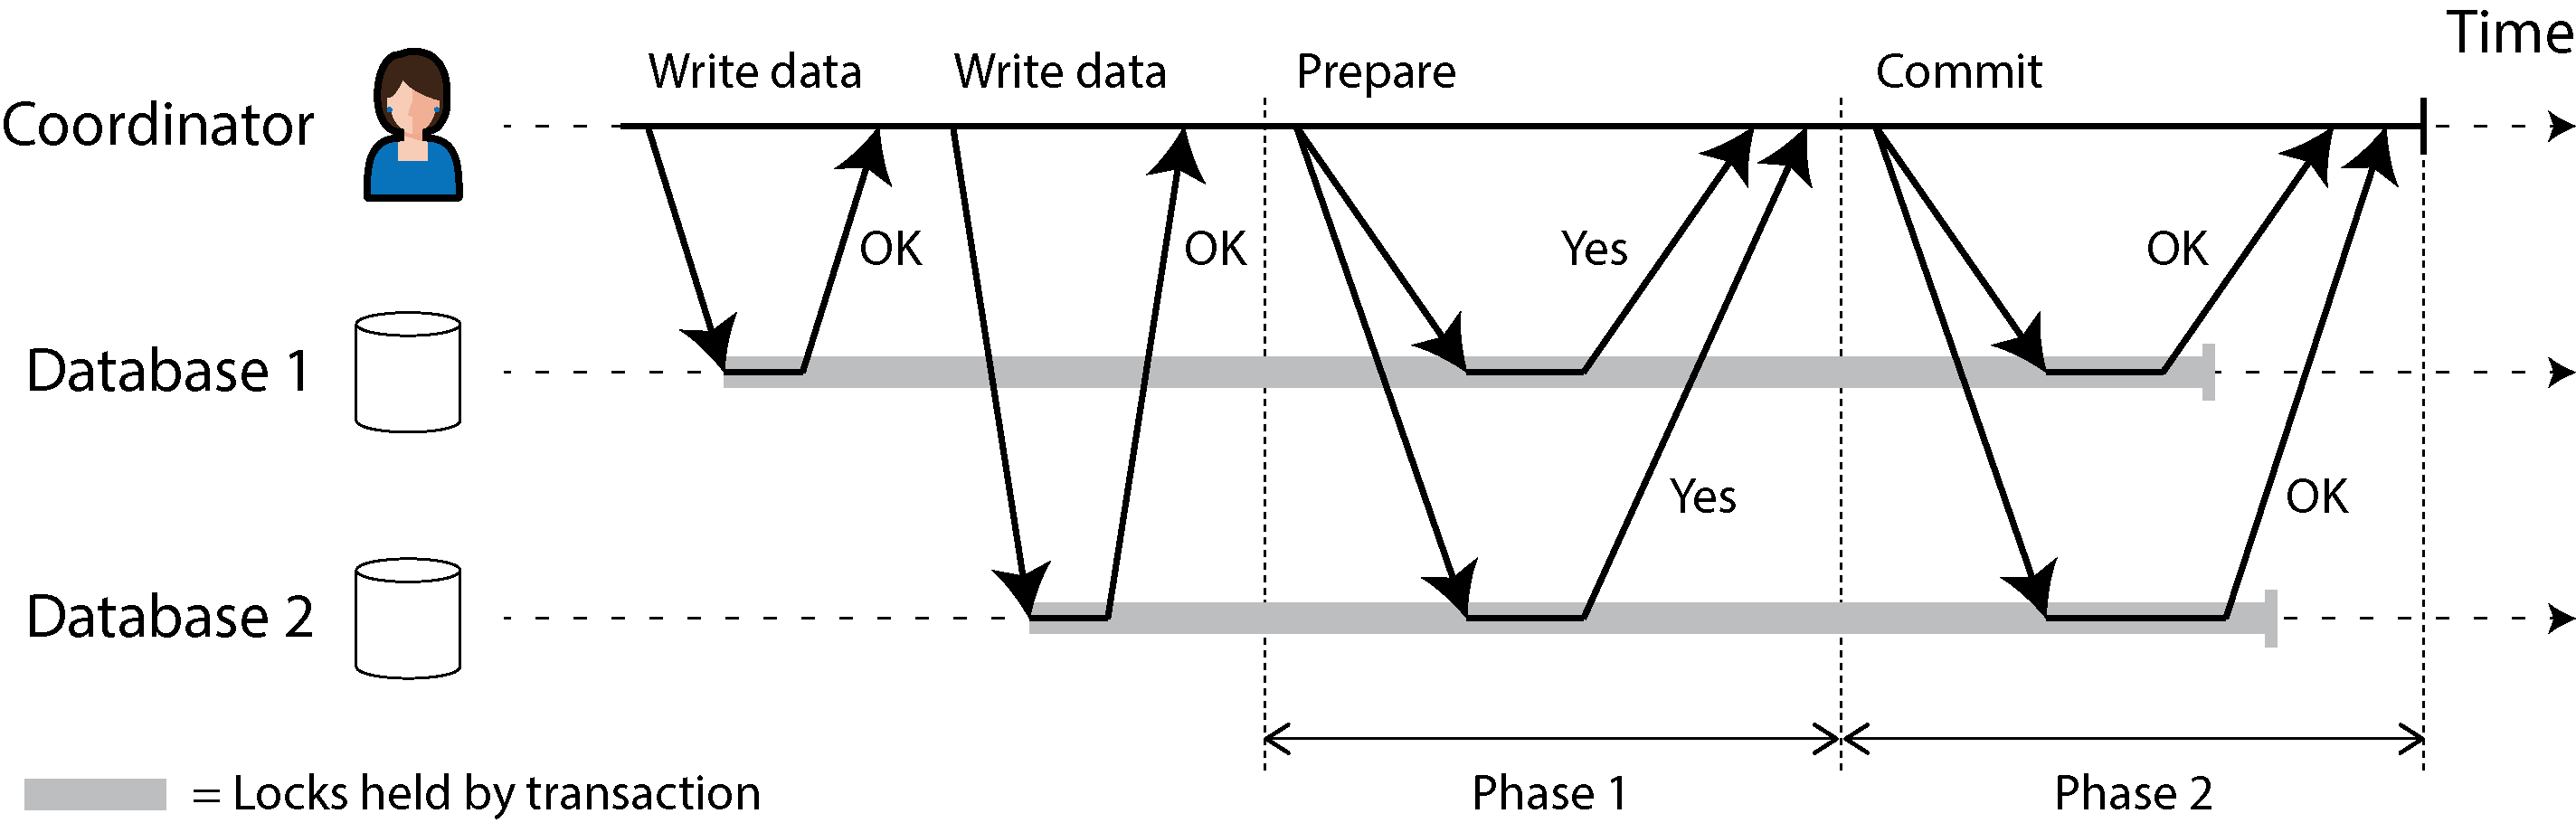

When a participant receives the prepare request, it makes sure that it can definitely commit the transaction under all circumstances. This includes writing all transaction data to disk (a crash, a power failure, or running out of disk space is not an acceptable excuse for refusing to commit later) and checking for any conflicts or constraint violations.

Also, the coordinator must write that decision to its transaction log on disk so that it knows which way it decided in case it subsequently crashes. This is called the commit point.

Those two phases ensure the atomicity of 2PC.

Coordinator failure

We have discussed what happens if one of the participants or the network fails during 2PC: if any of the prepare requests fails or times out, the coordinator aborts the transaction; if any of the commit or abort requests fails, the coordinator retries them indefinitely.

If coordinator fails, a solution in practice is to replace the single-node coordinator with a fault-tolerant consensus protocol.

### Distributed Transactions Across Different Systems

Two quite different types of distributed transactions are
- Database-internal distributed transactions

Some distributed databases (i.e., databases that use replication and sharding in their standard configuration) support internal transactions among the nodes of that database.

Because their distributed transactions don’t need to interface with any other technologies, they avoid the lowest-common-denominator trap—the designers of these systems are free to use better protocols that are more reliable and faster.

- Heterogeneous distributed transactions

In a heterogeneous transaction, the participants are two or more technologies—for example, two databases from different vendors, or even non-database systems such as message brokers.

XA transactions

X/Open XA (short for eXtended Architecture) is a standard for implementing 2PC across heterogeneous technologies [75]. It was introduced in 1991 and has been widely implemented. XA is supported by many traditional relational databases (including PostgreSQL, MySQL, Db2, SQL Server, and Oracle) and message brokers (including ActiveMQ, HornetQ, MSMQ, and IBM MQ).

Howevever there are problems somewhat inherent in performing transactions across heterogeneous technologies. Keeping several heterogeneous data systems consistent with one another is still a real and important problem, so we need to find a different solution. This can be done, as we will see in the next section and in Chapter 12.

### Exactly-Once Message Processing

An important use case for distributed transactions is to ensure that an operation takes effect exactly once, even if a crash occurs while it is being processed and the processing needs to be retried. If you can atomically commit a transaction across a message broker and a database, you can acknowledge the message to the broker if and only if it was successfully processed and the database writes resulting from the process were committed.
However, you don’t actually need distributed transactions to achieve exactly-once semantics. An alternative approach requires only transactions within the database.

Atomicity across database and message broker is not necessary for this use case. Recording the message ID in the database makes the message processing *idempotent*, so that message processing can be safely retried without duplicating its side effects. A similar approach is used in stream processing frameworks such as Kafka Streams to achieve exactly-once semantics, as we shall see in Chapter 12.

## Summary of anomalies

Here’s a brief recap:

**Dirty reads**

One client reads another client’s writes before they have been committed. The read-committed isolation level and stronger levels prevent dirty reads.

**Dirty writes**

One client overwrites data that another client has written but not yet committed. Almost all transaction implementations prevent dirty writes (hence, it’s not included in the table).

**Read skew**

A client sees different parts of the database at different points in time. Some cases of read skew are also known as nonrepeatable reads. This issue is most commonly prevented with snapshot isolation, which allows a transaction to read from a consistent snapshot corresponding to one particular point in time. Snapshot isolation is usually implemented with multiversion concurrency control.

**Phantom reads**

A transaction reads objects that match a search condition. Another client makes a write that affects the results of that search. Snapshot isolation prevents straightforward phantom reads, but phantoms in the context of write skew require special treatment, such as index-range locks.

**Lost updates**

Two clients concurrently perform a read-modify-write cycle. One overwrites the other’s write without incorporating its changes, so data is lost. Some implementations of snapshot isolation prevent this anomaly automatically, while others require a manual lock (SELECT FOR UPDATE).

**Write skew**

A transaction reads something, makes a decision based on the value it saw, and writes the decision to the database. However, by the time the write is made, the premise of the decision is no longer true. Only serializable isolation prevents this anomaly.

Weak isolation levels protect against some of those anomalies but leave you, the application developer, to handle others manually (e.g., using explicit locking).

# 9 -  The Trouble with Distributed Systems

## Faults and Partial Failures

In a distributed system, there may well be some parts of the system that are broken in an unpredictable way, even though other parts of the system are working fine. This is known as a partial failure. The difficulty is that partial failures are nondeterministic: if you try to do anything involving multiple nodes and the network, it may sometimes work and sometimes unpredictably fail. As we shall see, you may not even know whether something succeeded!

## Unreliable Networks

The internet and most internal networks in datacenters (often Ethernet) are asynchronous packet networks. In this kind of network, one node can send a message (a packet) to another node, but the network gives no guarantees as to when it will arrive or whether it will arrive at all. If you send a request and expect a response, many things could go wrong.

The usual way of handling this issue is a timeout: after some time, you give up waiting and assume that the response is not going to arrive. However, when a timeout occurs, you still don’t know whether the remote node got your request (and if the request is still queued somewhere, it may still be delivered to the recipient, even if you’ve given up on that possibility).

Timeouts and Unbounded Delays

If a timeout is the only sure way of detecting a fault, then how long should the timeout be? There is unfortunately no simple answer.


A long timeout means a long wait until a node is declared dead (and during this time, users may have to wait or see error messages). A short timeout detects faults faster but carries a higher risk of incorrectly declaring a node dead when in fact it has only suffered a temporary slowdown

Synchronous Versus Asynchronous Networks

When you make a call over the telephone network, it establishes a *circuit*: a fixed, guaranteed amount of bandwidth is allocated for the call, along the entire route between the two callers. This circuit remains in place until the call ends [34]. For example, an ISDN network runs at a fixed rate of 4,000 frames per second. When a call is established, it is allocated 16 bits of space within each frame (in each direction). Thus, for the duration of the call, each side is guaranteed to be able to send exactly 16 bits of audio data every 250 microseconds [35].


This kind of network is synchronous: even as data passes through several routers, it does not suffer from queueing, because the 16 bits of space for the call have already been reserved in the next hop of the network. And because there is no queueing, the maximum end-to-end latency of the network is fixed. We call this a *bounded delay.*

Why do datacenter networks and the internet use packet switching? The answer is that they are optimized for bursty traffic. A circuit is good for an audio or video call, which needs to transfer a fairly constant number of bits per second for the duration of the call. On the other hand, requesting a web page, sending an email, or transferring a file doesn’t have any particular bandwidth requirement—we just want it to complete as quickly as possible.

This approach has the downside of queueing, but the advantage is that it maximizes utilization of the wire. The wire has a fixed cost, so if you utilize it better, each byte you send over it is cheaper.


Currently deployed technology does not allow us to make any guarantees about delays or reliability of the network; we have to assume that network congestion, queueing, and unbounded delays will happen. Consequently, there’s no “correct” value for timeouts—they need to be determined experimentally.


## Unreliable Clocks

It is possible to synchronize clocks to some degree; the most commonly used mechanism is the Network Time Protocol (NTP), which allows the computer clock to be adjusted according to the time reported by a group of servers [39]. The servers in turn get their time from a more accurate time source, such as a GPS receiver.

### Monotonic Versus Time-of-Day Clocks

Modern computers have at least two kinds of clocks: a time-of-day clock and a monotonic clock. Although both measure time, it is important to distinguish between them, since they serve different purposes.

Time-of-day clocks

A time-of-day clock does what you intuitively expect of a clock: it returns the current date and time according to a calendar (also known as wall-clock time). For example, clock_gettime(CLOCK_REALTIME) on Linux and System.currentTimeMillis in Java return the number of seconds (or milliseconds) since the epoch, defined as midnight UTC on January 1, 1970, according to the Gregorian calendar, not counting leap seconds.

time-of-day clocks also have various oddities, as described in the next section. In particular, if the local clock is too far ahead of the NTP server, it may be forcibly reset and appear to jump back to a previous point in time. These jumps, as well as similar jumps caused by leap seconds, make time-of-day clocks unsuitable for measuring elapsed time.

Monotonic clocks

A monotonic clock is suitable for measuring a duration (time interval), such as a timeout or a service’s response time; clock_gettime(CLOCK_MONOTONIC) or clock_gettime(CLOCK_BOOTTIME) on Linux [42] and System.nanoTime in Java, for example, measure time using a monotonic clock. The name comes from the fact that this type of clock is guaranteed to always move forward (whereas a time-of-day clock may jump back in time).

The absolute value of the clock is meaningless; it might be the number of nanoseconds since the computer was booted up, or something similarly arbitrary. In particular, it makes no sense to compare monotonic clock values from two computers, because they don’t mean the same thing.

In a distributed system, using a monotonic clock for measuring elapsed time (e.g., timeouts) is usually fine, because it doesn’t assume any synchronization between different nodes’ clocks and is not sensitive to slight inaccuracies of measurement.

### Timestamps for ordering events

Let’s consider one particular situation in which it is tempting, but dangerous, to rely on clocks: ordering of events across multiple nodes [64]. For example, if two clients write to a distributed database, who got there first? Which write is the more recent one?

For example if we use Last Write Wins (LWW) rule for write conflict resolution, we might end up and old value overwriting a recent value, because of the drift in timestamps.

Thus, even though it is tempting to resolve conflicts by keeping the most “recent” value and discarding others, it is important to be aware that the definition of “recent” depends on a local time-of-day clock, which may well be incorrect.

Logical Locks

So-called logical clocks [66], which are based on incrementing counters rather than an oscillating quartz crystal, are a safer alternative for ordering events (see “Detecting Concurrent Writes”). Logical clocks do not measure the time of day or the number of seconds elapsed, only the relative ordering of events (whether one event happened before or after another). In contrast, time-of-day and monotonic clocks, which measure actual elapsed time, are known as physical clocks.

## Knowledge, Truth, and Lies

### The Majority Rules

 A distributed system cannot exclusively rely on a single node, because a node may fail at any time, potentially leaving the system stuck and unable to recover. Instead, many distributed algorithms rely on a quorum (i.e., voting among the nodes; see “Using quorums for reading and writing”): decisions require a minimum number of votes from several nodes in order to reduce the dependence on any one particular node.

That includes decisions about declaring nodes dead. If a quorum of nodes declares another node dead, then it must be considered dead, even if that node still very much feels alive. The individual node must abide by the quorum decision and step down.


### Distributed Locks and Leases

A lease is a kind of lock that times out and can be assigned to a new owner if the old owner stops responding (perhaps because it crashed, it paused for too long, or it was disconnected from the network). You can use leases when a system requires there to be only one of some thing. For example:

- Only one node is allowed to be the leader for a database shard, to avoid split brain

Making access to storage safe by allowing writes only in the order of increasing fencing tokens

Let’s assume that every time the lock service grants a lock or lease, it also returns a fencing token, which is a number that increases every time a lock is granted (e.g., incremented by the lock service). We can then require that every time a client sends a write request to the storage service, it must include its current fencing token.

There are several alternative names for fencing tokens. In Chubby, Google’s lock service, they are called sequencers [88], and in Kafka they are called epoch numbers. In consensus algorithms, which we will discuss in Chapter 10, the ballot number (Paxos) or term number (Raft) serves a similar purpose.

If ZooKeeper is your lock service, you can use the transaction ID zxid or the node version cversion as a fencing token [85]. With etcd, the revision number along with the lease ID serves a similar purpose

### Byzantine Faults

Fencing tokens can detect and block a node that is inadvertently acting in error (e.g., because it hasn’t yet found out that its lease has expired). However, if the node deliberately wanted to subvert the system’s guarantees, it could easily do so by sending messages with a fake fencing token.


In this book we assume that nodes are unreliable but honest. They may be slow or never respond (because of a fault), and their state may be outdated (because of a GC pause or network delays), but we assume that if a node does respond, it is telling the “truth.”

Distributed systems problems become much harder if there is a risk that nodes may “lie” (send arbitrary faulty or corrupted responses)—for example, a node might cast multiple contradictory votes in the same election. Such behavior is known as a Byzantine fault, and the problem of reaching consensus in this untrusting environment is known as the Byzantine Generals Problem

Uses of Byzantine fault tolerance

A system is Byzantine fault-tolerant if it continues to operate correctly even if some of the nodes are malfunctioning and not obeying the protocol, or if malicious attackers are interfering with the network. This concern is relevant in certain specific circumstances. For example:

- In aerospace environments, the data in a computer’s memory or CPU register could become corrupted by radiation, leading it to respond to other nodes in arbitrarily unpredictable ways. Since a system failure would be very expensive (e.g., an aircraft crashing and killing everyone on board, or a rocket colliding with the International Space Station), flight control systems must tolerate Byzantine faults

- Bitcoin and other blockchain-based systems can be considered to be a way of getting mutually untrusting parties to agree on whether a transaction happened, without relying on a central authority

However, in the kinds of systems we discuss in this book, we can usually safely assume that there are no Byzantine faults.


Protocols for making systems Byzantine fault-tolerant are quite expensive [102], and fault-tolerant embedded systems rely on support from the hardware level [98]. In most server-side data systems, the cost of deploying Byzantine fault-tolerant solutions makes them impracticable.

### System Model and Reality

For modeling real systems, the partially synchronous model with crash-recovery faults is generally the most useful. It allows for unbounded network delay, process pauses, and slow nodes. But how do distributed algorithms cope with that model?

Formal Method

One approach is to formally verify an algorithm by describing it mathematically and using proof techniques to show that it satisfies the required properties in all situations that the system model allows. Proving an algorithm correct does not mean its implementation on a real system will necessarily always behave correctly. But it’s a very good first step, because the theoretical analysis can uncover problems in an algorithm that might remain hidden for a long time

Model checking

Model checkers are tools that help verify that an algorithm or system behaves as expected. An algorithm specification is written in a purpose-built language such as TLA+, Gallina, or FizzBee. These languages make it easier to focus on an algorithm’s behavior without worrying about code implementation details. Model checkers then use these models to verify that invariants hold across all of an algorithm’s states by systematically trying all the things that could happen.

Model checking can’t actually prove that an algorithm’s invariants hold for every possible state, since most real-world algorithms have an infinite state space.

Fault injection

Many bugs are triggered when machine and network failures occur. Fault injection is an effective (and sometimes scary) technique that verifies whether a system’s implementation works as expected when things go wrong. The idea is simple: inject faults into a running system’s environment and see how it behaves. Faults can be network failures, machine crashes, disk corruption, paused processes—anything you can imagine going wrong with a computer.

Production fault injection is often referred to as chaos engineering.

It’s common to adopt a fault injection framework like **Jepsen** to run fault injection tests to simplify the process. Such frameworks come with integrations for various operating systems and many prebuilt fault injectors

Deterministic simulation testing

Another formalization technique, which has become a popular complement to model checking and fault injection, is deterministic simulation testing (DST). It uses a similar state space exploration process to a model checker, but it tests your actual code, not a model.

DST provides several advantages beyond replayability. For example, Antithesis attempts to explore many paths in application code by branching a test execution into multiple subexecutions when it discovers less common behavior. And because deterministic tests often use mocked clocks and network calls, such tests can run faster than wall clock time.

# 10 - Consistency and Consensus

If multiple replicas can accept writes, we have to deal with potential conflicts between values that were concurrently written on different replicas. At a high level, we have two competing philosophies for dealing with such issues:

- Eventual consistency

In this philosophy, the fact that a system is replicated is made visible to the application, and you as the application developer are expected to deal with the inconsistencies and conflicts that may arise. This approach is often used in systems with multi-leader and leaderless replication/

- Strong consistency

This philosophy says that applications should not have to worry about internal details of replication and that the system should behave as if it were a single node. The advantage of this approach is that it’s simpler for you, the application developer. The disadvantage is that stronger consistency has a performance cost, and some kinds of fault that an eventually consistent system can tolerate cause outages in strongly consistent systems.

## Linearizability

If you want a replicated database to be as simple as possible to use, you should make it behave as if it were a consistent single-node database. Then users don’t have to worry about replication lag, conflicts, and other inconsistencies; it gives you the advantage of fault tolerance but without the complexity of having to think about multiple replicas.

This is the idea behind linearizability [1] (also known as atomic consistency [2], strong consistency, immediate consistency, or external consistency [3]).

The illusion of a single copy of the data means guaranteeing that the value read is the most recent, up-to-date value and doesn’t come from a stale cache or replica. In other words, linearizability is a recency guarantee.

Just as there are various weaker isolation levels for transactions besides serializability (see “Weak Isolation Levels”), there are various weaker consistency models for replicated systems besides linearizability [8]. The guarantees of read-after-write consistency, monotonic reads, and consistent prefix reads that we saw in “Problems with Replication Lag” are examples of these. Linearizability includes all these guarantees and more; it the strongest consistency model in common use.

### Relying on Linearizability

In what circumstances is linearizability useful?

Examples:

Locking and leader election

A system that uses single-leader replication needs to ensure that there is indeed only one leader, not several (split brain).

Coordination services like Apache ZooKeeper [20] and etcd are often used to implement distributed leases and leader election. They use consensus algorithms to implement linearizable operations in a fault-tolerant way

Constraints and uniqueness guarantees

Uniqueness constraints are common in databases—for example, a username or email address must uniquely identify one user, and in a file storage service there cannot be two files with the same path and filename.

These constraints all require a single up-to-date value (the account balance, the stock level, the seat occupancy) that all nodes agree on.

### Implementing Linearizable Systems

Let’s revisit the replication methods from Chapter 6 and see whether they can be made linearizable:

- Single-leader replication (potentially linearizable)

In a system with single-leader replication, the leader has the primary copy of the data that is used for writes, and the followers maintain backup copies of the data on other nodes. As long as you perform all reads and writes on the leader, they are likely to be linearizable.

- Consensus algorithms (likely linearizable)

Some consensus algorithms are essentially single-leader replication with automatic leader election and failover. They are carefully designed to prevent split brain, allowing them to implement linearizable storage safely. ZooKeeper uses the Zab consensus algorithm [24], and etcd uses Raft.

- Multi-leader replication (not linearizable)

Systems with multi-leader replication are generally not linearizable, because they concurrently process writes on multiple nodes and asynchronously replicate them to other nodes. For this reason, they can produce conflicting writes that require resolution

- Leaderless replication (probably not linearizable)

For systems with leaderless replication (Dynamo-style; see “Leaderless Replication”), people sometimes claim that you can obtain “strong consistency” by requiring quorum reads and writes (w + r > n). Depending on the exact algorithm and on how you define strong consistency, this is not quite true.

### The Cost of Linearizability

The CAP Theorem


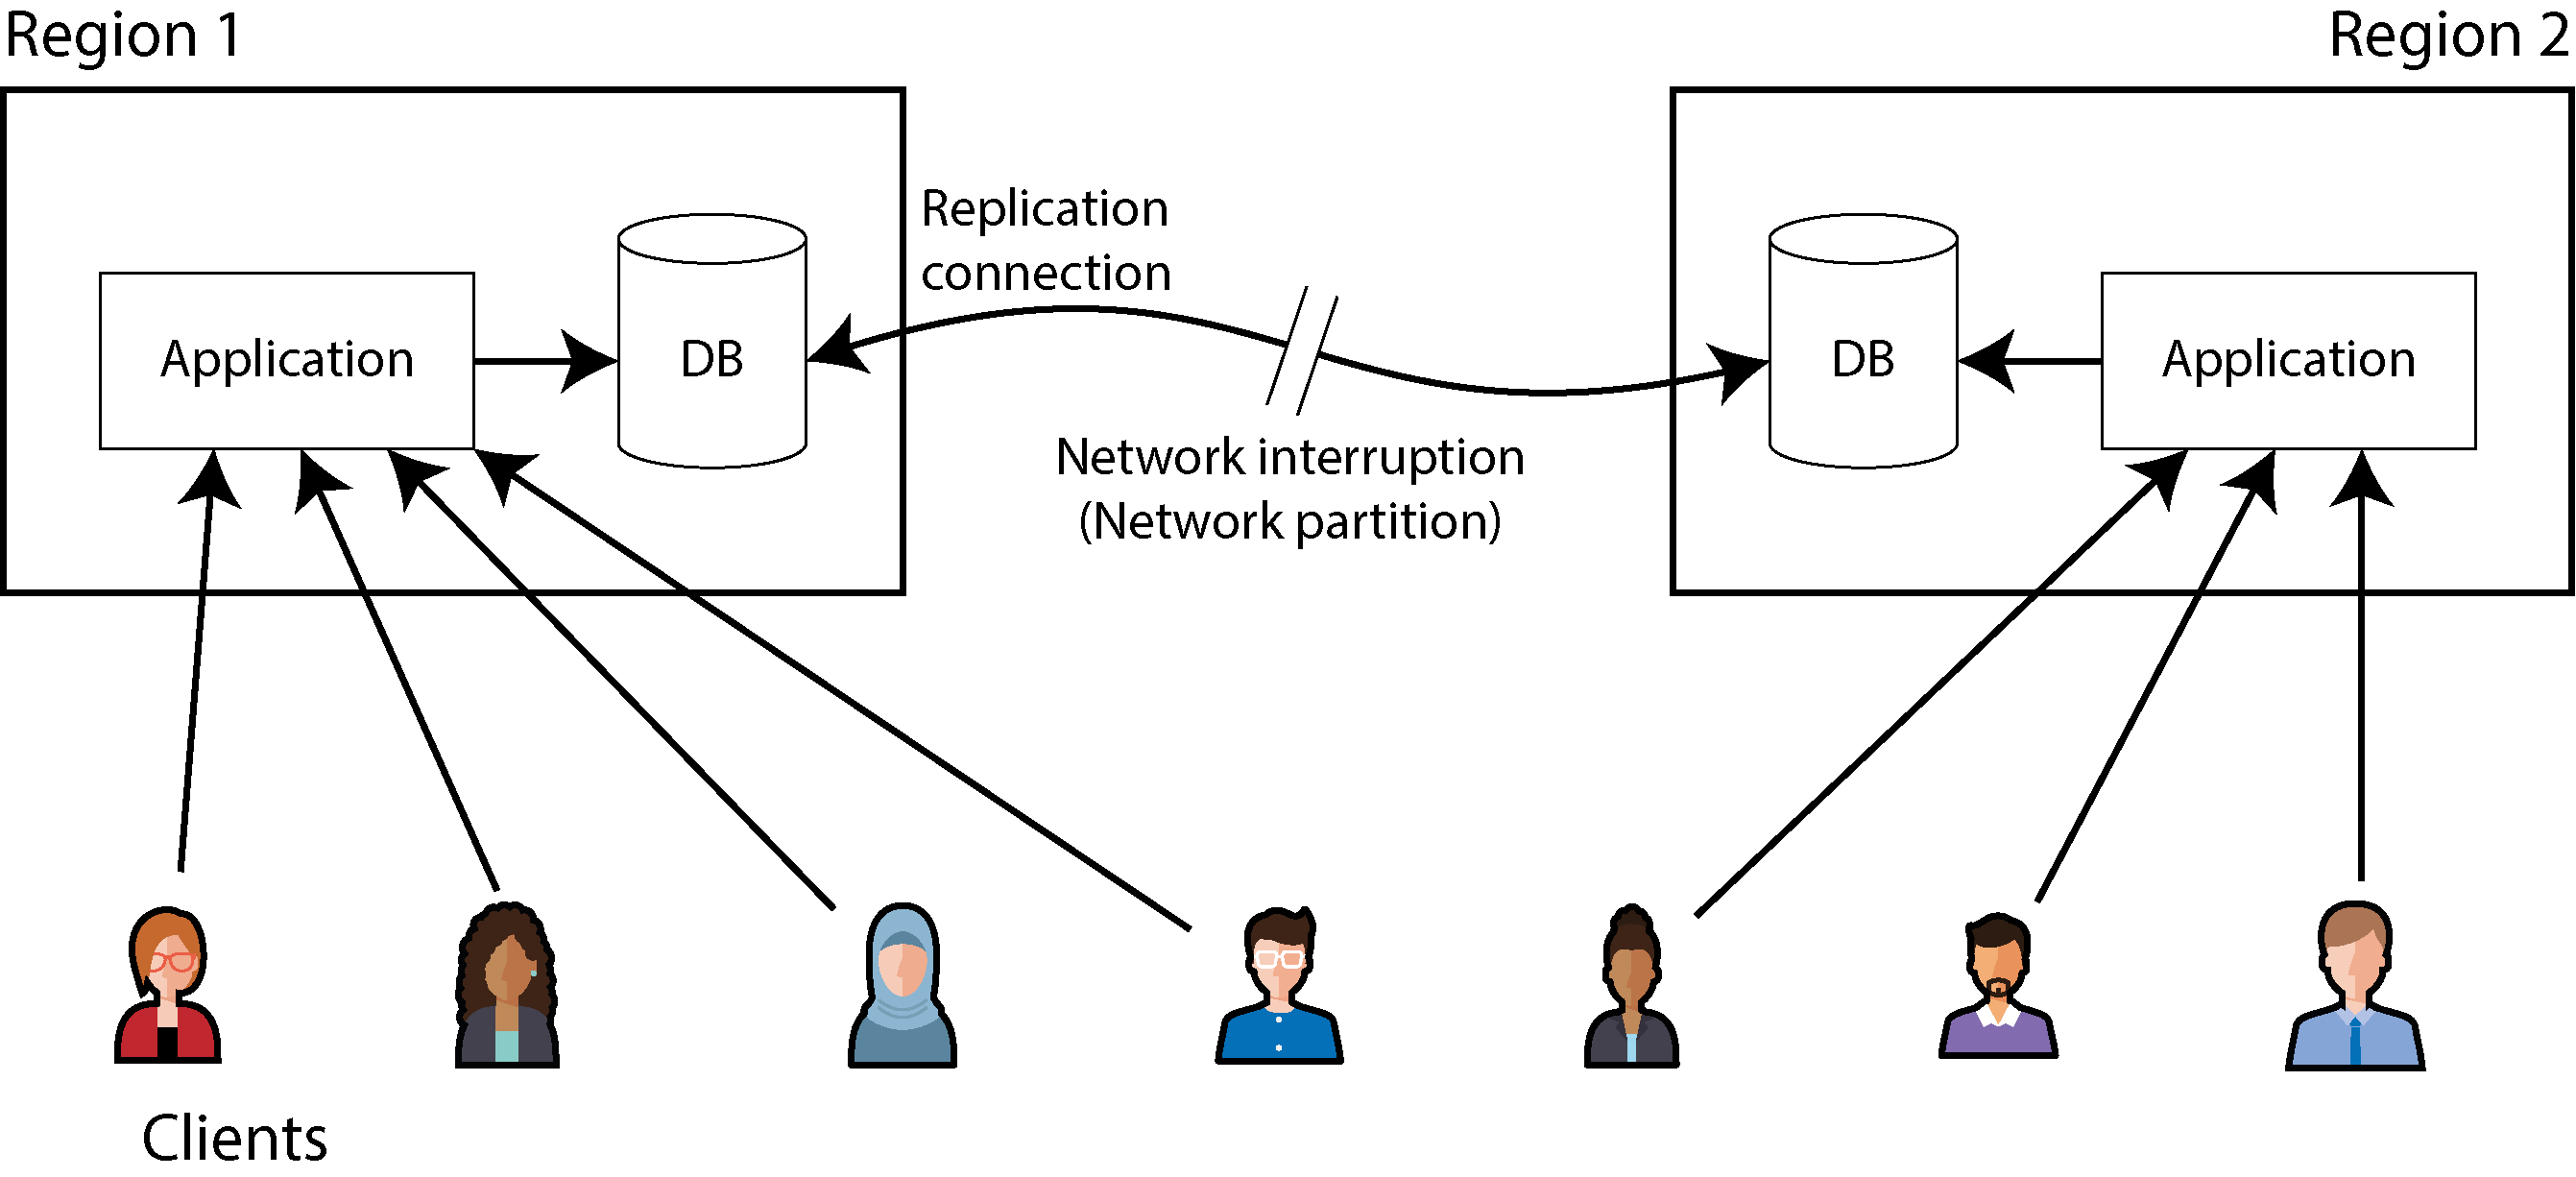


The trade-off is as follows:

- If your application requires linearizability, and some replicas are disconnected from the other replicas because of a network problem, those replicas will be temporarily unable to process requests: they must either wait until the network problem is fixed or return an error (either way, they become unavailable). This choice is sometimes known as CP (consistent under network partitions).

- If your application does not require linearizability, it can be written in such a way that each replica can process requests independently, even if it is disconnected from other replicas (e.g., multi-leader). In this case, the application can remain available in the face of a network problem, but its behavior is not linearizable. This choice is known as AP (available under network partitions).

Thus, applications that don’t require linearizability can be more tolerant of network problems. This insight is popularly known as the CAP theorem

Many distributed databases that choose not to provide linearizable guarantees: they do so primarily to increase performance, not so much for fault tolerance [40]. Linearizable systems tend to be higher latency—and this is true all the time, not only during a network fault.

## ID Generators and Logical Clocks

You can consider various alternative options for ID generators:

1. Sharded ID assignment

You could have multiple nodes that assign IDs—for example, one that generates only even numbers and one that generates only odd numbers. But you lose the ordering property.

2. Preallocated blocks of IDs

Same as above, but in blocks: 1 to 1000 to one node, 1001 to 2000 to another, etc. Still no global ordering.

3. Random UUIDs

Still no global ordering.

4. Wall-clock timestamp made unique

If your nodes’ time-of-day clocks are kept approximately correct using NTP, you can generate IDs by putting a timestamp from this clock in the most significant bits and filling the remaining bits with extra information that ensures the ID is unique even if the timestamp is not—for example, a shard number and a per-shard incrementing sequence number.

This approach is used in version 7 UUIDs [52], X’s Snowflake [53], ULIDs [54], Hazelcast’s Flake ID generator, MongoDB ObjectIDs, and many similar schemes.

But wall-clock timestamps are still unreliable and can jump back and forward, plus there are network delays between NTP and nodes.

Although Lamport clocks provide a total ordering, they do not provide linearizability—that is, they are not a way of ensuring that a value is up-to-date. They are merely a way of assigning IDs to events such that if event A happened before event B, then A’s ID is less than B’s ID.

### Logical Clocks

5. Logical Clocks

A timestamp from a logical clock therefore doesn’t tell you what time it is, but you can compare two timestamps from a logical clock to tell which one is earlier and which one is later.

Lamport timestamps

In distributed systems it is common to also use another kind of clock, called a logical clock. Fortunately, a simple method for generating logical timestamps is consistent with causality, and you can use it as a distributed ID generator. It is called a Lamport clock, proposed in 1978 by Leslie Lamport [56], in what is now one of the most-cited papers in the field of distributed systems.

A Lamport timestamp is then simply a pair of `(counter, node ID)`. Two nodes may sometimes have the same counter value, but by including the node ID in the timestamp, each timestamp is made unique.


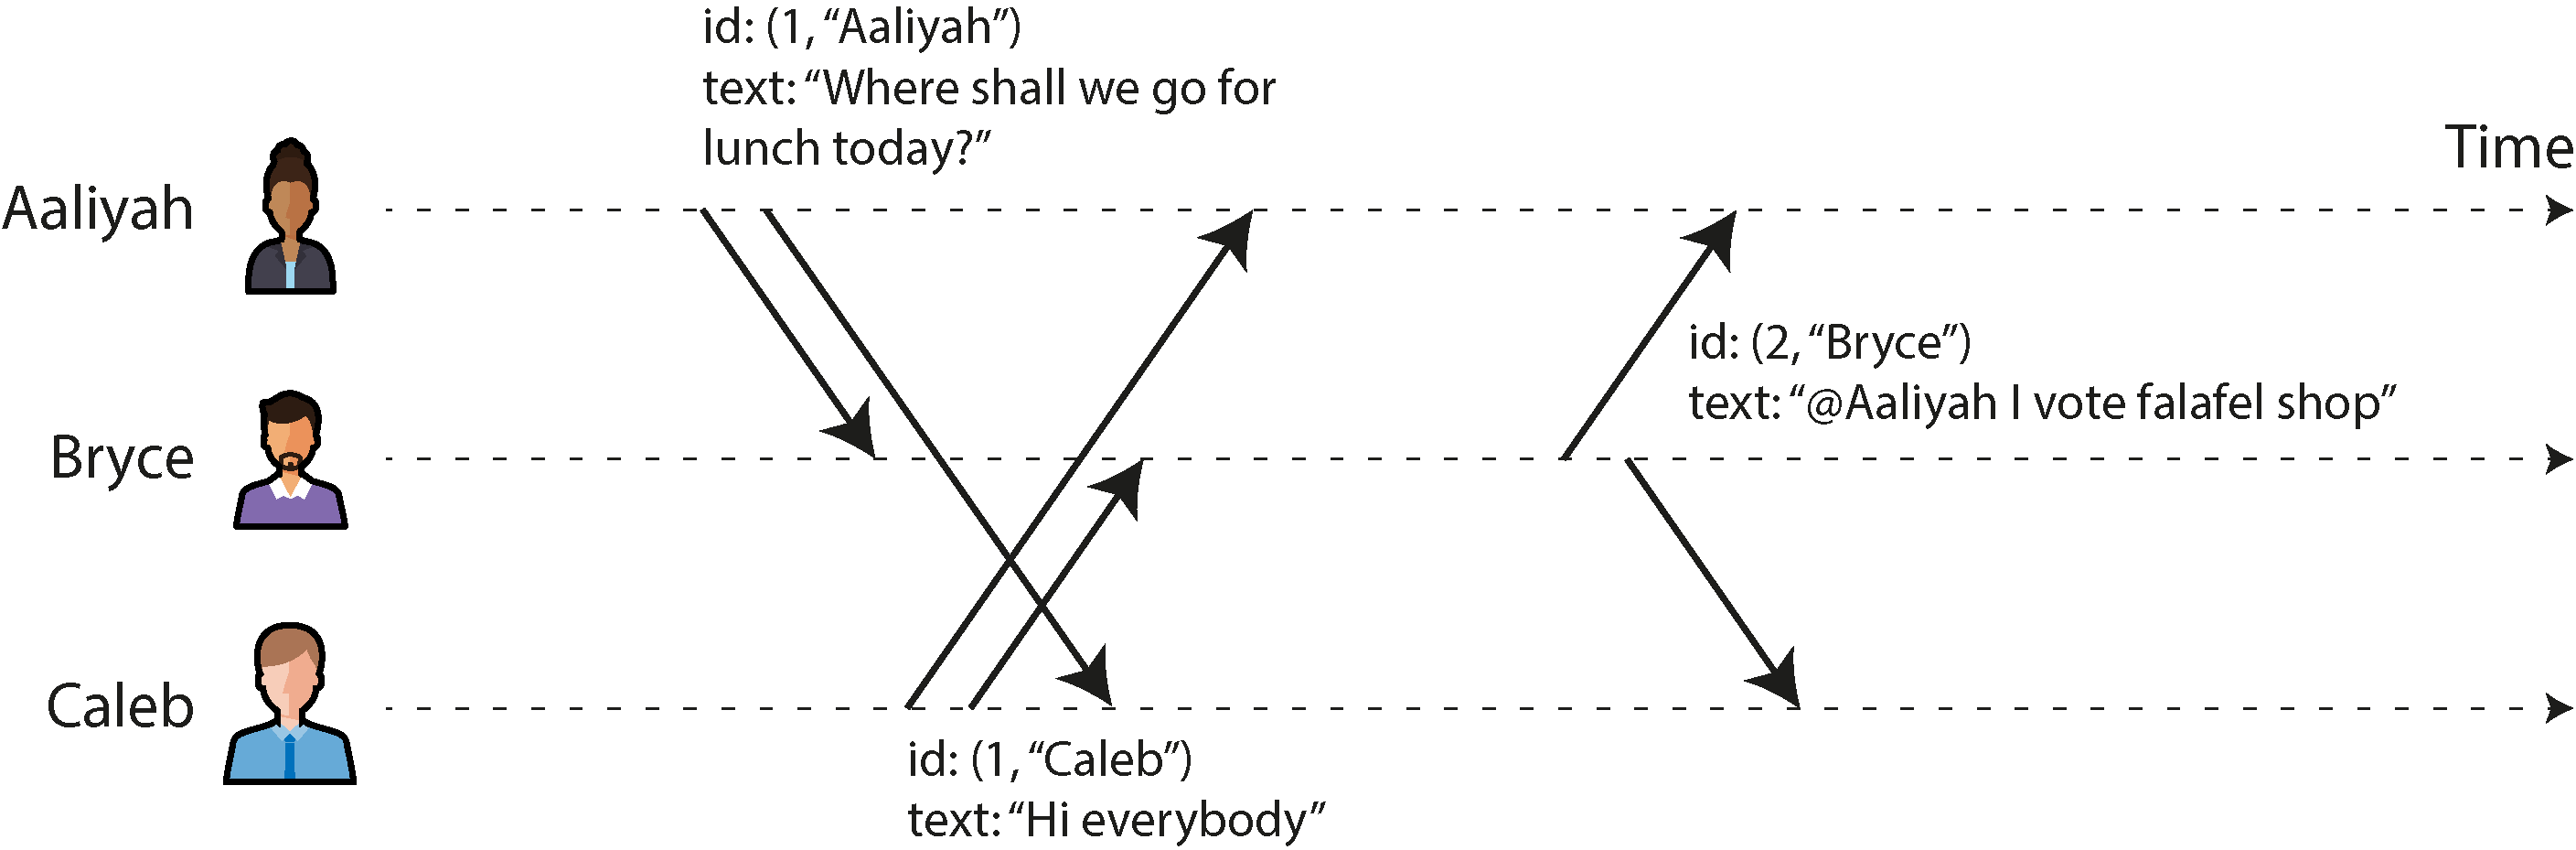

Every time a node generates a timestamp, it increments its counter value and uses the new value. Every time a node sees a timestamp from another node, if the counter value in that timestamp is greater than its local counter value, it increases its local counter to match the value in the timestamp.

How comparison works

1. Compare the counter (number) first

The event with the smaller counter happened earlier
Example:

(2, “Bryce”) > (1, “Aaliyah”)

because 2 > 1

2. If counters are equal, compare node IDs (strings)

Use normal alphabetical lexicographic order (or any other rules to just break the tie)

Example:

(1, “Aaliyah”) < (1, “Caleb”)

because "Aaliyah" comes before "Caleb" alphabetically

**What Lamport timestamps really guarantee**

They guarantee this one-way rule:

If event A caused event B, then timestamp(A) < timestamp(B)

But the reverse is not true:

timestamp(A) < timestamp(B) does **NOT** mean A caused B

In the picture, assume Caleb send his message after Bryce started (shift all three points in Caleb line to after Bryce started sedning the message). The counter remains the same: (1, "Caleb") < (2, "Bryce") but sendig of Bryce happened before Sending of Caleb.

6. Hybrid logical clocks

Lamport clocks limitation:

-  They have no direct relation to physical time

- If two nodes never communicate, one node’s counter increments will never be reflected in the other one’s counter. As a result, events generated around the same time on different nodes could have wildly different counter values.

A hybrid logical clock combines the advantages of physical time-of-day clocks with the ordering guarantees of Lamport clocks.

Like a physical clock, it counts seconds or microseconds. Like a Lamport clock, when one node sees a timestamp from another node that is greater than its local clock value, it moves its own local value forward to match the other node’s timestamp. As a result, if one node’s clock is running fast, the other nodes will similarly move their clocks forward when they communicate.

Details of the algorithm ensure that this discrepancy remains as small as possible.

Hybrid logical clocks are used by CockroachDB, for example.



7.  Vector clocks

If you want to be able to determine when records were created concurrently, you need a different algorithm, such as a vector clock.

The downside is that the timestamps from a vector clock take up much more space than the other timestamps we have discussed—potentially one integer for every node in the system.


How vector clocks work

Instead of one counter, each node keeps a vector (list) of counters, one per node.

Example with 3 nodes (Aaliyah, Caleb, Bryce):

A vector timestamp looks like:
```
Aaliyah: [1, 0, 0]
Caleb: [0, 1, 0]
Bryce: [0, 0, 1]
```
Each position tracks how many events that node has seen from each participant.

Key comparison rule

Given two vectors V and W:

V < W if:

- Every element in V ≤ W, and
- At least one element is strictly smaller
 - If neither V < W nor W < V → they are concurrent

Example: detecting concurrency

Suppose:
```
Aaliyah event: [1, 0, 0]
Caleb event: [0, 1, 0]
```
Compare:

1 > 0 in first position


0 < 1 in second position

So neither vector is ≤ the other.

👉 Conclusion: these events are concurrent

This is something Lamport clocks cannot tell you.

Example: detecting causality

Now suppose:

```
Aaliyah sends a message: [1, 0, 0]
Caleb receives it and updates: [1, 1, 0]
```
Now:
```
[1, 0, 0] < [1, 1, 0]
```
👉 This correctly shows:
Aaliyah’s event happened before Caleb’s

### Linearizable ID Generators

Although Lamport clocks and hybrid logical clocks provide useful ordering guarantees, that ordering is still weaker than the linearizable single-node ID generator we talked about previously. Recall that linearizability requires that if request A completed before request B began, then B must have the higher ID, even if A and B never communicated with each other.

Implementing a linearizable ID generator

The simplest way of ensuring that ID assignment is linearizable is by actually using a single node for this purpose. That node needs to do only three things: atomically increment a counter and return its value when requested, persist the counter value (so that it doesn’t generate duplicate IDs if the node crashes and restarts), and replicate it for fault tolerance (using single-leader replication). This approach is used in practice—for example, TiDB/TiKV calls it a timestamp oracle, inspired by Google’s Percolator

If you don’t want to use a single-node ID generator, you can do what Google’s Spanner does, as discussed in “Synchronized clocks for global snapshots”. It relies on a physical clock that returns not just a single timestamp, but a range of timestamps indicating the uncertainty in the clock reading. Spanner then waits for the duration of that uncertainty interval to elapse before returning. Tt uses a very different approach based on real time with tight synchronization, called *TrueTime.*


**How much latency does TrueTime add?**

In Google Spanner, the extra delay comes from commit wait:

Wait time ≈ TrueTime uncertainty (ε)

Typical values:

With GPS + atomic clocks: ~1–7 ms

In worst cases (clock issues): can be tens of ms, but that’s rare

So every write transaction pays roughly:

👉 ~a few milliseconds of extra latency

**🤔 Doesn’t that make Spanner slow?**

At first glance, yes—but in practice:

1. It’s small compared to distributed costs

Even without TrueTime:

Cross-region network RTT: 10–100 ms

So adding ~5 ms:

Often not the dominant cost

2. It buys something very valuable

Spanner gives external consistency (stronger than most databases):
```
If A finishes before B starts in real life → A is ordered before B
```
*Most systems cannot guarantee this.*

## Consensus

To implement locks, leases, and similar constructs in a fault-tolerant way, we need something stronger than logical clocks or ID generators. We need consensus.

we have seen several examples of things that are easy when you have only a single node but that get a lot harder if you want fault tolerance:

- A database can be linearizable if you have only a single leader and you make all reads and writes on that leader. But how do you fail over if that leader fails, while avoiding split brain?

- A linearizable ID generator on a single node is just a counter with an atomic fetch-and-add instruction—what if it crashes?

- An atomic CAS operation is useful for deciding who gets a lock or lease when several processes are racing to acquire it. how do you make it fault-tolerant?


It turns out that all of these are instances of the same fundamental distributed systems problem: consensus.

The standard formulation of consensus involves getting multiple nodes to agree on a single value.


The best-known consensus algorithms are Viewstamped Replication [62, 63], Paxos [60, 64, 65, 66], Raft [25, 67, 68], and Zab [20, 24, 69]. These algorithms have quite a few similarities, but they are not the same [70, 71].

They all work in a non-Byzantine system model.

### The Many Faces of Consensus

- Single-value consensus is very similar to an atomic CAS operation. It can be used to implement locks, leases, and uniqueness constraints.

- Constructing an append-only log also requires consensus, which is usually formalized as total order broadcast. With a log, you can implement state machine replication, leader-based replication, event sourcing, and other useful patterns.

- An atomic fetch-and-add (or atomic increment) operation also turns out to be equivalent to consensus.

- Atomic commitment of a multidatabase or multishard transaction requires that all participants agree on whether to commit or abort the transaction.

In fact, these problems are all equivalent.

**Single-value consensus**

The ability to get multiple nodes to agree on a single value is very useful.

For example:

- When a database with single-leader replication first starts up, or when the existing leader fails, several nodes may concurrently try to become the leader. Similarly, multiple nodes may race to acquire a lock or lease. Consensus allows them to decide which one wins.

- If several people concurrently try to book the last seat on an airplane or the same seat in a theater, or try to register an account with the same username, then a consensus algorithm can determine which one should succeed if it’s not clear who got there first.


More generally, one or more nodes may *propose* values, and the consensus algorithm *decides* on one of those values.

**Compare-and-set as consensus**

A CAS operation checks whether the current value of an object equals an expected value. If so, it atomically updates the object to a new value; if not, it leaves the object unchanged and returns an error.
If you have a fault-tolerant, linearizable CAS operation, solving the consensus problem is easy. Initially set the object to a null value, then have each node that wants to propose a value perform a CAS, with the expected value being null and the new value being the value it wants to propose (assuming it is non-null). The decided value is then whatever value the object is set to.

**Shared logs as consensus**

We have seen several examples of logs, such as replication logs, transaction logs, and write-ahead logs. A log stores a sequence of log entries, and anyone who reads it sees the same entries in the same order. Sometimes a log has a single writer that is allowed to append new entries, but a shared log is one where multiple nodes can request that entries be appended. An example is single-leader replication

If you have an implementation of a shared log, solving the consensus problem is easy. Every node that wants to propose a value requests that it be added to the log, and whichever value is read back in the first log entry is the value that is decided. Since all nodes read log entries in the same order, they are guaranteed to agree on which value is delivered first.

Why does this work?


The log defines a single global order

Entry log[1] is the same for all nodes

So everyone decides the same value

**Fetch-and-add as consensus**

If you have a CAS operation, implementing fetch-and-add is easy. First read the counter value, then perform a CAS where the expected value is the value you read, and the new value is that value plus 1.

Since you can implement CAS using consensus, you can also implement fetch-and-add using consensus.

Conversely, if you have a fault-tolerant fetch-and-add operation, can you solve the consensus problem? The answer is no, for more than two nodes. An exception occurs if we know for sure that no more than two nodes will propose a value.

**So why does FAA work for 2 processes?**

Because the algorithm can be designed so that:

No process ever needs to wait for a (potentially crashed) process

That’s the trick.

For 2 processes:

After FAA:
```
One gets r = 0 → leader
One gets r = 1 → follower
```
Now the follower can do something like:
```
If leader writes → read it
If leader crashes → fallback to its own value
```
And this can be done safely for 2 processes:

because there are only two possible values
and the logic can ensure both processes still agree

**Why this breaks for 3+ processes**

With 3 processes:
```
P1 gets 0 (leader)
P2 gets 1
P3 gets 2
```
Now suppose:

P1 crashes before writing

Then:

P2 and P3 must decide something

But:
```
P2 might pick its own value (B)
P3 might pick its own value (C)
```
Now:
❌ They disagree. And the is no rule that makes the decision value available to others. There is no reliable way to detect failures or “who is still in the system”.

*which is why we can say that fetch-and-add has a consensus number of 2 [30]. In contrast, CAS and shared logs solve consensus for any number of nodes that may propose values, so they have a consensus number of ∞ (infinity).*

**Atomic commitment as consensus**

What is the relationship between consensus and atomic commitment (two-phase commit algorithm)? At first glance, they seem very similar—both require nodes to come to some form of agreement. However, there is one important difference: with consensus it’s OK to decide any value that was proposed, whereas with atomic commitment the algorithm must abort if any of the participants voted to abort.

If you have a solution for consensus, you could solve atomic commitment in multiple ways

If you have a fault-tolerant atomic commitment protocol, you can also solve consensus.

### Consensus in Practice

We have seen that single-value consensus, CAS, shared logs, and atomic commitment are all equivalent: you can convert a solution to one of these problems into a solution to any of the others. That is a valuable theoretical insight, but it doesn’t answer this question: which of these many formulations of consensus is the most useful in practice?


The answer is that most consensus systems provide **shared logs** (an abstraction equivalent to total order broadcast). Raft, Viewstamped Replication, and Zab provide shared logs right out of the box. Paxos provides single-value consensus, but in practice most systems using Paxos actually use the extension called Multi-Paxos, which also provides a shared log.

Subtleties of consensus

This basic structure is common to Raft, Multi-Paxos, Viewstamped Replication, and Zab: a vote by a quorum of nodes elects a leader, and then another quorum vote is required for every entry that the leader wants to append to the log [70, 71]. Every new log entry is synchronously replicated to a quorum of nodes before it is confirmed to the client that requested the write. This ensures that the log entry won’t be lost if the current leader fails.

Pros and cons of consensus

> Although they are complex and subtle, consensus algorithms are a huge breakthrough for distributed systems. Consensus is essentially “single-leader replication done right,” with automatic failover on leader failure, ensuring that no committed data is lost and split brain is not possible, even in the face of all the problems we discussed in Chapter 9.

Nevertheless, consensus is not used everywhere because the benefits come at a cost. Consensus systems always require a strict majority to operate—three nodes to tolerate one failure, or five nodes to tolerate two failures. Every operation you perform requires communication with a quorum, so you can’t increase throughput by adding more nodes (in fact, every node you add makes the algorithm slower)

### Coordination Services

Consensus algorithms are useful in any distributed database that wants to offer linearizable operations, and many modern distributed databases use them for replication. But one family of systems is a particularly prominent user of consensus: coordination services such as ZooKeeper, etcd, and Consul.

Coordination services are modeled after Google’s Chubby lock service [19, 60]. They combine a consensus algorithm with several other features that turn out to be particularly useful when building distributed systems:

- Locks and leases

- Support for fencing

onsensus systems can generate fencing tokens by giving each log entry a monotonically increasing ID (zxid and cversion in ZooKeeper, revision number in etcd).

- Failure detection

Clients maintain a long-lived session on the coordination service and periodically exchange heartbeats to check whether the other node is still alive.

- Change notifications

A client can request that the coordination service send it a notification whenever certain keys change. This allows a client to find out when another client joins the cluster (based on the value it writes to the coordination service), or if another client fails (because its session times out and its ephemeral nodes disappear)

- Allocating work to nodes

A coordination service is useful if you have several instances of a process or service, and one of them needs to be chosen as leader or primary. If the leader fails, one of the other nodes should take over.


A dedicated coordination service also has the advantage that it can run on a fixed set of nodes (usually three or five), regardless of how many nodes are in the distributed system that relies on it for coordination. For example, in a storage system with thousands of shards, running a consensus algorithm over thousands of nodes would be terribly inefficient; it’s much better to “outsource” the consensus to a small number of nodes running a coordination service.

Normally, the kind of data managed by a coordination service is quite slow-changing. The data represents information like *“the node running on IP address 10.1.1.23 is the leader for shard 7,”* and such assignments usually change on a timescale of minutes or hours.

- Service discovery

ZooKeeper, etcd, and Consul are also often used for service discovery—that is, to find out which IP address you need to connect to in order to reach a particular service

Nevertheless, consensus is not always the right tool. In some systems, the strong consistency properties it provides are not needed, and it is better to have *weaker consistency* with higher availability and better performance. In these cases, it is common to use leaderless or multi-leader replication, which we discussed in Chapter 6. The logical clocks that we discussed in this chapter are helpful in that context.

# 11 - Batch Processing

Modern batch processing has been heavily influenced by MapReduce, a batch processing algorithm that was published by Google in 2004 [3] and subsequently implemented in various open source data systems, including Hadoop, CouchDB, and MongoDB.

Batch processing today is more often done using frameworks such as Spark or Flink, or data warehouse query engines. Like MapReduce, they rely heavily on sharding (see Chapter 7) and parallel execution, but they have far more sophisticated caching and execution strategies.

Cloud computing has grown ubiquitous. Batch storage layers are shifting from distributed filesystems (DFSs) like HDFS (Hadoop Distributed File System), GlusterFS, and CephFS to object storage systems such as S3. Scalable cloud data warehouses like BigQuery and Snowflake are blurring the line between data warehouses and batch processing.

## Batch Processing in Distributed Systems

You can think of batch data processing frameworks as distributed operating systems; they have
- filesystems,
- job schedulers,
- and programs that send data to one another through the filesystem or other communication channels.

### Distributed Filesystems

Distributed filesystems work in much the same way as filesystem of an operatin system. Files are broken into blocks, which are distributed across many machines. DFS blocks are typically much larger than local blocks. HDFS defaults to 128 MB, while JuiceFS and many object stores use 4 MB blocks—much larger than ext4’s 4,096 bytes. Larger blocks mean less metadata to keep track of, which makes a big difference on petabyte-sized datasets. Larger blocks also lower the overhead of seeking to a block relative to reading it.

### Object Stores

Object storage services such as Amazon S3, Google Cloud Storage, Azure Blob Storage, and OpenStack Swift have become a popular alternative to distributed filesystems for batch processing jobs.

### Distributed Job Orchestration

Our operating system analogy also applies to job orchestration. When you execute a Unix batch job, something needs to actually run the awk, sort, uniq, and head processes. Data needs to be transferred from one process’s output to another process’s input, memory must be allocated for each process, instructions from each process must be scheduled fairly and executed on the CPU, memory and I/O boundaries must be enforced, and so on.

On a single machine, an operating system’s kernel is responsible for such work. In a distributed environment, this is the role of a job orchestrator.

Scheduling workflows

This pattern arises in distributed batch processes: often the output from one job needs to become the input to one or more other jobs, and each job may have several inputs that are produced by other jobs. This is called a workflow or directed acyclic graph (DAG) of jobs.

Spark, Flink, and other batch execution engines support a similar model where the output of one task is directly passed to another task (over the network if the tasks are running on different machines).

However, it is more typical for one job in a workflow to write its output to a distributed filesystem or object store and for the next job to read it from there. This decouples the jobs from each other, allowing them to run at different times.

 To handle these dependencies between job executions, various workflow schedulers have been developed, including Airflow, Dagster, and Prefect. Workflow schedulers have management features that are useful when maintaining a large collection of batch jobs. Workflows consisting of 50 to 100 jobs are common in many data pipelines, and in a large organization many teams may be running jobs or workflows that read one another’s output across many systems.

## Batch Processing Models

### MapReduce

The pattern of data processing in MapReduce is very similar to the web server log analysis example in “Simple Log Analysis”:

1. Read a set of input files and break it into records. In the web server log example, each record is one line in the log (i.e., \n is the record separator). In Hadoop’s MapReduce, the input file is stored in a distributed filesystem like HDFS or an object store like S3. Various file formats are used, such as Apache Parquet (a columnar format, see “Column-Oriented Storage”) or Apache Avro (a row-based format, see “Avro”).
2. Call the mapper function to extract a key and value from each input record. In the Unix tools example, the mapper function is awk `{print $7}`, which extracts the URL ($7) as the key and leaves the value empty.
3. Sort all the key-value pairs by key. In the log example, this is done by the first sort command.
4. Call the reducer function to iterate over the sorted key-value pairs. If there are multiple occurrences of the same key, the sorting has made them adjacent in the list, so it is easy to combine those values without having to keep a lot of state in memory. In the Unix tools example, the reducer is implemented by the command uniq -c, which counts the number of adjacent records with the same key.

Those four steps can be performed by one MapReduce job.

MapReduce is also quite slow compared to more modern batch processors. One reason is that its file-based I/O prevents job pipelining (i.e., processing output data in a downstream job before the upstream job is complete).

### Dataflow Engines

To fix some of MapReduce’s problems, several new execution engines for distributed batch computations were developed, the most well-known of which are Spark [18, 21] and Flink [19].

They are designed differently, but they have one thing in common: they handle an entire workflow as one job, rather than breaking it into independent subjobs.

Since they explicitly model the flow of data through several processing stages, these systems are known as dataflow engines.

You can use dataflow engines to implement the same computations as MapReduce workflows, and they usually execute significantly faster because of the optimizations

### Shuffling Data

Batch processors need to be able to sort datasets petabytes in size, which are too large to fit on a single machine. They therefore require a distributed *sorting algorithm* where both the input and the output are sharded. Such an algorithm is called a shuffle. (**SHUFFLE IS NOT RANDOM**)


Shuffling is a foundational algorithm for batch processors, where it is used for joins and aggregations. MapReduce, Spark, Flink, Daft, Dataflow, and BigQuery [24] all implement scalable and performant shuffle algorithms in order to handle large datasets.


### Query Languages

MapReduce, dataflow engines, and cloud data warehouses have all embraced SQL as the lingua franca for batch processing. It’s a natural fit, because legacy data warehouses used SQL, data analytics and ETL tools already support it, and all developers and analysts know it.

### DataFrames

Data scientists and statisticians are generally used to working with the DataFrame data model found in R and Pandas.

DataFrame APIs appear similar to dataflow APIs, but implementations vary. While Pandas executes operations immediately when DataFrame methods are called, Spark first translates all the DataFrame API calls into a query plan and runs query optimization before executing the workflow on top of its distributed dataflow engine.

## Batch Use Cases



### Extract–Transform–Load (ETL)

Batch processing environments also come with robust workflow schedulers, which make it easy to schedule, orchestrate, and debug ETL data pipeline jobs.

chedulers like Airflow even come with built-in source, sink, and query operators for MySQL, PostgreSQL, Snowflake, Spark, Flink.

Data pipelines used to be managed by a single data engineering team, as it was considered unfair to ask other teams working on product features to write and manage complex batch data pipelines. Recently, improvements in batch processing models and metadata management have made it much easier for engineers across an organization to contribute to and manage their own data pipelines. Data mesh [35, 36], data contract [37], and data fabric [38] practices provide standards and tools to help teams safely publish their data for consumption by anybody in the organization.


### Analytics

Analysts write SQL queries that execute atop a query engine, which reads from and writes to a distributed filesystem or object store. Table metadata such as table-to-file mappings, names, and types are managed with table formats such as Apache Iceberg and catalogs such as Unity (see “Cloud Data Warehouses”). This architecture is known as a data lakehouse.

SQL support enables batch processing frameworks to integrate with spreadsheets and data visualization tools such as Tableau, Power BI, Looker, and Apache Superset. For example, Tableau offers SparkSQL and Presto connectors, while Apache Superset supports Trino, Hive, Spark SQL, Presto, and many other systems that ultimately execute batch jobs to query data.


### Machine Learning

Machine learning (ML) makes frequent use of batch processing. Data scientists, ML engineers, and AI engineers use batch processing frameworks to investigate data patterns, transform data, and train ML models. Common uses include the following:

Feature engineering

Raw data is filtered and transformed into data that models can be trained on. Predictive models often need numeric data, so engineers must transform other forms of data (such as text or discrete values) into the required format.

Model training

The training data is the input to the batch process, and the weights of the trained model are the output.

Batch inference

A trained model can be used to make predictions in bulk if datasets are large and real-time results are not required. This includes evaluating the model’s predictions on a test dataset.

Batch processing frameworks provide tools explicitly for these use cases. For example, Apache Spark’s MLlib and Apache Flink’s FlinkML come with a wide variety of feature engineering tools, statistical functions, and classifiers.

Batch processing is also an integral part of large language model data preparation and training. Raw text input data such as the contents of websites typically resides in a DFS or object store. This data must be preprocessed to make it suitable for training. Preprocessing steps that are well suited for batch processing frameworks include the following:

- Extracting plain text from HTML and fixing malformed text.
- Detecting and removing low-quality, irrelevant, and duplicate documents.
- Tokenizing text (splitting it into words) and converting it into embeddings, or numeric representations of each word.

Batch processing frameworks such as Kubeflow, Flyte, and Ray are purpose-built for such workloads. OpenAI uses Ray as part of its ChatGPT training process, for example [43]. These frameworks have built-in integrations for LLM and AI libraries such as PyTorch, TensorFlow, XGBoost, and many others. They also offer built-in support for feature engineering, model training, batch inference, and fine-tuning (adjusting a foundational model for specific use cases).

### Serving Derived Data

Regardless of the system used, the precomputed data needs to make its way from the batch processor’s distributed filesystem or object store back into the database that’s serving live traffic.

ou might be tempted to use the client library for your favorite database directly within a batch job and write directly to the database server, one record at a time. But it's bad ideaa since the database can easily be overwhelmed and the performance of this job is poor.

A better solution is to have batch jobs push precomputed datasets to streams such as Kafka topics:

- Streaming systems are optimized for sequential writes, which makes them better suited for the bulk write workload of a batch job.

- Streaming systems can act as a buffer between the batch job and the production databases. Downstream systems can throttle their read rate to ensure they can continue to comfortably serve production traffic.
- The output of a single batch job can be consumed by multiple downstream systems.
- Streaming systems can serve as a security boundary between batch processing environments and production networks. They can be deployed in a so-called demilitarized zone (DMZ) network that sits between the batch processing network and the production network.

Another pattern that is more common when bootstrapping databases is to build a brand-new database inside the batch job and bulk-load those files directly into the database from a distributed filesystem, object store, or local filesystem. Many data systems offer bulk import tools, such as TiDB’s Lightning and Apache Pinot’s Hadoop import jobs. RocksDB also offers an API to bulk-import Sorted String Table (SST) files from batch jobs.

In practice, a batch job:

- Reads raw data from a source (e.g., logs, parquet files, etc.)
- Transforms and sorts it into the database’s native format
- Writes out files that match the database’s internal storage layout

Then the database:
- Imports those files directly, bypassing normal write paths

Key benefits

1. Massive speedups

Bulk ingestion can be orders of magnitude faster than row-based writes.

2. Better storage layout

Data is:

Pre-sorted

Pre-indexed

Already compacted

3. Reduced write amplification

Especially important for LSM-tree systems like RocksDB.

4. Isolation from production systems

You can:

Build safely offline

Validate before exposing

Swap in atomically

# 12 - Stream Processing

## Transmitting Event Streams

In a stream processing context, a record is more commonly known as an event, but it is essentially the same thing: a small, self-contained, immutable object containing the details of something that happened at a point in time. An event usually contains a timestamp indicating when it happened according to a time-of-day clock.

For example, the thing that happened might be an action that a user took, such as viewing a page or making a purchase. It might also originate from a machine, such as a periodic measurement from a temperature sensor or a CPU utilization metric.

An event may be encoded as a text string, or JSON, or perhaps in a binary form.

 In streaming terminology, an event is generated once by a producer (also known as a publisher or sender) and then potentially processed by multiple consumers (subscribers or recipients) [3]. In a filesystem, a filename identifies a set of related records; in a streaming system, related events are usually grouped together into a topic or stream.

### Messaging Systems

A common approach for notifying consumers about new events is to use a messaging system: a producer sends a message containing the event, which is then pushed to consumers.

A direct communication channel like a Unix pipe or TCP connection between producer and consumer would be a simple way of implementing a messaging system. However, most messaging systems expand on this basic model. In particular, Unix pipes and TCP connect exactly one sender with one recipient, whereas a messaging system allows multiple producer nodes to send messages to the same topic and allows multiple consumer nodes to receive messages in a topic.

To differentiate the systems, it is particularly helpful to ask the following two questions:
- What happens if the producers send messages faster than the consumers can process them?

Broadly speaking, the system has three options: **drop messages, buffer messages in a queue, or apply backpressure** (*also known as flow control, which blocks the producer from sending more messages*). For example, Unix pipes and TCP use backpressure; they have a small fixed-size buffer, and if it fills up, the sender is blocked until the recipient takes data out of the buffer

- What happens if nodes crash or temporarily go offline—are any messages lost?

As with databases, durability may require a combination of writing to disk and/or replication (see the sidebar “Replication and Durability”), which has a cost. If you can afford to sometimes lose messages, you can probably get higher throughput and lower latency on the same hardware.

**Direct messaging from producers to consumers**

A number of messaging systems use direct network communication between producers and consumers without using intermediary nodes:

- UDP multicast is widely used in the financial industry for streams such as stock market feeds, where low latency is important

- Brokerless messaging libraries such as ZeroMQ and nanomsg take a similar approach, implementing publish/subscribe messaging over TCP or IP multicast.

- If the consumer exposes a service on the network, producers can make a direct HTTP or RPC request to push messages to the consumer. **This is the idea behind webhooks** [11], a pattern in which a callback URL of one service is registered with another service, and it makes a request to that URL whenever an event occurs.

**Message brokers**

A widely used alternative is to send messages via a message broker (also known as a message queue), which is essentially a kind of database that is optimized for handling message streams [12]. It runs as a server, with producers and consumers connecting to it as clients. Producers write messages to the broker, and the broker delivers them to consumers.

Some message brokers only keep messages in memory, while others (depending on configuration) write them to disk so that they are not lost in case of a broker crash.

A consequence of queueing is that consumers are generally asynchronous. When a producer sends a message, it normally waits only for the broker to confirm that it has buffered the message and does not wait for the message to be processed by consumers.


We can divide message brokers into two types:

- AMQP/JMS-style message broker

The broker assigns individual messages to consumers, and consumers acknowledge individual messages when they have been successfully processed. Messages are deleted from the broker after they have been acknowledged. This approach is appropriate as an asynchronous form of RPC (see also “Event-Driven Architectures”)—for example, in a task queue, where the exact order of message processing is not important and where there is no need to go back and read old messages again after they have been processed.

- Log-based message broker

The broker assigns all messages in a shard to the same consumer node and always delivers messages in the same order. Parallelism is achieved through sharding, and consumers track their progress by checkpointing the offset of the last message they have processed. The broker retains messages on disk, so it is possible to jump back and reread old messages if necessary.


 Traditional view of message brokers, which is encapsulated in standards like JMS [13] and AMQP [14] and implemented in software like RabbitMQ, ActiveMQ, HornetQ, Qpid, TIBCO Enterprise Message Service, IBM MQ, Azure Service Bus, and Google Cloud Pub/Sub .

**Multiple consumers**

When multiple consumers read messages in the same topic, two main patterns of messaging are used:

1. Load balancing

Each message is delivered to one of the consumers, so the consumers can share the work of processing the messages in the topic.

2. Fan-out

Each message is delivered to all the consumers. Fan-out allows several independent consumers to each “tune in” to the same broadcast of messages, without affecting one another—the streaming equivalent of having several batch jobs that read the same input file.

The two patterns can be combined—for example, using Kafka’s **consumer groups** feature. When a consumer group subscribes to a topic, each message in the topic is sent to one of the consumers in the group (*balancing load across the consumers in the group*). If two separate consumer groups subscribe to the same topic, each message is sent to one consumer in each group (*providing fan-out across consumer groups*).

**Acknowledgments and redelivery**

Consumers may crash at any time. Therefore, a broker could deliver a message to a consumer but the consumer never processes it, or only partially processes it before crashing. To ensure that the message is not lost, message brokers use acknowledgments: a client must explicitly tell the broker when it has finished processing a message so that the broker can remove it from the queue.

If the connection to a client is closed or times out without the broker receiving an acknowledgment, it assumes that the message was not processed, and therefore it delivers the message again to another consumer.

(Note that it could happen that the message actually was fully processed, but the acknowledgment was lost in the network. Handling this case requires an atomic commit protocol, as discussed in “Exactly-once message processing”, unless the operation was idempotent or exactly-once semantics are not required.)

**Dead letter queues (DLQs)**

If there is a message that causes a consumer to crash, the nthe broker resends the message to another consumer in a load balanced system which causes that consumer to fail too. his loop repeats itself indefinitely.

Dead letter queues (DLQs) are used to handle this problem. Rather than keeping the message in the current queue and retrying forever, the message is moved to a different queue to unblock consumers.

### Log-Based Message Brokers

Sending a packet over a network or making a request to a network service is normally a transient operation that leaves no permanent trace. Although it is possible to record such an operation permanently (using packet capture and logging), we normally don’t think of it that way.

AMQP/JMS-style message brokers inherited this transient messaging mindset. Even though they may write messages to disk, they quickly delete the messages again after they have been delivered to consumers.

Why can we not have a hybrid, combining the durable storage approach of databases with the low-latency notification facilities of messaging? This is the idea behind log-based message brokers, which have become very popular in recent years.

**Using logs for message storage**

A log is simply an append-only sequence of records on disk.

The same structure can be used to implement a message broker. A producer sends a message by appending it to the end of the log, and a consumer receives messages by reading the log sequentially. If a consumer reaches the end of the log, it waits for a notification that a new message has been appended.

To scale to higher throughput than a single disk can offer, the log can be sharded (Kafka calls this a partition). Different shards can then be hosted on different machines, making each shard a separate log that can be read and written independently from other shards, and a topic can be defined as a group of shards that all carry messages of the same type.

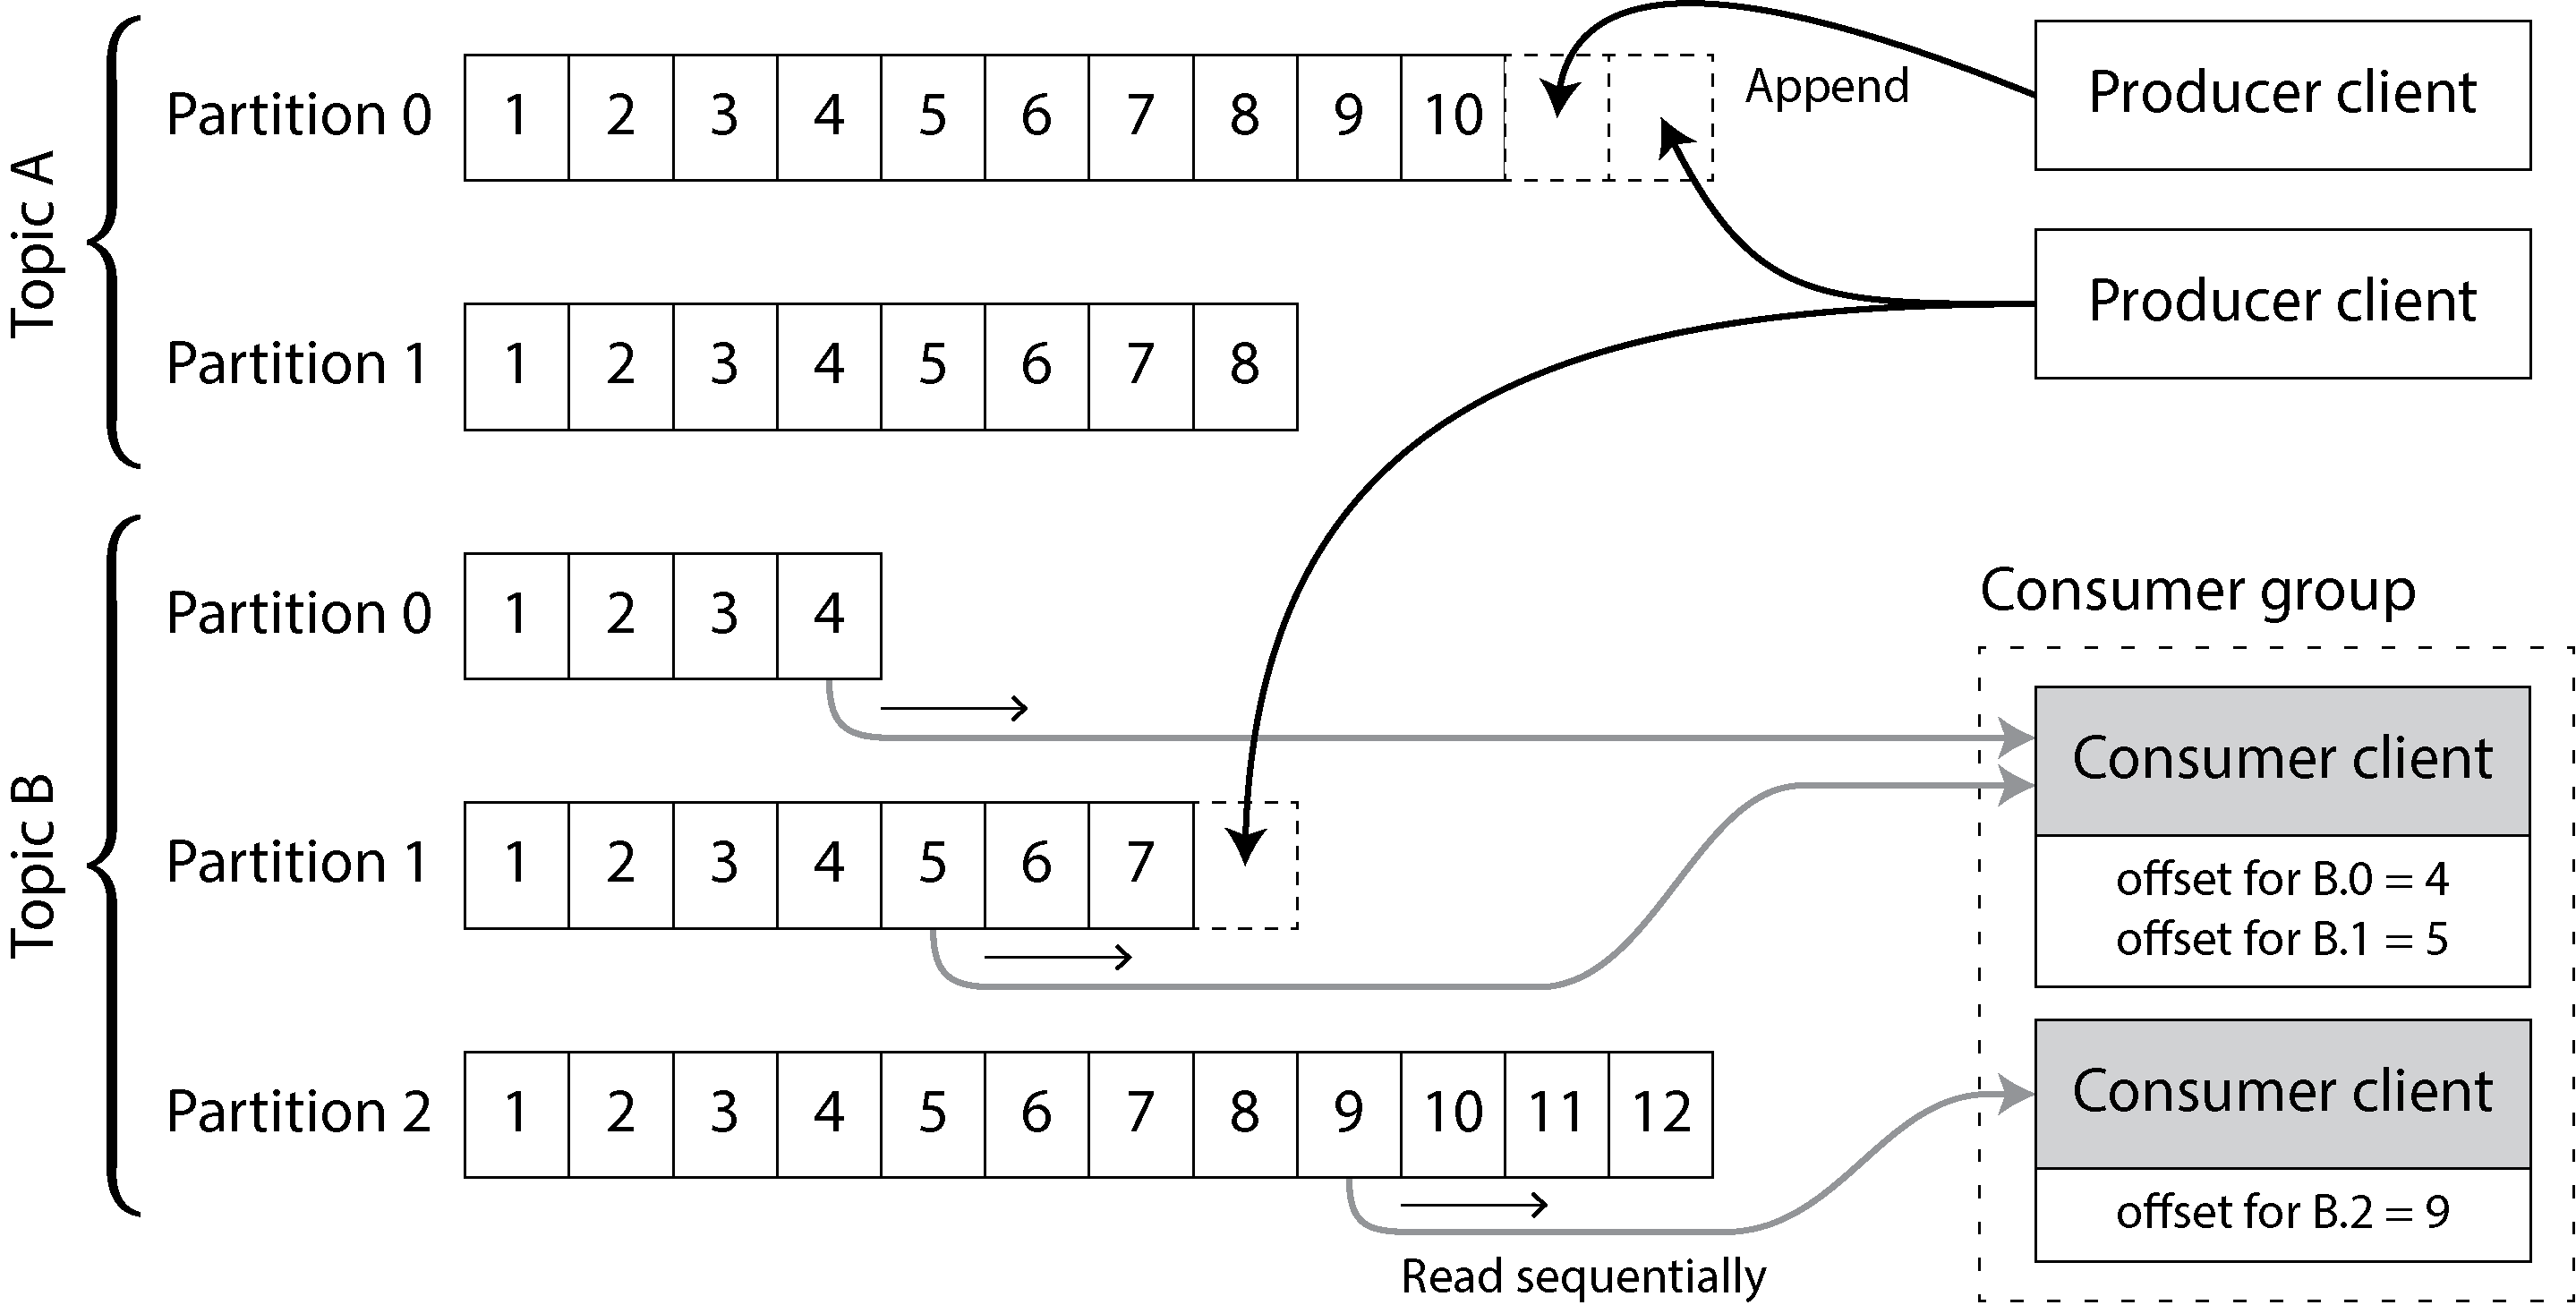

Within each shard, the broker assigns a monotonically increasing sequence number, or offset, to every message (in Figure 12-3, the numbers in boxes are message offsets). Such a sequence number makes sense because a partition (shard) is append-only, so the messages within a partition are totally ordered. There is no ordering guarantee across different partitions.

Apache Kafka [20] and Amazon Kinesis Streams are log-based message brokers that work like this. Google Cloud Pub/Sub is architecturally similar but exposes a JMS-style API rather than a log abstraction [15].

Even though these message brokers write all messages to disk, they are able to achieve throughput of millions of messages per second by sharding across multiple machines and to achieve fault tolerance by replicating messages.

**Logs compared to traditional messaging**

when messages may be expensive to process and you want to parallelize processing on a message-by-message basis, and message ordering is not so important, the JMS/AMQP style of message broker is preferable.

On the other hand, in situations with high message throughput, where each message is fast to process and message ordering is important, the log-based approach works very well [23, 24].

However, the distinction between the two architectures is being blurred since log-based messaging systems such as Kafka now support JMS/AMQP-style consumer groups, which allow multiple consumers to receive messages from the same partition.

Since sharded logs typically preserve message ordering only within a single shard, all messages that need to be consistently ordered need to be routed to the same shard. For example, an application may require that the events relating to one particular user appear in a fixed order. This can be achieved by choosing the shard for an event based on the user ID of that event (*in other words, making the user ID the **partition key**).*

**Disk space usage**

If you only ever append to the log, you will eventually run out of disk space. To reclaim disk space, the log is divided into segments, and from time to time old segments are deleted or moved to archive storage.

**When consumers cannot keep up with producers**

At the beginning of “Messaging Systems” we discussed three choices of what to do if a consumer cannot keep up with the producer’s rate of sending messages: dropping messages, buffering, or applying backpressure. In this taxonomy, the log-based approach is a form of buffering with a large but fixed-size buffer (limited by the available disk space).

**Backpressure is a flow-control mechanism:**

> When a system can’t keep up with incoming data, it signals upstream producers to slow down.

If a consumer falls so far behind that the messages it requires are older than those retained on disk, it will not be able to read those messages—so the broker effectively drops old messages that go back further than the size of the buffer can accommodate. You can monitor how far a consumer is behind the head of the log and raise an alert if it falls behind significantly.

Even if a consumer does fall too far behind and starts missing messages, only that consumer is affected; it does not disrupt the service for other consumers. This fact is a big operational advantage.

You can experimentally consume a production log for development, testing, or debugging purposes, without having to worry much about disrupting production services. When a consumer is shut down or crashes, it stops consuming resources—the only thing that remains is its consumer offset.

This behavior contrasts with that of traditional message brokers, where you need to be careful to delete any queues whose consumers have been shut down to avoid them unnecessarily accumulating messages and taking away memory from active consumers.

## Databases and Streams

In this section we will first look at a problem that arises in heterogeneous data systems, then explore how we can solve it by bringing ideas from event streams to databases.

### Keeping Systems in Sync

As the same or related data appears in several places, they need to be kept in sync with one another. If an item is updated in the database, it also needs to be updated in the cache, search indexes, and data warehouse.

If periodic full database dumps are too slow, an alternative that is sometimes used is *dual writes*, in which the application code explicitly writes to each of the systems when data changes—for example, first writing to the database, then updating the search index, then invalidating the cache entries (or even performing those writes concurrently).

*However, dual writes have serious problems, one of which is race conditions.*

The situation would be better if there really was only one leader—for example, the database—and if we could make the search index a follower of the database. But is this possible in practice?

### Change Data Capture

The problem with most databases’ replication logs is that they have long been considered to be an internal implementation detail of the database, not a public API. Clients are supposed to query the database through its data model and query language, not parse the replication logs and try to extract data from them.

More recently, there has been growing interest in **change data capture** (CDC), which is the process of observing all data changes written to a database and extracting them in a form in which they can be replicated to other systems [28]. CDC is especially interesting if changes are made available as a stream, immediately as they are written.

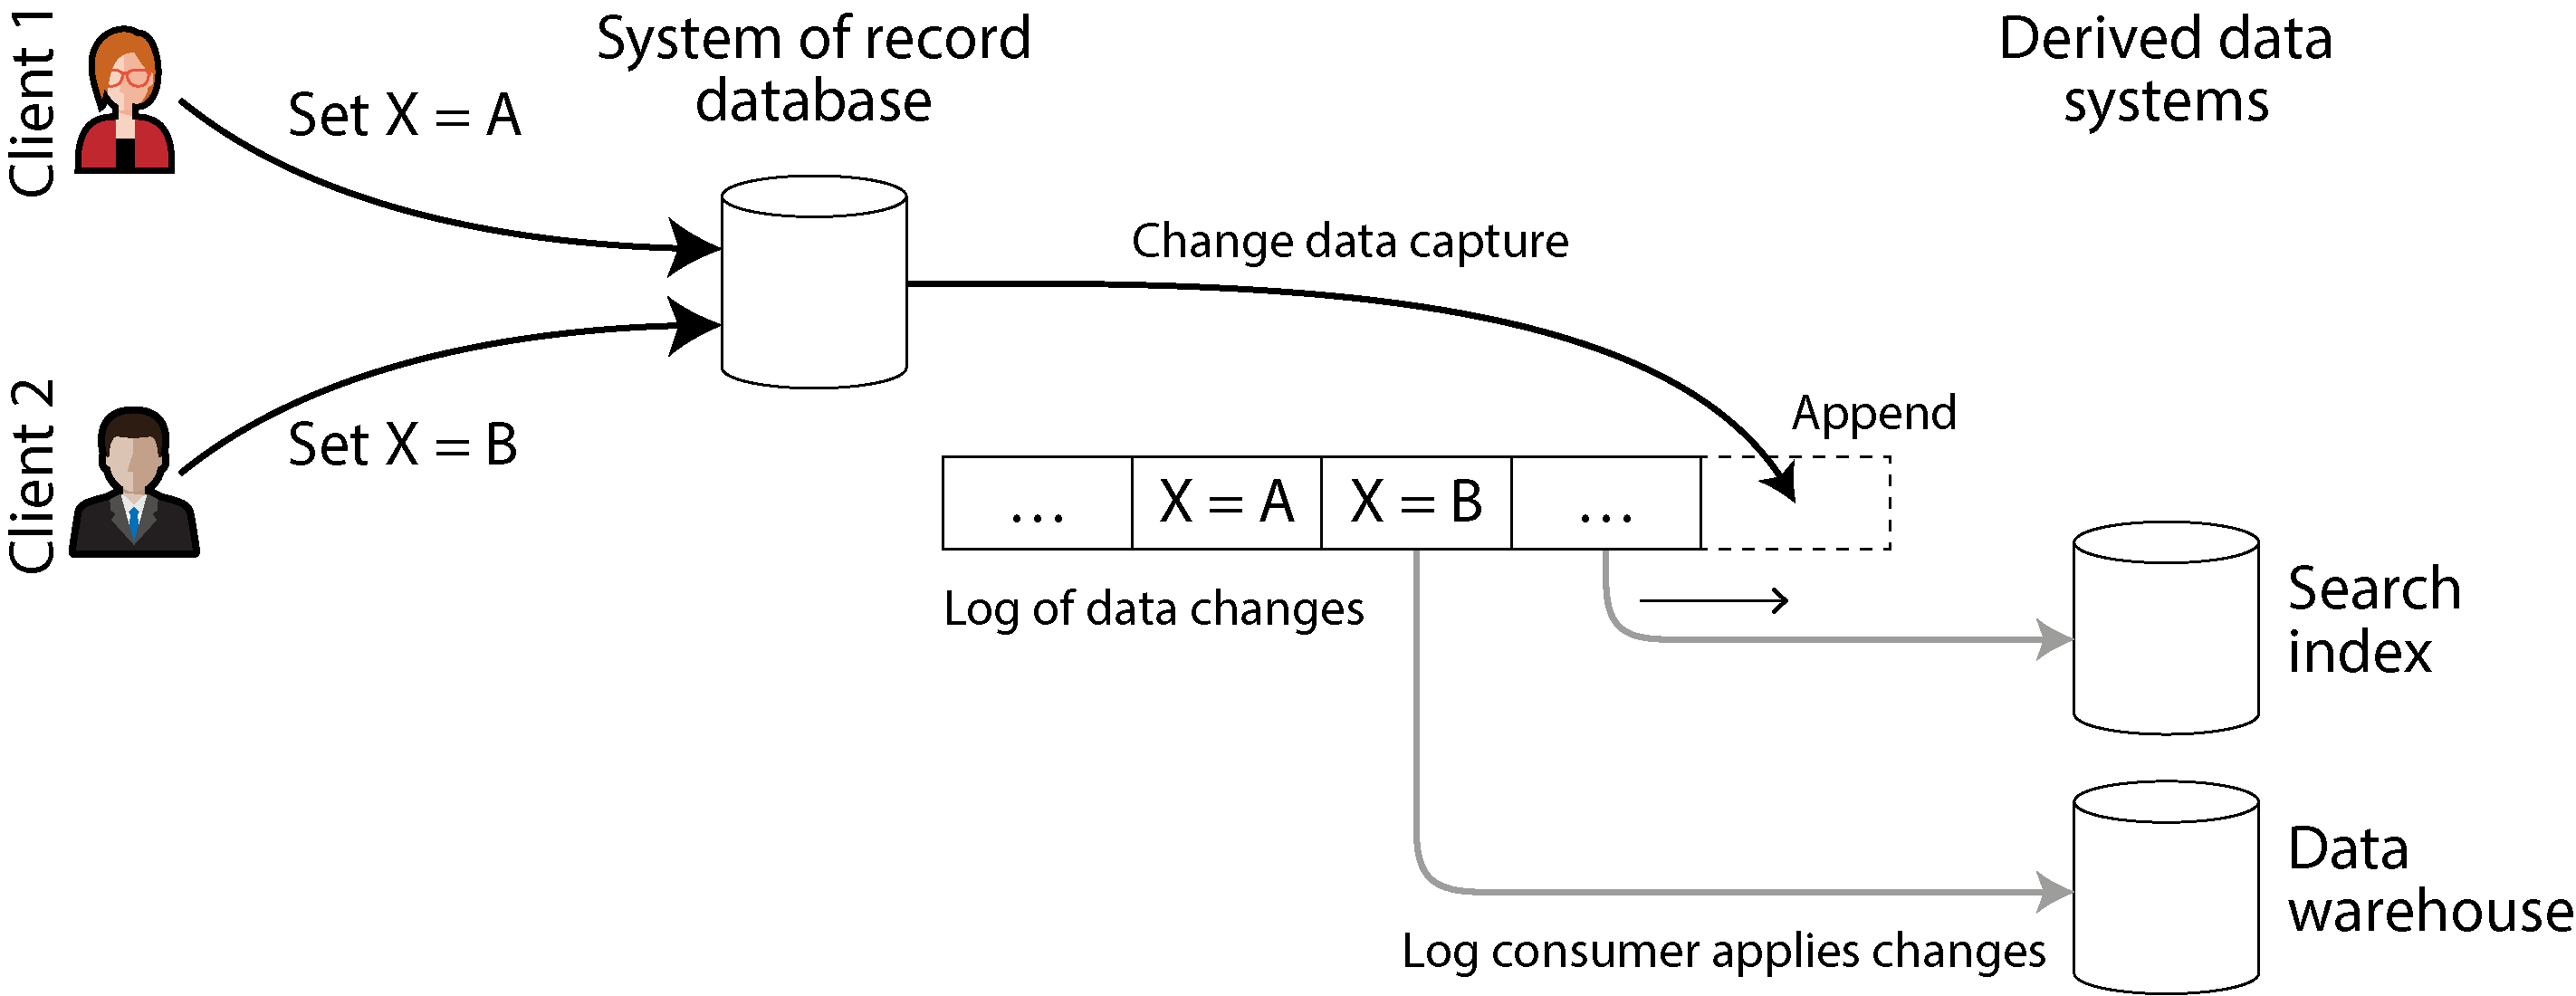

Essentially, CDC makes one database the leader (the one from which the changes are captured) and turns the others into followers. A log-based message broker is well suited for transporting the change events from the source database to the derived systems, since it preserves the ordering of messages.

### State, Streams, and Immutability

Immutability in databases is an old idea. For example, accountants have been using immutability for centuries in financial bookkeeping. When a transaction occurs, it is recorded in an **append-only ledger**, which is essentially a log of events describing money, goods, or services that have changed hands. The accounts, such as profit and loss or the balance sheet, are derived from the transactions in the ledger by adding them up [40].


If a mistake is made, accountants don’t erase or change the incorrect transaction in the ledger. Instead, they add another transaction that compensates for the mistake—for example, refunding an incorrect charge.

Immutable events also capture more information than just the current state. For example, on a shopping website, a customer may add an item to their cart and then remove it again. Although the second event cancels out the first event from the point of view of order fulfillment, it may be useful to know for analytics purposes that the customer was considering a particular item but then decided against it. Perhaps they will choose to buy it in the future, or perhaps they found a substitute. This information is recorded in an event log, but it would be lost in a database that deletes items when they are removed from the cart.


## Processing Streams

What remains is to discuss what you can do with the stream once you have it—namely, you can process it. Broadly, you have three options:

1. You can take the data in the events and write it to a database, cache, search index, or similar storage system, from where it can then be queried by other clients

2. You can push the events to users in some way—for example, by sending email alerts or push notifications, or by streaming the events to a real-time dashboard where they are visualized. In this case, a human is the ultimate consumer of the stream.

3. You can process one or more input streams to produce one or more output streams. Streams may go through a pipeline consisting of several such processing stages before they eventually end up at an output (option 1 or 2).

### Uses of Stream Processing

- Fraud detection systems
- Trading systems need to examine price changes in a financial market and execute trades according to specified rules
- Manufacturing systems need to monitor the status of machines in a factory and quickly identify the problem
- Military and intelligence systems need to track the activities of a potential aggressor

These kinds of applications require quite sophisticated pattern matching and correlations. However, other uses of stream processing have also emerged over time. In this section we will briefly compare and contrast some of these applications.

**Complex event processing**

Complex event processing (CEP) is an approach developed in the 1990s for analyzing event streams, especially geared toward the kind of application that requires searching for certain event patterns [52]. Similarly to the way that a regular expression allows you to search for certain patterns of characters in a string, CEP allows you to specify rules to search for certain patterns of events in a stream.

**Stream analytics**

Stream processing is also used for analytics on streams. The boundary between CEP and stream analytics is blurry, but as a general rule, stream analytics is less focused on detecting specific event sequences and more oriented toward aggregations and statistical metrics over a large volumes of events. Examples

- Measuring the rate of a certain type of event (how often it occurs per time interval)
- Calculating the rolling average of a value over a time period
- Comparing current statistics to previous time intervals (e.g., to detect - trends or to alert on metrics that are unusually high or low compared to the same time last week)

The time interval over which you aggregate is known as a *window*.

Many open source distributed stream processing frameworks, such as Apache Storm, Spark Streaming, Flink, Samza, Apache Beam, and Kafka Streams, are designed with analytics in mind [57]. Hosted services include Google Cloud Dataflow and Azure Stream Analytics.

**Maintaining materialized views**

Unlike stream analytics scenarios, considering only events within a certain time window is usually not sufficient. Building the materialized view potentially requires all events over an arbitrary time period.

**Search on streams**

Besides CEP, which allows searching for patterns consisting of multiple events, there is also sometimes a need to search for individual events based on complex criteria, such as full-text search queries.

Conventional search engines first index the documents and then run queries over the index. By contrast, searching a stream turns the processing on its head. The queries are stored, and the documents are evaluated against them, as in CEP.

### Reasoning About Time

Stream processors often need to deal with time, especially when running analytics tasks, which frequently use time windows such as “the average over the last five minutes.” The meaning of “the last five minutes” might seem unambiguous and clear, but unfortunately the notion is surprisingly tricky.

many stream processing frameworks use the local system clock on the processing machine (the processing time) to determine windowing [64]. This approach has the advantage of being simple, and it is reasonable if the delay between event creation and event processing is negligibly short. However, it breaks down with any significant processing lag (i.e., if the processing happens noticeably later than the time that the event occurred).

**Event time versus processing time**

Processing may be delayed for many reasons, including queueing, network faults, a performance issue leading to contention in the message broker or processor, a restart of the stream consumer, or reprocessing of past events while recovering from a fault or after fixing a bug in the code.

**Handling straggler events**

A tricky problem when defining windows in terms of event time is that you can never be sure whether you have received all the events for a particular window or some are still to come.

Broadly, you have two options [1]:
1. Ignore the straggler events, as they are probably a small percentage of events in normal circumstances. You can track the number of dropped events as a metric and alert if you start dropping a significant amount of data.
2. Publish a correction, an updated value for the window with stragglers included. You may also need to retract the previous output.

**Whose clock are you using, anyway?**

consider a mobile app that reports events for usage metrics to a server. The app may be used while the device is offline, in which case it will buffer events locally on the device and send them to a server when an internet connection is next available.

In this context, the timestamp on the events should really be the time that the user interaction occurred, according to the mobile device’s local clock. However, the clock on a user-controlled.

To adjust for incorrect device clocks, one approach is to log three timestamps [67]:
- The time that the event occurred, according to the device clock
- The time that the event was sent to the server, according to the device clock
- The time that the event was received by the server, according to the server clock

By subtracting the second timestamp from the third, you can estimate the offset between the device clock and the server clock (assuming the network delay is negligible compared to the required timestamp accuracy). You can then apply that offset to the event timestamp, and thus estimate the true time that the event occurred (assuming the device clock offset did not change between the time the event occurred and the time it was sent to the server).

**Types of windows**

 The window can then be used for aggregations—for example, to count events or to calculate the average of values within the window. Several types of windows are in common use [64, 68]:

1. Tumbling windows

A tumbling window has a fixed length, and every event belongs to exactly one window. For example, if you have a one-minute tumbling window, all the events with timestamps from 10:03:00 to 10:03:59 are grouped into one window, events from 10:04:00 to 10:04:59 into the next window, and so on.

2. Hopping windows

A hopping window also has a fixed length, but there is overlap between consecutive windows to provide smoothing. For example, a five-minute window with a hop size of one minute would contain the events from 10:03:00 to 10:07:59, then the next window would cover events from 10:04:00 to 10:08:59, and so on.

3. Sliding windows

A sliding window contains all the events that occur within a certain interval of each other. For example, a five-minute sliding window would cover events at 10:03:39 and 10:08:12, because they are less than five minutes apart (note that tumbling and hopping five-minute windows would not have put these two events in the same window, as they use fixed boundaries). A sliding window can be implemented by keeping a buffer of events sorted by time and removing old events when they expire from the window.

4. Session windows

Unlike the other window types, a session window has no fixed duration. Instead, it is defined by grouping together all events for the same user that occur closely together in time, and the window ends when the user has been inactive for some time (e.g., if no events have occurred for 30 minutes). Sessionization is a common requirement for website analytics.


Window operations usually maintain temporary state. In some cases, the state is of a fixed size, no matter how large the window or how many events occur—for example, a counting operation will have only one counter regardless of the window size or event count

### Stream Joins

the fact that new events can appear at any time on a stream makes joins on streams more challenging than in batch jobs. To understand the situation better, let’s distinguish between three types of joins: stream–stream joins, stream–table joins, and table–table joins. In the following sections we’ll illustrate each by example.

**Stream–stream join (window join)**

Say you have a search feature on your website, and you want to detect recent trends in searched-for URLs. Every time someone types a search query, you log an event containing the query and the results returned. Every time someone clicks one of the search results, you log another event recording the click. To calculate the click-through rate for each URL in the search results, you need to bring together the events for the search action and the click action, which are connected by having the same session ID.

You can choose a suitable window for the join—for example, you may choose to join a click with a search if they occur at most one hour apart.

To implement this type of join, a stream processor needs to maintain state—for example, all the events that occurred in the last hour, indexed by session ID.

**Stream–table join (stream enrichment)**

It is natural to think of the user activity events as a stream and to perform the same join on a continuous basis in a stream processor. The input is a stream of activity events containing a user ID, and the output is a stream of activity events in which the user ID has been augmented with profile information about the user. This process is sometimes known as *enriching* the activity events with information from the database.

To perform this join, the stream process needs to take one activity event at a time, look up the event’s user ID in the database, and add the profile information to the activity event.

The database lookup could be implemented by querying a remote database; however, as discussed in “Joins and Grouping”, such remote queries are likely to be slow and risk overloading the database.

Another approach is to load a copy of the database into the stream processor so that it can be queried locally without a network round trip. This technique is called a hash join since the local copy of the database might be an in-memory hash table if it is small enough, or an index on the local disk.

**Table–table join (materialized view maintenance)**

To implement this cache maintenance in a stream processor, you need streams of events for tables. The stream process needs to maintain a database containing the set of records in each table so that it knows which timelines need to be updated when a new post arrives.

### Fault Tolerance

In the final section of this chapter, let’s consider how stream processors can tolerate faults.

**Microbatching and checkpointing**

One solution is to break the stream into small blocks and treat each block like a miniature batch process. This approach is called microbatching, and it is used in Spark Streaming.

A variant approach, used in Apache Flink, is to periodically generate rolling **checkpoints** of state and write them to durable storage. If a stream operator crashes, it can restart from its most recent checkpoint and discard any output generated between the last checkpoint and the crash.

Within the confines of the stream processing framework, the microbatching and checkpointing approaches provide the same exactly-once semantics as batch processing.

However, as soon as output leaves the stream processor (e.g., when it writes to a database, publishes messages to an external message broker, or triggers the sending of emails), the framework is no longer able to discard the output of a failed microbatch. In this case, restarting a failed task causes the external side effect to happen twice, and microbatching or checkpointing alone is not sufficient to prevent this problem.

**Atomic commit revisited**

To give the appearance of *exactly-once processing* in the presence of faults, we need to ensure that all outputs and side effects of processing an event persist if and only if the processing is successful.

**Idempotence**

Our goal is to discard the partial output of any failed tasks so that they can be safely retried. Distributed transactions are one way of achieving that goal; another is to rely on idempotence.

An idempotent operation is one that you can perform multiple times, and it has the same effect as if you performed it only once. For example, deleting a key in a key-value store is idempotent (deleting the value again has no further effect), whereas incrementing a counter is not idempotent (performing the increment again means the value is incremented twice).


Even if an operation is not naturally idempotent, it can often be made idempotent with a bit of extra metadata. For example, when consuming messages from Kafka, every message has a persistent, monotonically increasing offset. When writing a value to an external database, you can include the offset of the message that triggered the last write with the value. *Thus, you can tell whether an update has already been applied and avoid performing the same update again.*

**Rebuilding state after a failure**

Any stream process that requires state—for example, windowed aggregations (such as counters, averages, and histograms) and any tables and indexes used for joins—must ensure that this state can be recovered after a failure.

One option is to keep the state in a remote datastore and replicate it, although having to query a remote database for each individual message can be slow. An alternative is to keep state local to the stream processor and replicate it periodically. Then, when the stream processor is recovering from a failure, the new task can read the replicated state and resume processing without data loss.

For example, Flink periodically captures snapshots of operator state and writes them to durable storage such as a distributed filesystem [75, 76], and Kafka Streams replicates state changes by sending them to a dedicated Kafka topic with log compaction, similar to CDC.

*In systems like Apache Flink, a checkpoint includes:*

Operator state (e.g., counters, aggregations)

Offsets in input streams (how far you’ve read)

Sometimes timers or window information

This ensures:

The system knows both what it computed and where it left off.

*How it works (step-by-step)*

Stream processor is running normally
1. It receives a signal: “take a checkpoint”
2. It captures:
current state
current positions in the input streams
3. Stores this snapshot in durable storage (e.g., distributed filesystem)
4. Processing continues

If failure happens:

Restart job

Load latest checkpoint

Resume from saved offsets

### How checkpointing enables exactly-once processing

Exactly-once processing means:

> **Every input event affects the final result *once and only once***
> (no duplicates, no missing updates), even if failures happen.

Checkpointing is what makes this possible.

---

**The core problem**

Without checkpointing, failures cause one of two issues:

* **Reprocessing data → duplicates**
* **Skipping data → data loss**

Example:

* You process events 1–100
* Crash happens after 100
* On restart, you don’t know:

  * where you left off
  * what state was already updated

So you either:

* replay too much (duplicates), or
* skip ahead (loss)

---

**What checkpointing adds**

Checkpointing saves **two things together**:

1. **State**
   (e.g., counters, aggregates)

2. **Input position (offsets)**
   (where you are in the stream)

👉 The key is: **these are saved atomically and consistently**

---

**How this enables exactly-once**

Let’s walk through it.

Step 1: Normal processing

A system like **Apache Flink**:

* Reads events
* Updates state
* Produces outputs

---

Step 2: Take a checkpoint

At some point:

* State = result after processing event 100
* Offset = position after event 100

Checkpoint stores both **together**

---

Step 3: Failure happens

* System crashes after event 120

Some things may be partially done:

* Events 101–120 may have been processed
* But not checkpointed

---

Step 4: Recovery

On restart:

* Restore state from checkpoint → state at event 100
* Restore offset → resume from event 101

Now:

* Events 101–120 are **reprocessed**

---

**Why this doesn’t create duplicates**

Because:

* The state was also rolled back to match the offset

So:

* You’re not “adding on top” of already-counted data
* You’re recomputing from a consistent point

👉 That’s the trick:

> **Reprocessing is safe because state and input are aligned**

---

**What about outputs? (important!)**

To truly get *exactly-once*, outputs must also be handled carefully.

Systems like **Apache Kafka** + Flink use:

* **Transactional writes** (distributed transaction across heterogeneous systems) or
* **idempotent sinks**

So:

* Outputs from “failed attempts” are not duplicated

---

**The key insight**

Checkpointing enables exactly-once by ensuring:

> **State + input position move forward together, or roll back together**

Never one without the other.

---

**Intuition**

Think of it like saving a game:

* You save:

  * your position (checkpoint)
  * your inventory (state)

If you die:

* You reload both together

You don’t:

* keep the inventory but go back in time
* or move forward without the inventory

---

**Bottom line**

Checkpointing enables exactly-once because it:

* captures a **consistent snapshot** of:

  * state
  * input progress

* allows safe **rollback and replay**
* prevents both:

  * duplicate effects
  * lost data


# 13 - A Philosophy of Streaming Systems

## Data Integration

It is common to need to integrate an OLTP database with a full-text search index in order to handle queries for arbitrary keywords. Although some databases (such as PostgreSQL) include a full-text indexing feature, which can be sufficient for simple applications [1], more sophisticated search facilities require specialist information-retrieval tools.

For example, you might arrange for data to first be written to a system-of-record database, after which the changes made to that database are captured (see “Change Data Capture”) and applied to the search index in the same order. If CDC is the only way of updating the index, you can be confident that the index is entirely derived from the system of record and therefore consistent with it (barring bugs in the software). Writing to the database is the only way of supplying new input into this system.

**Derived data versus distributed transactions**

The classic approach for keeping data systems consistent with each other involves distributed transactions, as discussed in “Two-Phase Commit”. How does the approach of using derived data systems fare in comparison to distributed transactions?

In the absence of widespread support for a good distributed transaction protocol, log-based derived data is the most promising approach for integrating different data systems.

**The limits of total ordering**

With systems that are small enough, constructing a totally ordered event log is entirely feasible (as demonstrated by the popularity of databases with single-leader replication, which construct precisely such a log). However, as systems are scaled toward bigger and more complex workloads, limitations begin to emerge:

- In most cases, constructing a totally ordered log requires all events to pass through a single leader node that decides on the ordering. If the throughput of events is greater than a single machine can handle, you need to shard the log across multiple machines. The order of events in two shards is then ambiguous.
- If the servers are spread across multiple geographically distributed regions—for example, in order to tolerate an entire datacenter going offline—you typically have a separate leader in each datacenter, because network delays make synchronous cross-datacenter coordination inefficient. This implies an undefined ordering of events that originate in two different datacenters.
- When applications are deployed as microservices, a common design choice is to deploy each service and its durable state as an independent unit, with no durable state shared between services. When two events originate in different services, those events have no defined order.
- Some applications maintain client-side state that is updated immediately on user input (without waiting for confirmation from a server), and even continue to work offline. With such applications, clients and servers are very likely to see events in different orders.

In formal terms, deciding on a total order of events is known as total order broadcast, which, as we saw in “The Many Faces of Consensus”, is equivalent to consensus. Most consensus algorithms are designed for situations in which the throughput of a single node is sufficient to process the entire stream of events, and these algorithms do not provide a mechanism for multiple nodes to share the work of ordering the events.


**Ordering events to capture causality**

Unfortunately, this problem doesn’t seem to have a simple answer [2, 3]. Starting points include the following:

- Logical timestamps can provide total ordering without coordination (see “ID Generators and Logical Clocks”), so they may help when total order broadcast is not feasible.

- If you can log an event to record the state of the system that the user saw before making a decision and give that event a unique identifier, then any later events can reference that event identifier in order to record the causal dependency [4].

- Conflict resolution algorithms (see “Automatic conflict resolution”) help with processing events that are delivered in an unexpected order. They are useful for maintaining state, but they do not help if actions have external side effects (such as sending a notification to a user).

### Batch and Stream Processing

More recent systems allow batch computations (reprocessing historical data) and stream computations (processing events as they arrive) to be implemented in the same system [13]—an approach that is sometimes known as the kappa architecture.

Unifying batch and stream processing in one system requires the following features:

- The ability to replay historical events through the same processing engine that handles the stream of recent events. For example, log-based message brokers have the ability to replay messages, and some stream processors can read input from a distributed filesystem or object storage.

- Exactly-once semantics for stream processors—that is, ensuring that the output is the same as if no faults had occurred, even if faults did in fact occur. As with batch processing, this requires discarding the partial outputs of any failed tasks.
- Tools for windowing b
y event time, not by processing time, since processing time is meaningless when reprocessing historical events. For example, Apache Beam provides an API for expressing such computations, which can then be run using Apache Flink or Google Cloud Dataflow.

## Unbundling Databases

### Composing Data Storage Technologies

**The meta-database of everything**

There are two avenues by which different storage and processing tools can nevertheless be composed into a cohesive system:

1. Federated databases (unifying reads)

It is possible to provide a unified query interface to a wide variety of underlying storage engines and processing methods—an approach known as a federated database or polystore

2. Unbundled databases (unifying writes)

When we compose several storage systems, we similarly need to ensure that all data changes end up in all the right places, even in the face of faults. Making it easier to reliably plug together storage systems (e.g., through CDC and event logs) is like unbundling a database’s index maintenance features in a way that can synchronize writes across disparate technologies

The traditional approach to synchronizing writes requires distributed transactions across heterogeneous storage systems [17], which are problematic, as discussed previously. Transactions within a single storage or stream processing system are feasible, but when data crosses the boundary between different technologies, an asynchronous event log with idempotent writes is a much more robust and practicable approach.

### Designing Applications Around Dataflow

In this section we will explore some ways of building applications around unbundled databases and dataflow.

**Stream processors and services**

 For example, say a customer is purchasing an item that is priced in one currency but paid for in another currency. To perform the currency conversion, you need to know the current exchange rate. This operation could be implemented in two ways [27, 29]:

1. In the microservices approach, the code that processes the purchase would probably query an exchange rate service or database to obtain the current rate for a particular currency.
2. In the dataflow approach, the code that processes purchases would subscribe to a stream of exchange rate updates ahead of time and record the current rate in a local database whenever it changes. When it comes to processing the purchase, the processing code can directly query this local database.

The second approach replaces a synchronous network request to another service with a query to a local database (which may be on the same machine, even in the same process). In the microservices approach, you could avoid the synchronous network request by caching the exchange rate locally in the service that processes the purchase. However, to keep that cache fresh, you would need to periodically poll for updated exchange rates or subscribe to a stream of changes—which is exactly what happens in the dataflow approach.

Not only is the dataflow approach faster, but it is also more robust to the failure of another service. The fastest and most reliable network request is no network request at all! Instead of RPC, we now have a stream join between purchase events and exchange rate update events.

### Observing Derived State

At an abstract level, the dataflow systems discussed in the previous section give you a process for creating derived datasets (such as search indexes, materialized views, and predictive models) and keeping them up-to-date. Let’s call that process the **write path**. Whenever a piece of information is written to the system, it may go through multiple stages of batch and stream processing, and eventually every derived dataset is updated to incorporate the data that was written. Figure 13-1 shows an example of updating a search index.


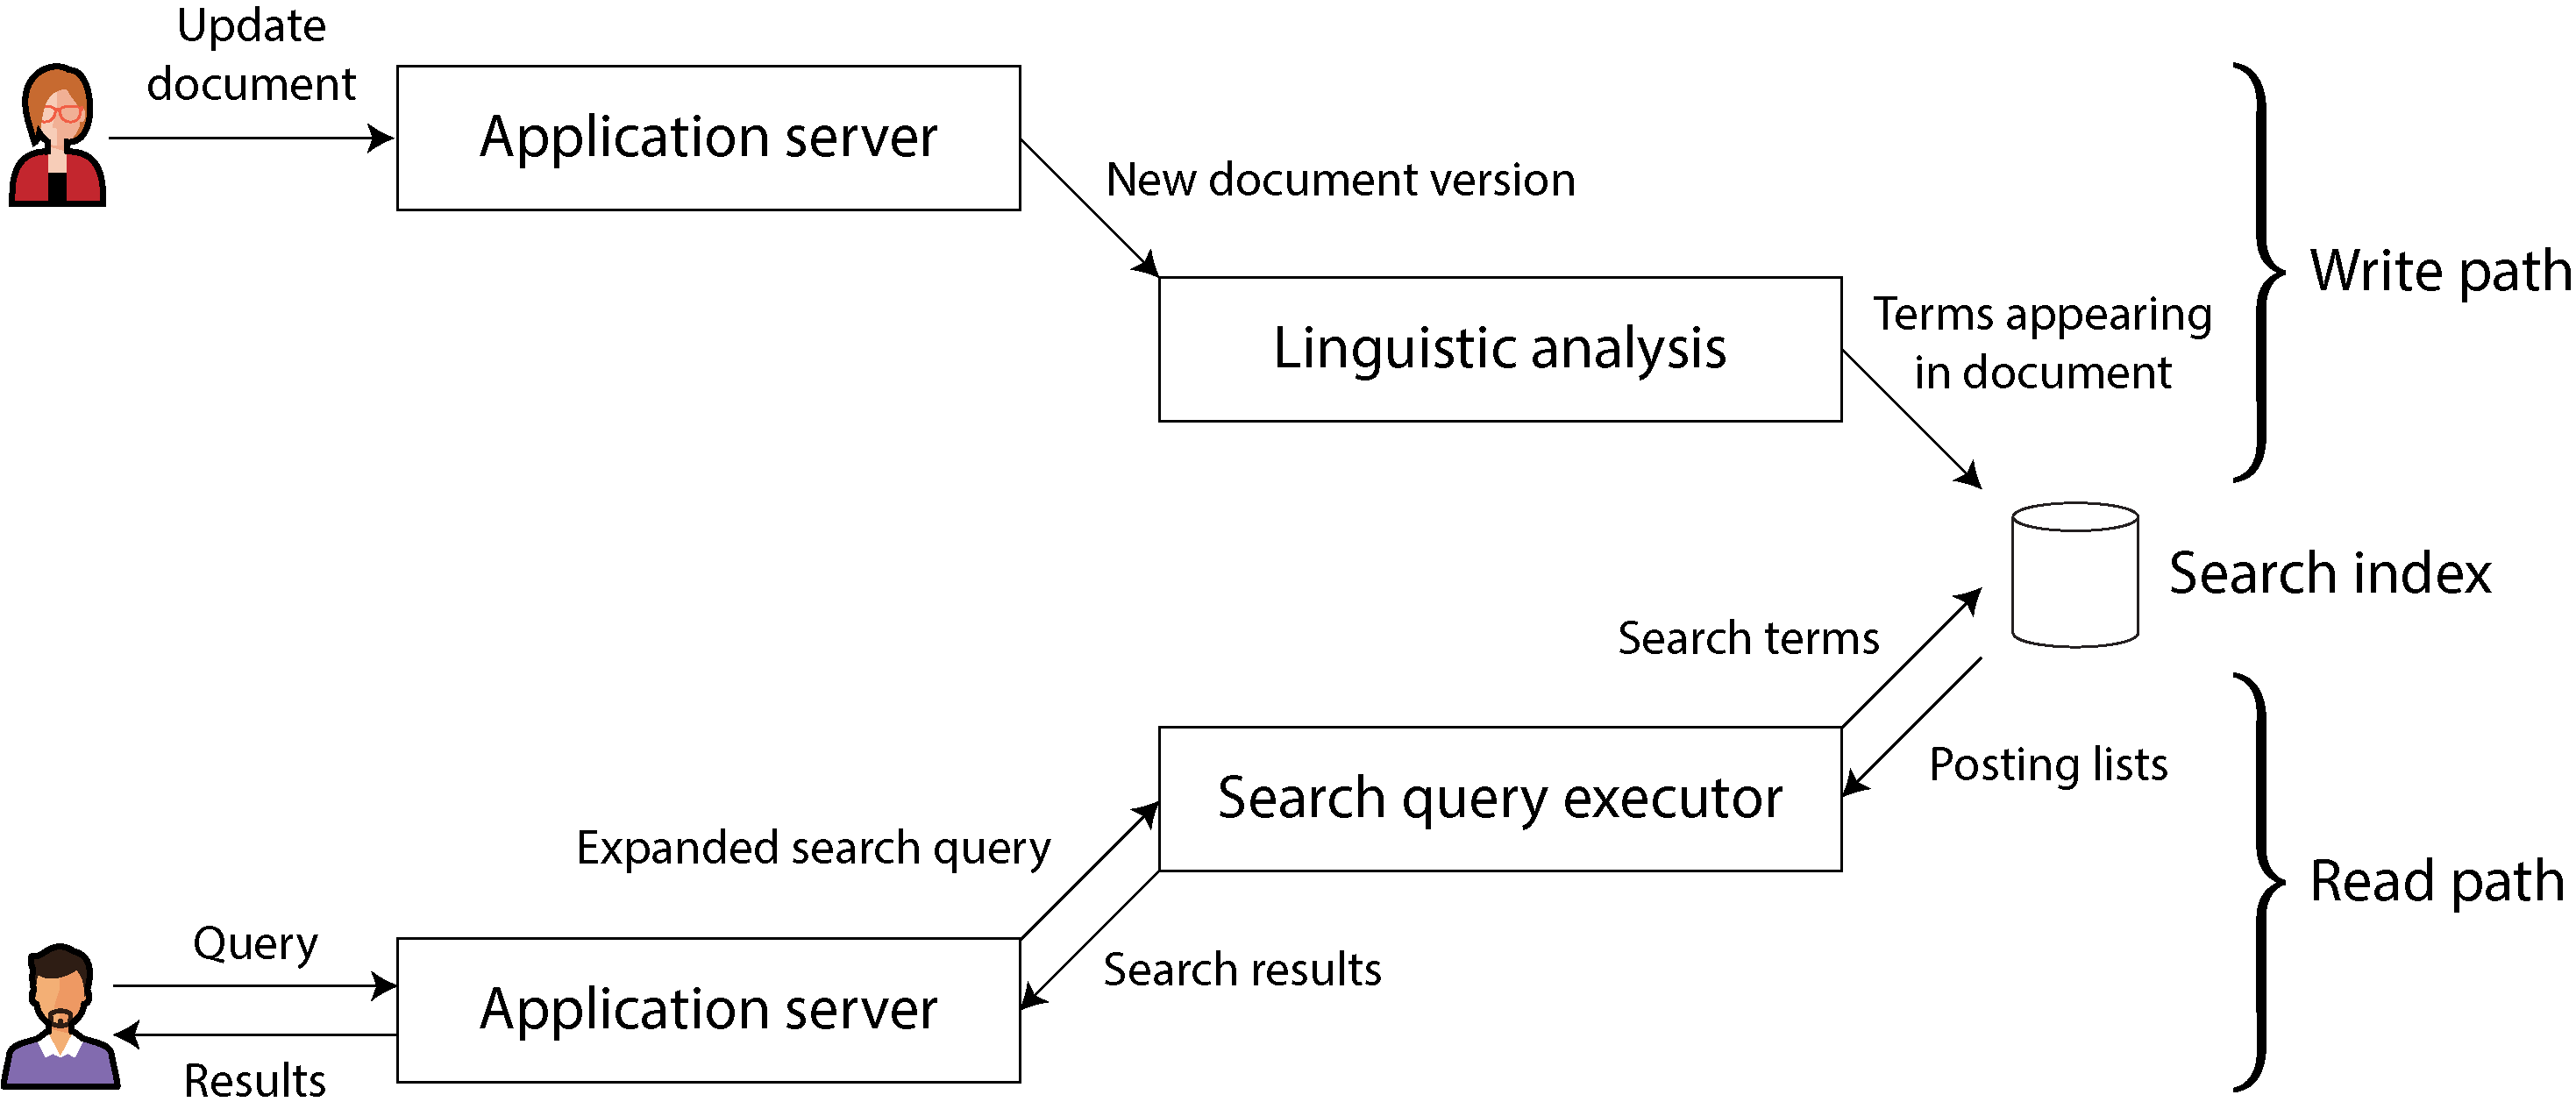

But why do you create the derived dataset in the first place? Most likely because you want to query it again at a later time. This is the read path: when serving a user request, you read from the derived dataset, perhaps perform more processing on the results, and construct the response to the user.

## Aiming for Correctness

Often, simple solutions appear to work correctly when concurrency is low and there are no faults, but turn out to have many subtle bugs in more demanding circumstances.

If your application can tolerate occasionally corrupting or losing data in unpredictable ways, life is a lot simpler, and you might be able to get away with simply crossing your fingers and hoping for the best. If you need stronger assurances of correctness, serializability and atomic commit are established approaches, but they come at a cost. They typically work in only a single datacenter (ruling out geographically distributed architectures), and they limit the scale and fault-tolerance properties you can achieve.

**Duplicate suppression**

In many databases, a transaction is tied to a client connection (if the client sends several queries, the database knows that they belong to the same transaction because they are sent on the same TCP connection). If the client suffers a network interruption and connection timeout after sending the COMMIT but before hearing back from the database server, it does not know whether the transaction has been committed or aborted.

Example 13-1. A nonidempotent transfer of money from one account to another
```sql
BEGIN TRANSACTION;
UPDATE accounts SET balance = balance + 11.00 WHERE account_id = 1234;
UPDATE accounts SET balance = balance - 11.00 WHERE account_id = 4321;
COMMIT;
```
The client can reconnect to the database and retry the transaction,

The client can reconnect to the database and retry the transaction. Thus, even though code like this is a standard example for transaction atomicity, it is not correct, and real banks do not work like this.

**Uniquely identifying requests**

To make a request idempotent through several hops of network communication, it is not sufficient to rely on a transaction mechanism provided by a database. You need to consider the *end-to-end* flow of the request.

For example, you could generate a unique identifier for each request (such as a UUID) and include it as a hidden form field in the client application, or calculate a hash of all the relevant form fields to derive the request ID [3]. If the web browser submits a POST request twice, the two requests will have the same request ID. You can then pass that request ID all the way through to the database and check that you always execute only one request with a given ID, as shown in Example 13-2.

Example 13-2. Suppressing duplicate requests by using a unique ID
```sql
ALTER TABLE requests ADD UNIQUE (request_id);

BEGIN TRANSACTION;

INSERT INTO requests
  (request_id, from_account, to_account, amount)
  VALUES('0286FDB8-D7E1-423F-B40B-792B3608036C', 4321, 1234, 11.00);

UPDATE accounts SET balance = balance + 11.00 WHERE account_id = 1234;
UPDATE accounts SET balance = balance - 11.00 WHERE account_id = 4321;

COMMIT;
```
This code relies on a uniqueness constraint on the `request_id` column. If a transaction attempts to insert an ID that already exists, the `INSERT` fails and the transaction is aborted, preventing it from taking effect twice. Relational databases can generally maintain a uniqueness constraint correctly, even at weak isolation levels (whereas an application-level check-then-insert may fail under nonserializable isolation, as discussed in “Write Skew and Phantoms”).

Besides suppressing duplicate requests, the requests table in Example 13-2 acts as a kind of event log, which can be useful for event sourcing or CDC. The updates to the account balances don’t have to happen in the same transaction as the insertion of the event, since they are redundant and could be derived from the request event in a downstream consumer—as long as the event is processed exactly once, which can again be enforced using the request ID.

Solving the problem requires an end-to-end solution: a transaction identifier that is passed all the way from the end-user client to the database.

### Enforcing Constraints

**Uniqueness constraints require consensus**

In Chapter 10 we saw that in a distributed setting, enforcing a uniqueness constraint requires consensus. If several concurrent requests have the same value, the system somehow needs to decide which one of the conflicting operations is accepted and reject the others as violations of the constraint.

The most common way of achieving this consensus is to make a single node the leader and put it in charge of making all the decisions. That works fine as long as you don’t mind funneling all requests through a single node (even if the client is on the other side of the world), and as long as that node doesn’t fail. Consensus algorithms like Raft tackle the problem of safely electing a new leader if the current leader has failed (or is believed to have failed because of a network problem) and preventing split brain.


> Uniqueness checking can be scaled out by sharding based on the value that needs to be unique. For example, if you need to ensure uniqueness by request ID, as in Example 13-2, you can ensure that all requests with the same request ID are routed to the same shard. If you need usernames to be unique, you can shard by hash of username.

However, asynchronous multi-leader replication is ruled out, because different leaders could concurrently accept conflicting writes, and thus the values are no longer unique. If you want to be able to immediately reject any writes that would violate the constraint, synchronous coordination is unavoidable [45].

*What happens if a node containing a shard crashes?*

1. Immediate impact

Any requests that should be routed to that shard can’t be processed (or time out).
You can’t reliably check or enforce uniqueness for those values (e.g., usernames or request IDs mapped to that shard).

If the system blindly accepts writes elsewhere, you risk duplicate entries.

2. What well-designed systems do

To avoid breaking uniqueness guarantees, distributed systems usually rely on replication:

Replication (primary + replicas):

Each shard is copied to other nodes. If the primary node crashes, a replica can take over.

Leader election:

A new node is promoted to handle that shard (common in systems using consensus algorithms like Raft).
Routing updates:

The system updates its routing layer so requests for that shard go to the new leader.

3. During failover

There may be a short window where:

Requests fail or are retried

The system may reject writes to avoid inconsistency (this is safer than allowing duplicates)

Bottom line:

If a shard node crashes, the system must fail over to a replica or temporarily stop handling requests for that shard. Without replication and coordination, your uniqueness guarantees break—which is exactly why production systems always **combine sharding with replication and failover mechanisms.**

### Multishard request processing

You’ve just run into one of the hardest problems in distributed systems: **a single logical operation that spans multiple shards**. There isn’t a “free” solution—you have to pick a pattern based on what you care about most (consistency, latency, simplicity).

Let’s walk through the **real-world approaches**.

---

**First: why this is hard**

A transfer A → B requires:

* Deduct from A (shard 1)
* Add to B (shard 2)
* Record idempotency (maybe shard 3)

There’s **no single database transaction** across shards (unless you use expensive distributed transactions).

So the core problem is:

> How do we avoid ending up with “money deducted but not credited”?

---

**Option 1: Distributed transactions (2PC)**

Classic approach: **Two-Phase Commit (2PC)**

* Coordinate both shards in a single transaction
* Either both commit or both abort

Supported (with caveats) in systems like PostgreSQL.

**Reality check:**

* Slow
* Fragile under failures
* Can lock resources
* Rarely used at large scale

👉 Most modern systems avoid this.

---

**Option 2: Saga pattern (most common)**

Break the operation into **steps with compensation**:

It’s called a “saga” because the process unfolds like a story made up of multiple chapters—each step moves the story forward, and if something goes wrong, there are “plot twists” (compensating actions) that undo or adjust what happened earlier.

1. Deduct from A
2. Credit B
3. Mark request complete

If something fails:

* You run **compensating actions** (e.g., refund A)

This is often implemented with messaging systems like Apache Kafka.

**Example flow**

* Step 1: debit A (shard 1) → emit event
* Step 2: credit B (shard 2) → emit event
* Step 3: mark success

If Step 2 fails:

* Emit “undo debit” → refund A

---

**Trade-offs**

**Pros**

* Scales well
* No global locks
* Industry standard

**Cons**

* Temporary inconsistency possible
* More complex logic
* You must design compensations carefully

---

**Option 3: Idempotent, event-driven transfer (very common hybrid)**

Combine:

* **Idempotency key (request ID)**
* **Per-shard local transactions**
* **Event log**

Flow:

1. Route request ID → shard X (idempotency record)
2. Write “transfer started” (idempotent)
3. Emit event: “debit A”
4. Shard 1:

   * Deduct A (idempotent)
   * Emit “debited”
5. Shard 2:

   * Credit B (idempotent)
   * Emit “credited”
6. Mark request complete

Each step:

* Is **idempotent**
* Can be retried safely

---

**Option 4: Change the data model (often the smartest move)**

Instead of fighting distributed transactions, restructure:

a) Co-locate related data

* Put A and B on the **same shard** (e.g., shard by account ID range or user)

👉 Then it becomes a simple local transaction.

---

b) Use a ledger model

Instead of updating balances directly:

* Append:

  * “-100 from A”
  * “+100 to B”

Balance = sum of entries

This is how many financial systems work.

---

What real systems usually do

In practice:

* ❌ Rarely: full distributed transactions (2PC)
* ✅ Very common: **Saga + idempotency + events**
* ✅ Even better: **design to avoid cross-shard ops**

---

Key insight

You don’t really “solve” cross-shard transactions—you **choose where to handle the complexity**:

* Database → 2PC (simple concept, complex runtime)
* Application → Sagas (complex logic, scalable runtime)
* Data model → co-location (simplest if possible)

---

If you had to pick

For most scalable systems:

> Use **idempotent operations + saga pattern**, and try hard to **minimize cross-shard operations** in your data model.


### Timeliness and Integrity

Timeliness

Timeliness means ensuring that users observe the system in an up-to-date state. We saw previously that if a user reads from a stale copy of the data, they may observe it in an inconsistent state.

Integrity

Integrity means absence of corruption—no data loss, and no contradictory or false data.

In slogan form: violations of timeliness are allowed under eventual consistency, whereas violations of integrity result in perpetual inconsistency.

For example, on your credit card statement, it is not surprising if a transaction that you made within the last 24 hours does not yet appear. It is normal that these systems have a certain lag. We know that banks reconcile and settle transactions asynchronously, and timeliness is not very important here [3]. However, it would be very bad if the statement balance was not equal to the sum of the transactions plus the previous statement balance (an error in the sums), or if a transaction was charged to you but not paid to the merchant (disappearing money). Such problems would be violations of the integrity of the system.

**Correctness of dataflow systems**

ACID transactions usually provide both timeliness (e.g., linearizability) and integrity (e.g., atomic commit) guarantees. Thus, if you approach application correctness from the point of view of ACID transactions, the distinction between timeliness and integrity is fairly inconsequential.

On the other hand, an interesting property of the event-based dataflow systems that we have discussed in this chapter is that they decouple timeliness and integrity. When processing event streams asynchronously, there is no guarantee of timeliness,

**Coordination-avoiding data systems**

We have now made two interesting observations:

- Dataflow systems can maintain integrity guarantees on derived data without atomic commit, linearizability, or synchronous cross-shard coordination.

- Although strict uniqueness constraints require timeliness and coordination, many applications are fine with loose constraints that may be temporarily violated and fixed up later, as long as integrity is preserved throughout (e.g. let customers buy a bit more than available stock and refund later)

Taken together, these observations mean that dataflow systems can provide data management services for many applications without requiring coordination, while still giving strong integrity guarantees. Such *coordination-avoiding* data systems have a lot of appeal; they can achieve better performance and fault tolerance than systems that need to perform synchronous coordination.

For example, such a system could operate distributed across multiple datacenters in a multi-leader configuration, asynchronously replicating between regions. Any one datacenter can continue operating independently from the others, because no synchronous cross-region coordination is required. Such a system would have weak timeliness guarantees—it could not be linearizable without introducing coordination—but it can still have strong integrity guarantees.